# Validate gene signature in external study

In [1]:
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}
quiet_library('Seurat')
quiet_library('tidyverse')
quiet_library('data.table')
quiet_library('ggplot2')
quiet_library('Matrix')
quiet_library('dplyr')
quiet_library('viridis')
quiet_library('scater')
quiet_library('future.apply')
quiet_library('PALMO')
quiet_library('scran')
quiet_library('SingleCellExperiment')
quiet_library('DESeq2')
quiet_library('scater')
quiet_library('ggpubr')
quiet_library('hypeR')

Warning message:
“package ‘dplyr’ was built under R version 4.3.3”
Warning message:
“package ‘scran’ was built under R version 4.3.3”
Warning message:
“package ‘DESeq2’ was built under R version 4.3.3”


In [2]:
# define the color palette to be used
npg_color <- c("#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF", 
               "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF")
npg_color_ext <- colorRampPalette(npg_color)(15)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c("#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A", 
    "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999", 
    "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00")
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 20, repr.plot.height = 15)

In [3]:
# define working path
data_path = '/home/jupyter/data/ra_longitudinal/output_results/pseudobulk/deepclean/counts/combined'
pseudobulk_path = '/home/jupyter/data/ra_longitudinal/output_results/pseudobulk/deepclean'
meta_path = '/home/jupyter/github/ra-longitudinal/metadata'
fig_path = '/home/jupyter/data/ra_longitudinal/figures/validation'
output_path = '/home/jupyter/data/ra_longitudinal/output_results/validation'
if(!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if(!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))
proj_name = 'ALTRA_AIM3_scRNA_validation_'

In [4]:
run_mcnemar_test = function(x){
    cont_counts = x %>%
            pivot_wider(id_cols = aim3_direction, 
                        names_from = abt_direction , values_from = n)
    # print(cont_counts)
    test_res = rstatix::mcnemar_test(cont_counts%>%select(-aim3_direction))%>% as_tibble()
    return(test_res)
}

# load data from Iwasaki et al
paper https://arthritis-research.biomedcentral.com/articles/10.1186/s13075-023-03236-y

In [5]:
# gene epxrs 
abt_data = read_tsv('/home/jupyter/data/ra_longitudinal/reference_data/Iwasaki_et_al.tsv')

Rows: 51306 Columns: 46
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): ext_gene, gene_id
dbl (44): NR01_0M, NR01_3M, NR02_0M, NR02_3M, NR03_0M, NR03_3M, NR04_0M, NR0...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [6]:
abt_data%>%head()

ext_gene,gene_id,NR01_0M,NR01_3M,NR02_0M,NR02_3M,NR03_0M,NR03_3M,NR04_0M,NR04_3M,⋯,R03_0M,R03_3M,R04_0M,R04_3M,R05_0M,R05_3M,R06_0M,R06_3M,R07_0M,R07_3M
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TSPAN6,ENSG00000000003,15.00,13.00,8.00,7.00,4.00,20.00,5.00,12.00,⋯,9.00,25.00,9.00,8.00,18.00,18.00,1.00,2.00,17.00,12.00
TNMD,ENSG00000000005,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,⋯,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
DPM1,ENSG00000000419,826.00,330.00,683.00,884.00,345.00,308.00,262.00,243.00,⋯,582.00,712.00,491.00,485.00,439.00,509.00,711.00,799.00,498.00,278.00
SCYL3,ENSG00000000457,515.28,265.21,252.79,386.71,377.71,233.98,471.72,439.79,⋯,603.39,638.37,397.24,450.96,469.94,474.58,457.46,391.17,452.91,498.35
C1orf112,ENSG00000000460,164.72,68.79,111.21,149.29,77.29,56.02,131.28,61.21,⋯,130.61,96.64,122.76,120.04,90.08,89.43,124.54,78.83,104.17,82.65
FGR,ENSG00000000938,6132.00,5090.00,7924.00,6050.00,14120.00,5385.00,5243.00,4968.00,⋯,1736.00,3510.00,2953.00,4354.00,3440.00,3575.00,4248.00,6242.00,3758.00,3569.00


In [7]:
# abt_data%>%janitor::get_dupes(ext_gene)

In [8]:
counts = abt_data%>% select(-c(ext_gene, gene_id))%>%as.matrix()
rownames(counts) = abt_data$ext_gene

In [9]:
sampleTable <- data.frame('sample'=colnames(counts), 
                          'patient' = str_split(colnames(counts), '_', simplify = TRUE)[,1],
                         'time' = str_split(colnames(counts), '_', simplify = TRUE)[,2], 
                         'response' = if_else(str_detect(colnames(counts), 'NR'), 'Non_responder', 'responder'))
rownames(sampleTable) <- colnames(counts)

In [10]:
# seperate responder and non-responder and construct the deseq2 object
res_sample = sampleTable%>%filter(response=='responder')
res_count = counts[, colnames(counts)%in%rownames(res_sample)]
# res_sample
dds_resp <- DESeqDataSetFromMatrix(round(res_count), res_sample, ~patient + time)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


In [11]:
dds_resp

class: DESeqDataSet 
dim: 51306 14 
metadata(1): version
assays(1): counts
rownames(51306): TSPAN6 TNMD ... AP000229.1 AC098479.1
rowData names(0):
colnames(14): R01_0M R01_3M ... R07_0M R07_3M
colData names(4): sample patient time response

In [12]:
smallestGroupSize <- 7
keep <- rowSums(counts(dds_resp) >= 10) >= smallestGroupSize
dds_resp <- dds_resp[keep,]
dds_resp

class: DESeqDataSet 
dim: 13608 14 
metadata(1): version
assays(1): counts
rownames(13608): TSPAN6 DPM1 ... AL031666.3 AC012510.1
rowData names(0):
colnames(14): R01_0M R01_3M ... R07_0M R07_3M
colData names(4): sample patient time response

In [13]:
dds_resp$time <- factor(dds_resp$time, levels = c("0M","3M"))

In [14]:
dds_resp$time%>%unique()

[1] 0M 3M
Levels: 0M 3M

In [15]:
dds_resp <- DESeq(dds_resp)
dds_resp_res <- results(dds_resp)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [16]:
# get the results 
dds_resp_res_tb = dds_resp_res%>%as_tibble(rownames = 'gene')
dds_resp_res_tb%>%head()

gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TSPAN6,18.36329,-0.04054009,0.4435564,-0.09139784,0.927176475,NA
DPM1,498.47598,-0.14877090,0.1898690,-0.78354501,0.433307132,0.71569732
SCYL3,454.06455,-0.09370180,0.1282288,-0.73073902,0.464938577,0.73644676
C1orf112,92.40745,-0.57023248,0.1928547,-2.95679833,0.003108514,0.06069719
FGR,3287.94538,0.25089055,0.1750137,1.43354840,0.151701177,0.45390349
CFH,110.78245,-0.23174787,0.2995139,-0.77374660,0.439080655,0.71991601


In [17]:
# # calculate the qvalues
dds_resp_res_tb <- dds_resp_res_tb %>% mutate(q_values = qvalue::qvalue(pvalue)$qvalues)%>%
    select(-padj)
dds_resp_res_tb%>%head()

gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TSPAN6,18.36329,-0.04054009,0.4435564,-0.09139784,0.927176475,0.68943600
DPM1,498.47598,-0.14877090,0.1898690,-0.78354501,0.433307132,0.52312152
SCYL3,454.06455,-0.09370180,0.1282288,-0.73073902,0.464938577,0.53689940
C1orf112,92.40745,-0.57023248,0.1928547,-2.95679833,0.003108514,0.05193526
FGR,3287.94538,0.25089055,0.1750137,1.43354840,0.151701177,0.34684225
CFH,110.78245,-0.23174787,0.2995139,-0.77374660,0.439080655,0.52571484


In [18]:
# save the deg table
dds_resp_res_tb%>% write_csv(file.path(output_path, paste0(proj_name, 'responder_pre_post_degs.csv')))

In [19]:
dds_resp_res_tb%>%filter(gene=='IL17RA')

gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
IL17RA,1170.854,0.02554268,0.1260401,0.2026551,0.8394046,0.6675754


Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


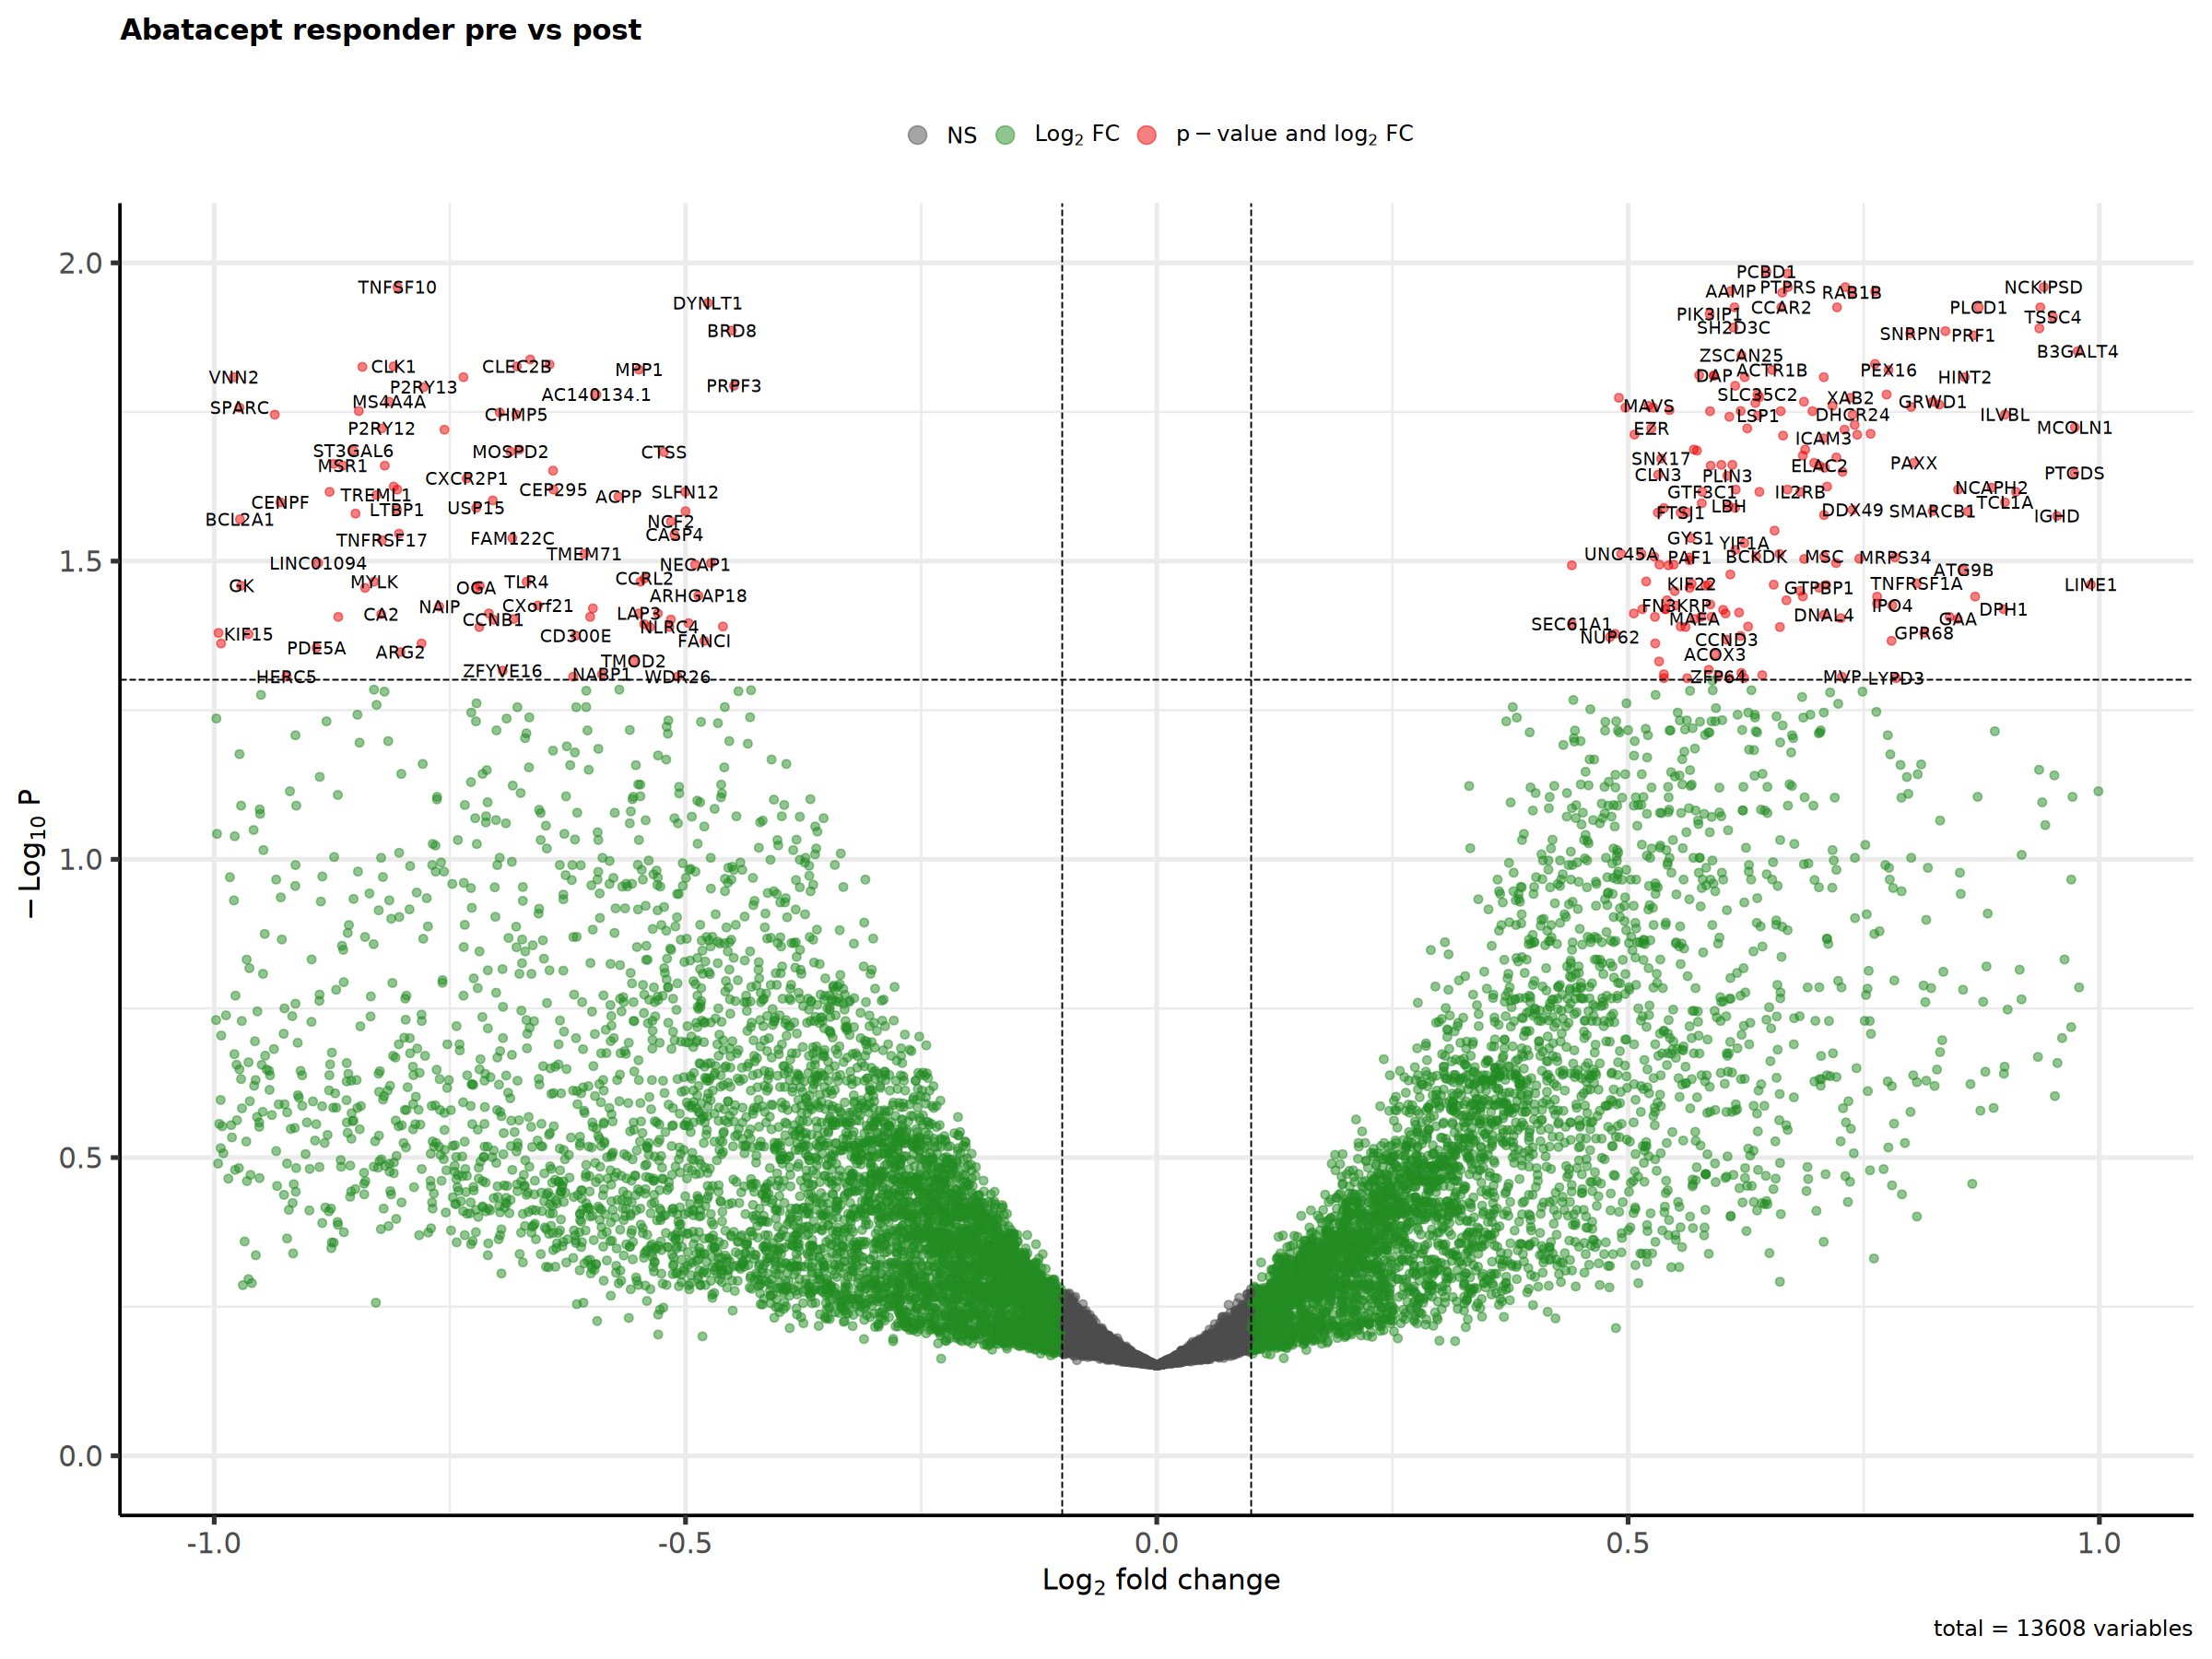

In [20]:
# Plot the DA results for aim1
p1 <- EnhancedVolcano::EnhancedVolcano(dds_resp_res_tb,title = 'Abatacept responder pre vs post',
    subtitle = '',                                    
    lab = dds_resp_res_tb$gene,
    x = 'log2FoldChange',
    y = 'q_values',
    pCutoff = 0.05,
    FCcutoff = 0.1,
    pointSize = 2.0, #drawConnectors = TRUE,
    widthConnectors = 1.0,
    colConnectors = 'black',
    arrowheads = FALSE,
    labSize = 4.0) + 
    xlim(c(-1, 1)) + ylim(0, 2)
p1
ggsave(file.path(fig_path, paste0(proj_name, 'Abatacept_responders_prevspost_valcano_plot.png')),
       width=8, height=6)

### load aim3 degs results and compared with the responder

In [21]:
data_path = '/home/jupyter/data/ra_longitudinal/output_results/certPro'
# load aim3 deg
aim3_degs <- read_csv(file.path(file.path(data_path, 
                                          'ALTRA_AIM3_certpro_scRNA_Pseudobulk_AIFI_l3_mixed_models_time_result_750days.csv')), 
                      show_col_types = FALSE)%>%
    dplyr::rename('cell_type'='celltype')

In [22]:
# combine the deg results
abt_aim3_degs_comparison <- dds_resp_res_tb %>% full_join(aim3_degs, by=c('gene'),
                                          suffix = c('_abt', '_aim3'))%>%
    dplyr::rename('pvalue_aim3'='p.value')%>%
   filter(q_values_aim3<0.1 & #padj<0.1&
          !is.na(log2FoldChange))%>% 
    mutate(sig = case_when(q_values_abt<=0.1&q_values_aim3<=0.1 ~ 'AbtSig&Aim3Sig', 
                    q_values_abt>0.1&q_values_aim3<=0.1 ~ 'Aim3Sig', 
                    q_values_abt<=0.1&q_values_aim3>0.1 ~ 'AbtSig', 
                    q_values_abt>0.1&q_values_aim3>0.1~ 'No sig'))%>% 
    mutate(aim3_direction = if_else(estimate>0, 'aim3_up', 'aim3_down'),
          abt_direction = if_else(log2FoldChange>0, 'abt_up', 'abt_down'))
abt_aim3_degs_comparison%>%colnames()

[1] "gene"           "baseMean"       "log2FoldChange" "lfcSE"         
 [5] "stat"           "pvalue"         "q_values_abt"   "cell_type"     
 [9] "effect"         "group"          "term"           "estimate"      
[13] "std.error"      "statistic"      "df"             "pvalue_aim3"   
[17] "q_values_aim3"  "sig"            "aim3_direction" "abt_direction"

### run a HyperGeometric Enrichment test

In [23]:
# check the deg counts
aim3_degs_counts = aim3_degs %>% mutate(sig_0_1=if_else(q_values<0.1, 'sig', 'ns'))%>%
    group_by(cell_type)%>%mutate(total_genes = n())%>%
    group_by(cell_type, sig_0_1)%>%summarise(counts =n(), total_genes=unique(total_genes))
aim3_degs_counts%>%filter(cell_type%in%c('Core naive CD4 T cell', 'CM CD4 T cell'))

`summarise()` has grouped output by 'cell_type'. You can override using the
`.groups` argument.


cell_type,sig_0_1,counts,total_genes
<chr>,<chr>,<int>,<int>
CM CD4 T cell,ns,2785,5497
CM CD4 T cell,sig,2712,5497
Core naive CD4 T cell,ns,2299,4950
Core naive CD4 T cell,sig,2651,4950


In [24]:
# abt_sig_genes <- dds_resp_res_tb%>%filter(q_values<0.1)%>%pull(gene)
# abt_resp_table = data.frame('gene'=abt_sig_genes, 'group'='Abt_responder_genes')

# custom.set <- abt_resp_table
# custom.set%>%head()

In [25]:
# library("EnrichIntersect")
# data(cancers_drug_groups, package = "EnrichIntersect")
# aim3_genes = aim3_degs%>%
#     filter(cell_type=='Core_naive_CD4_T_cell')%>%arrange(desc(p.value))
# aim3_genes_list = aim3_genes$p.value
# names(aim3_genes_list) = aim3_genes$gene
# custom.set <- abt_resp_table#%>%filter(gene%in%aim3_genes$gene)
# # aim3_genes_list
# enrich <- enrichment(aim3_genes_list, custom.set, permute.n = 100)

In [26]:
# ## let us apply the function to our data (see figure)
# aim3_sig_genes <- aim3_degs %>%
#     filter(cell_type=='Core_naive_CD4_T_cell'&q_values<0.1)%>%pull(gene)
# abt_sig_genes <- dds_resp_res_tb%>%filter(q_values<0.1)%>%pull(gene)
# pw_length = length(abt_sig_genes)
# overlap_genes = intersect(abt_sig_genes, aim3_sig_genes)
# background_length = aim3_degs%>% filter(cell_type=='Core_naive_CD4_T_cell')%>%nrow()

# result = phyper(q=length(overlap_genes)-1,               # number of red marbles in the draw - 1 (see below)
#         m=pw_length,         # number of red marbles in urn
#         n=background_length-pw_length, # number of green marbles in urn 
#         k=length(aim3_sig_genes),       # Number of drawn marbles
#         lower.tail=FALSE)  

In [27]:
# use abt response genes as the reference
# check if the aim3 degs are significant enriched.
celltype_test = 'Core naive CD4 T cell'
aim3_sig_genes <- aim3_degs %>%
    filter(cell_type==celltype_test&q_values<0.1)%>%pull(gene)
aim3_bg_genes <- aim3_degs %>%
    filter(cell_type==celltype_test)%>%pull(gene)

abt_sig_genes <- dds_resp_res_tb%>%filter(q_values<0.1)%>%pull(gene)
abt_genes_list = list('Abt_responder_genes' = abt_sig_genes)

hyp_obj <- hypeR(aim3_sig_genes, abt_genes_list, 
                 test="hypergeometric", background=length(aim3_bg_genes), plotting=TRUE)
hyp_obj

(hyp) 

  data: 
               label pval fdr signature geneset overlap background
 Abt_responder_genes    1   1      2651     965     237       4950
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [28]:
# make a degs list per cell type
celltypes_test = aim3_degs %>%
    filter(q_values<0.1)%>%group_by(cell_type) %>%
    tally()%>%filter(n>10)%>%pull(cell_type)%>%
    unique()
aim3_genes_list = lapply(celltypes_test, function(x){
    sig_genes <- aim3_degs %>%
        filter(cell_type==x&q_values<0.1)%>%pull(gene)
    return(sig_genes)
})

names(aim3_genes_list) = celltypes_test
# aim3_genes_list
abt_sig_genes <- dds_resp_res_tb%>%filter(q_values<0.1)%>%pull(gene)
abt_bg_genes <- dds_resp_res_tb %>%pull(gene)

hyp_obj <- hypeR(abt_sig_genes, aim3_genes_list, 
                 test="hypergeometric", background=length(abt_bg_genes), plotting=TRUE)


In [29]:
hyp_to_excel(hyp_obj, file_path=file.path(output_path,"pathways.xlsx"))

In [30]:
## plot fig6E
hyp_obj$data

,label,pval,fdr,signature,geneset,overlap,background,hits
,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<chr>
Core naive CD4 T cell,Core naive CD4 T cell,3.3e-05,0.0003,965,2651,237,13608,"AAMP , ABHD14A , ABHD14B , ACTG1 , ADD1 , ADGRE5 , ADRM1 , AIF1 , ALKBH7 , AP1M1 , APBB1 , APH1A , APRT , AQP3 , ARL2 , ARL6IP4 , ASAH1 , ATE1 , ATP2A3 , ATP6V0E2 , BACH1 , BLCAP , BRD8 , BRMS1 , BSG , C20orf27 , C7orf50 , C9orf16 , C9orf72 , CARD16 , CASP1 , CASP4 , CASP8 , CBWD5 , CCDC107 , CCDC12 , CD27 , CD320 , CD7 , CD81 , CD99 , CDK4 , CEP295 , CEP68 , CHMP5 , CIRBP , CLK1 , CLPP , COPE , COQ8A , CORO1A , COX5A , CRIP2 , CTSD , CUX1 , CXXC1 , CYBA , CYTH2 , DAP , DCTN1 , DDA1 , DENND1C , DGCR6L , DMTF1 , DPYD , DYNLT1 , E2F4 , EEF1D , EEFSEC , EIF3F , EIF3G , EIF4G1 , EIF5A , EMD , EZR , FAM111A , FAU , FKBP2 , FLT3LG , FTH1 , GADD45GIP1 , GBP1 , GBP2 , GON4L , GPAA1 , GPR108 , GUK1 , GYPC , GZMM , HDAC3 , HINT2 , HK1 , HLA-E , HMGA1 , HPS1 , HSPB1 , ICAM3 , IL27RA , IL4R , ISCU , ITGB2 , ITGB7 , ITM2C , JTB , KIF22 , KLHDC3 , LAGE3 , LAT , LCK , LGALS8 , LIMD2 , LMAN2 , LRPAP1 , LSP1 , LTB , LUC7L3 , LYPLA2 , LYST , MAD1L1 , MAL , MCRIP1 , METTL26 , MFSD8 , MITD1 , MPG , MRPL12 , MRPL28 , MRPL41 , MRPL54 , MRPS12 , MRPS2 , MRPS26 , MYDGF , MYH9 , MZT2B , N4BP2L2 , NABP1 , NAIP , NAXE , NDUFB11 , NDUFV1 , NECAP1 , NHP2 , NKTR , NME3 , NOSIP , NUDT16L1 , OGA , PAXBP1 , PAXX , PCIF1 , PEX16 , PFN1 , PGLS , PICALM , PLEKHB1 , POLD2 , POLR2E , POMP , PPIL2 , PPP4C , PRPF3 , PRPF39 , PSMA4 , PSMF1 , PTPMT1 , PUF60 , R3HCC1 , RAB1B , RAB5C , RAD23A , RALY , RBM25 , RBM39 , RBM6 , RFTN1 , RNH1 , RPL13 , RPL18 , RPL18A , RPLP2 , RPS2 , SAMD9 , SAMD9L , SART3 , SCAMP2 , SCAND1 , SDF2L1 , SF3B1 , SF3B4 , SGF29 , SIGIRR , SIVA1 , SLC25A39 , SLC3A2 , SMDT1 , SNF8 , SNRPB , SNRPN , SNX17 , SPTBN1 , SQSTM1 , SRP68 , SRSF7 , SSNA1 , SUMO3 , SURF4 , SUSD3 , SYNGR2 , SZRD1 , TBC1D10A , TECR , TIMM13 , TMED3 , TMED9 , TMEM134 , TMEM167A , TNFRSF14 , TRAPPC6A , TRIM22 , TSPO , TSSC4 , TUFM , TWF2 , UBE4A , UBXN1 , UNC119 , USP15 , VPS51 , WDR26 , WDR46 , ZAP70 , ZDHHC12 , ZDHHC6 , ZNF511 , ZNF581 , ZNF83"
CM CD4 T cell,CM CD4 T cell,5.0e-04,0.0022,965,2712,233,13608,"ABHD14A , ACO2 , ACTG1 , ADD1 , ADGRE5 , ADRM1 , AIF1 , ALKBH7 , ANXA6 , APH1A , APRT , AQP3 , ARL6IP4 , ATP6AP1 , ATP6V0E2 , BACH1 , BAZ2B , BRD8 , BRMS1 , BSG , C20orf27 , C6orf47 , C7orf50 , C9orf16 , CALCOCO2 , CARD16 , CASP1 , CASP4 , CASP8 , CBR3 , CCDC107 , CCDC12 , CD27 , CD320 , CD81 , CD99 , CEP68 , CHID1 , CHMP1A , CHMP5 , CHMP6 , CHTF8 , CLEC2B , CLK1 , CLPP , COPE , COQ8A , CORO1A , COX5A , CRIP2 , CUX1 , CXCR3 , CXXC1 , CYBA , DAP , DCTN1 , DGCR6L , DMTF1 , DYNLT1 , E2F4 , EEF1D , EEFSEC , EIF3F , EIF3G , EIF4G1 , EIF5A , EMD , EZR , FAM111A , FAU , FKBP2 , FLT3LG , FN3KRP , FTH1 , FXN , GADD45GIP1 , GNPTG , GON4L , GPR108 , GUK1 , GYPC , GZMM , HINT2 , HIRIP3 , HLA-E , HPS1 , HSPB1 , ICAM3 , IL27RA , ISCU , ITGB2 , ITGB7 , ITM2C , JTB , KIAA1109 , KLF2 , LAGE3 , LBH , LCK , LGALS3BP , LIMD2 , LMAN2 , LRPAP1 , LSP1 , LTB , LUC7L3 , LYST , MAD1L1 , MAL , MAP1LC3B , MAVS , MCRIP1 , METTL26 , MFSD8 , MPG , MRPL12 , MRPL28 , MRPL41 , MRPL54 , MRPS12 , MRPS2 , MRPS26 , MSL1 , MYDGF , MYH9 , MZT2B , N4BP2L2 , NABP1 , NAIP , NAXE , NDUFB11 , NDUFV1 , NHP2 , NKTR , NME3 , NOC2L , NOSIP , NSUN2 , NUDT16L1 , NUP210 , NXT1 , OGA , P4HB , PAXBP1 , PAXX , PCBD1 , PCIF1 , PEPD , PEX16 , PFKL , PFN1 , PGLS , PI16 , PICALM , PLIN3 , PNISR , POLR2E , POMP , PPIL2 , PPP4C , PRPF3 , PRPF31 , PRPF39 , PSMF1 , PTPMT1 , PTPN7 , PUF60 , RAB5C , RAD23A , RASA3 , RBM25 , RBM39 , RBM6 , RHBDD2 , RPL13 , RPL18 , RPL18A , RPLP2 , RPS2 , S1PR4 , SAMD9 , SCAND1 , SDF2L1 , SF3B1 , SF3B4 , SGF29 , SIGIRR , SIVA1 , SLC25A39 , SLC39A3 , SLC3A2 , SMDT1 , SNAP47 , SNF8 , SNRPB , SNRPN , SNX17 , SPTBN1 , SQSTM1 , SRRT , SRSF7 , SSNA1 , SURF4 , SYNGR2 , TANK , TIMM13 , TMED3 , TMED9 , TMEM134 , TNFRSF14 , TRAPPC6A , TRIM22 , TRIM28 , TRPC4AP , TSPO , TSSC4 , TUFM , TUT7 , TWF2 , UBXN1 , UCKL1 , UNC119 , USP15 , VPS51

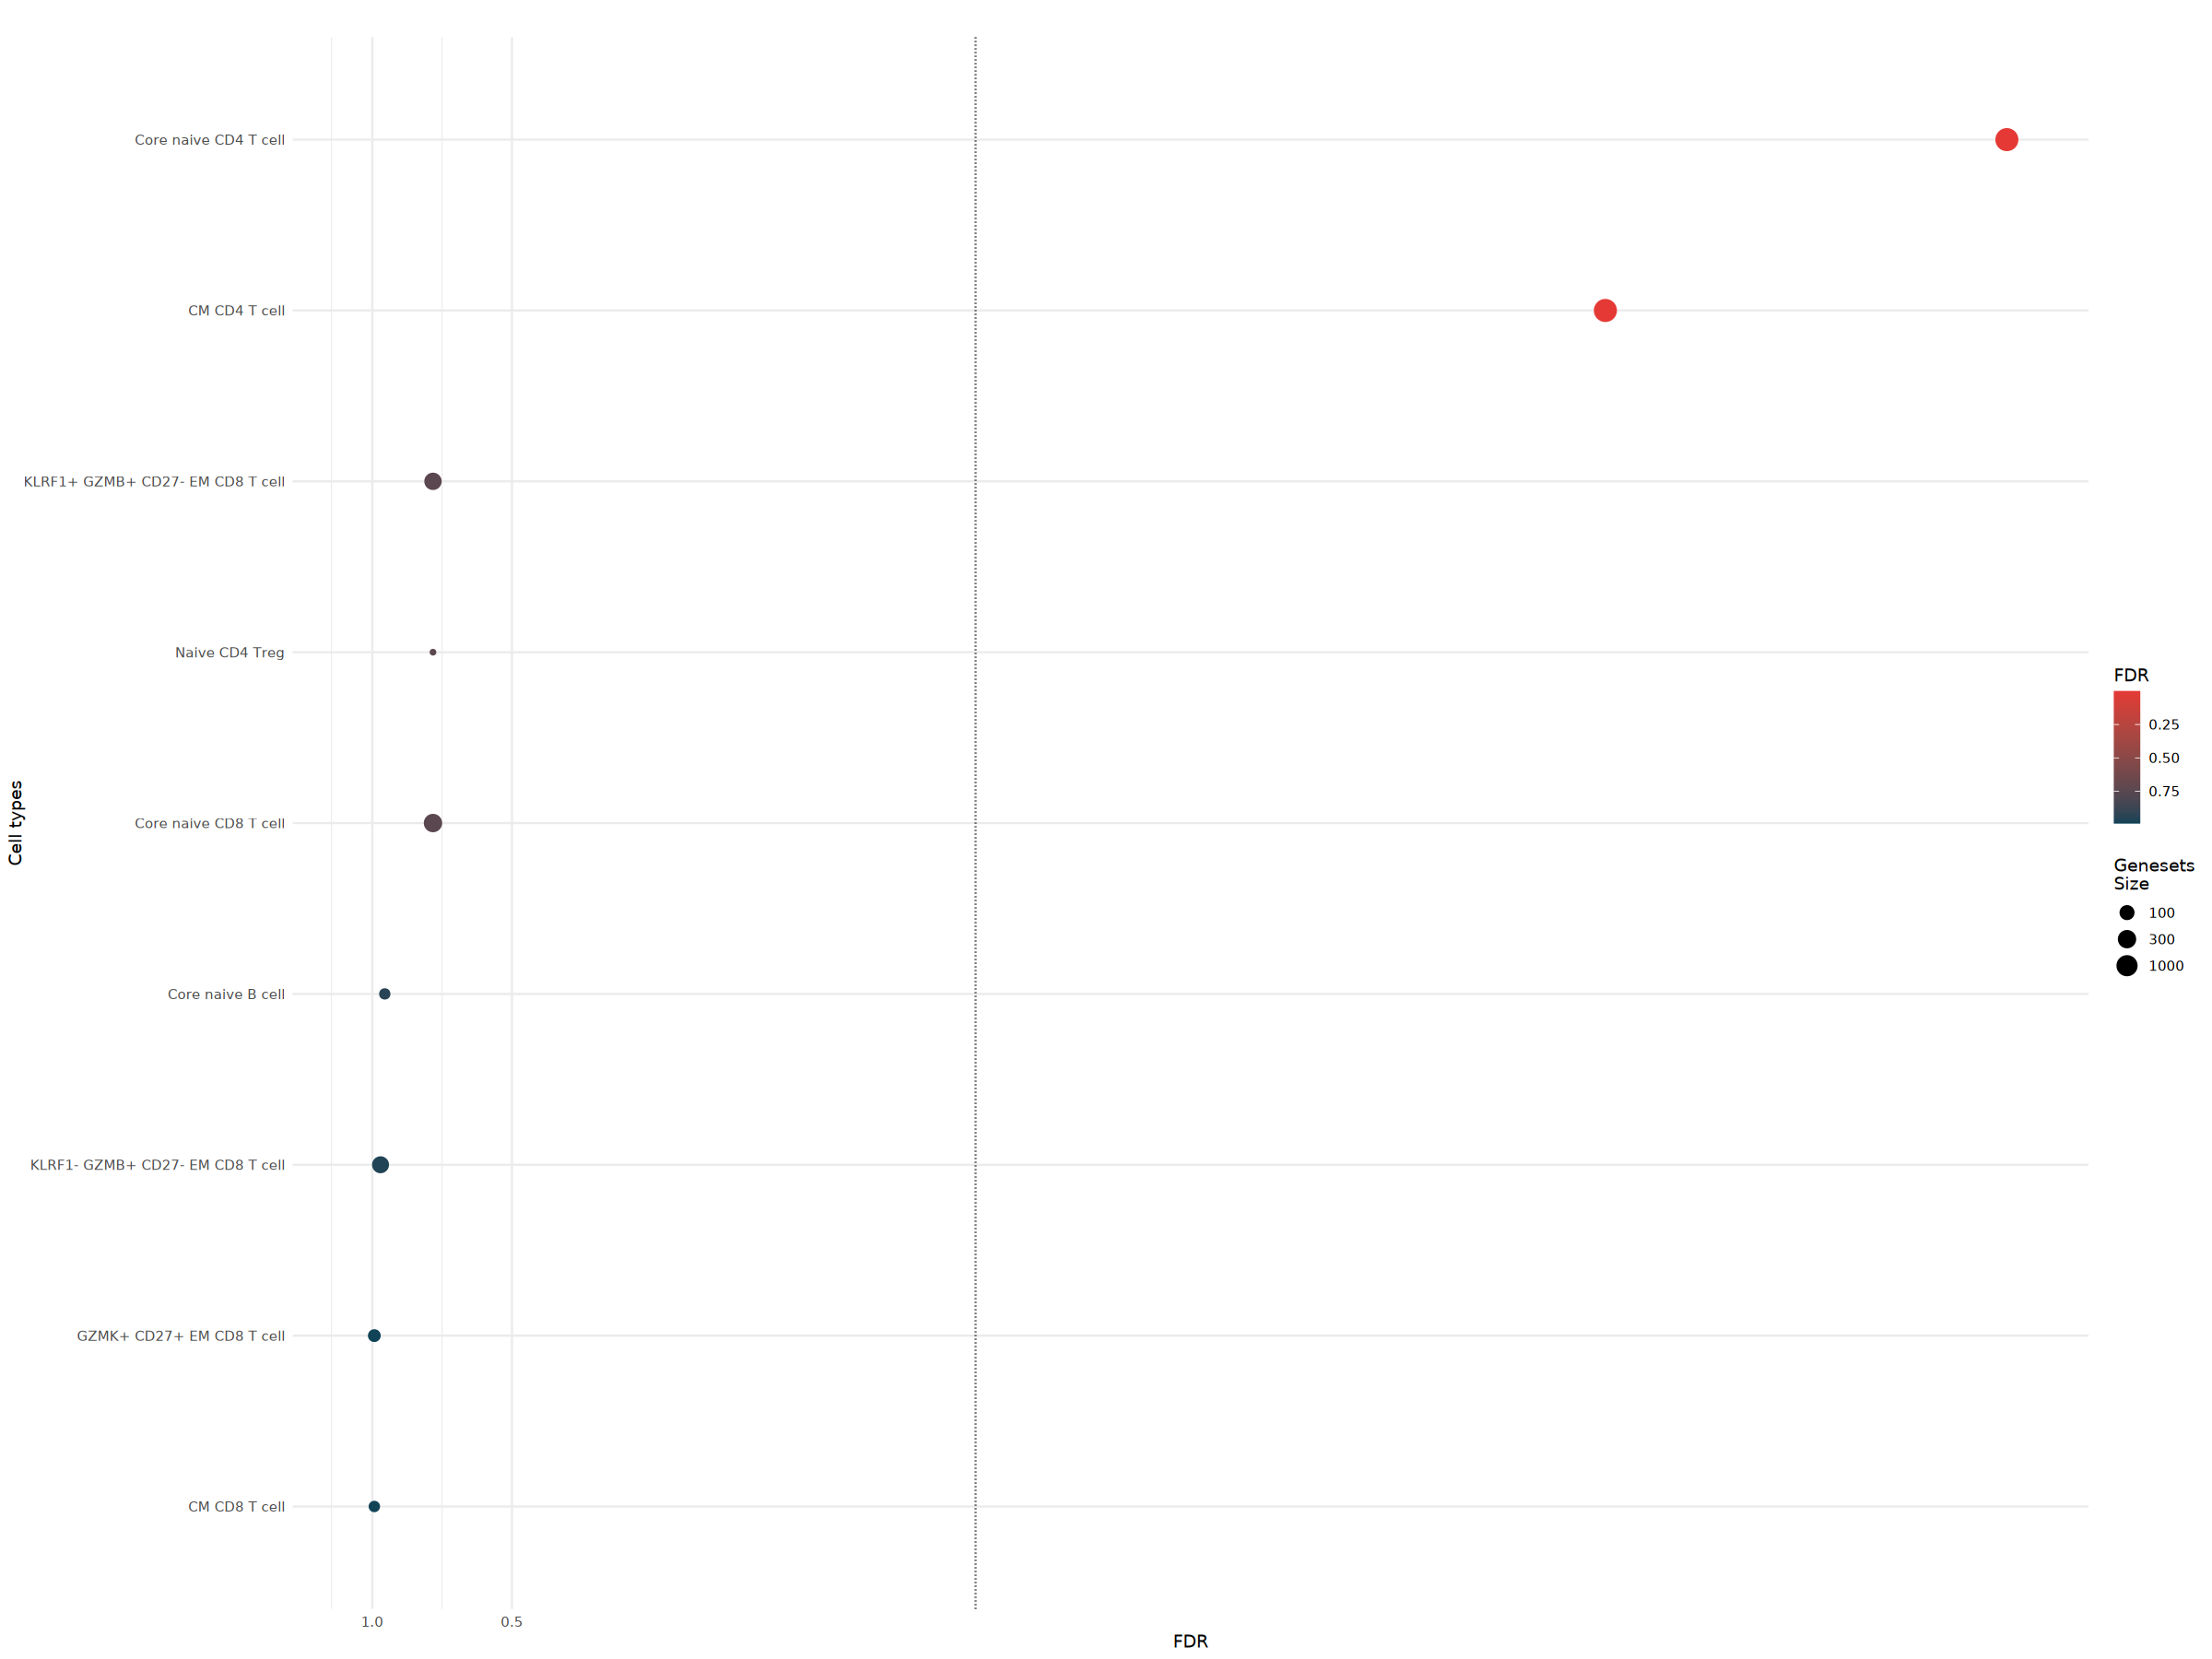

In [31]:
p1 <- hyp_dots(hyp_obj) + theme_minimal() + xlab('Cell types')
p1
ggsave(file.path(fig_path, paste0(proj_name, 'gene_signature_abt_responder.pdf')), width = 6, height = 4)

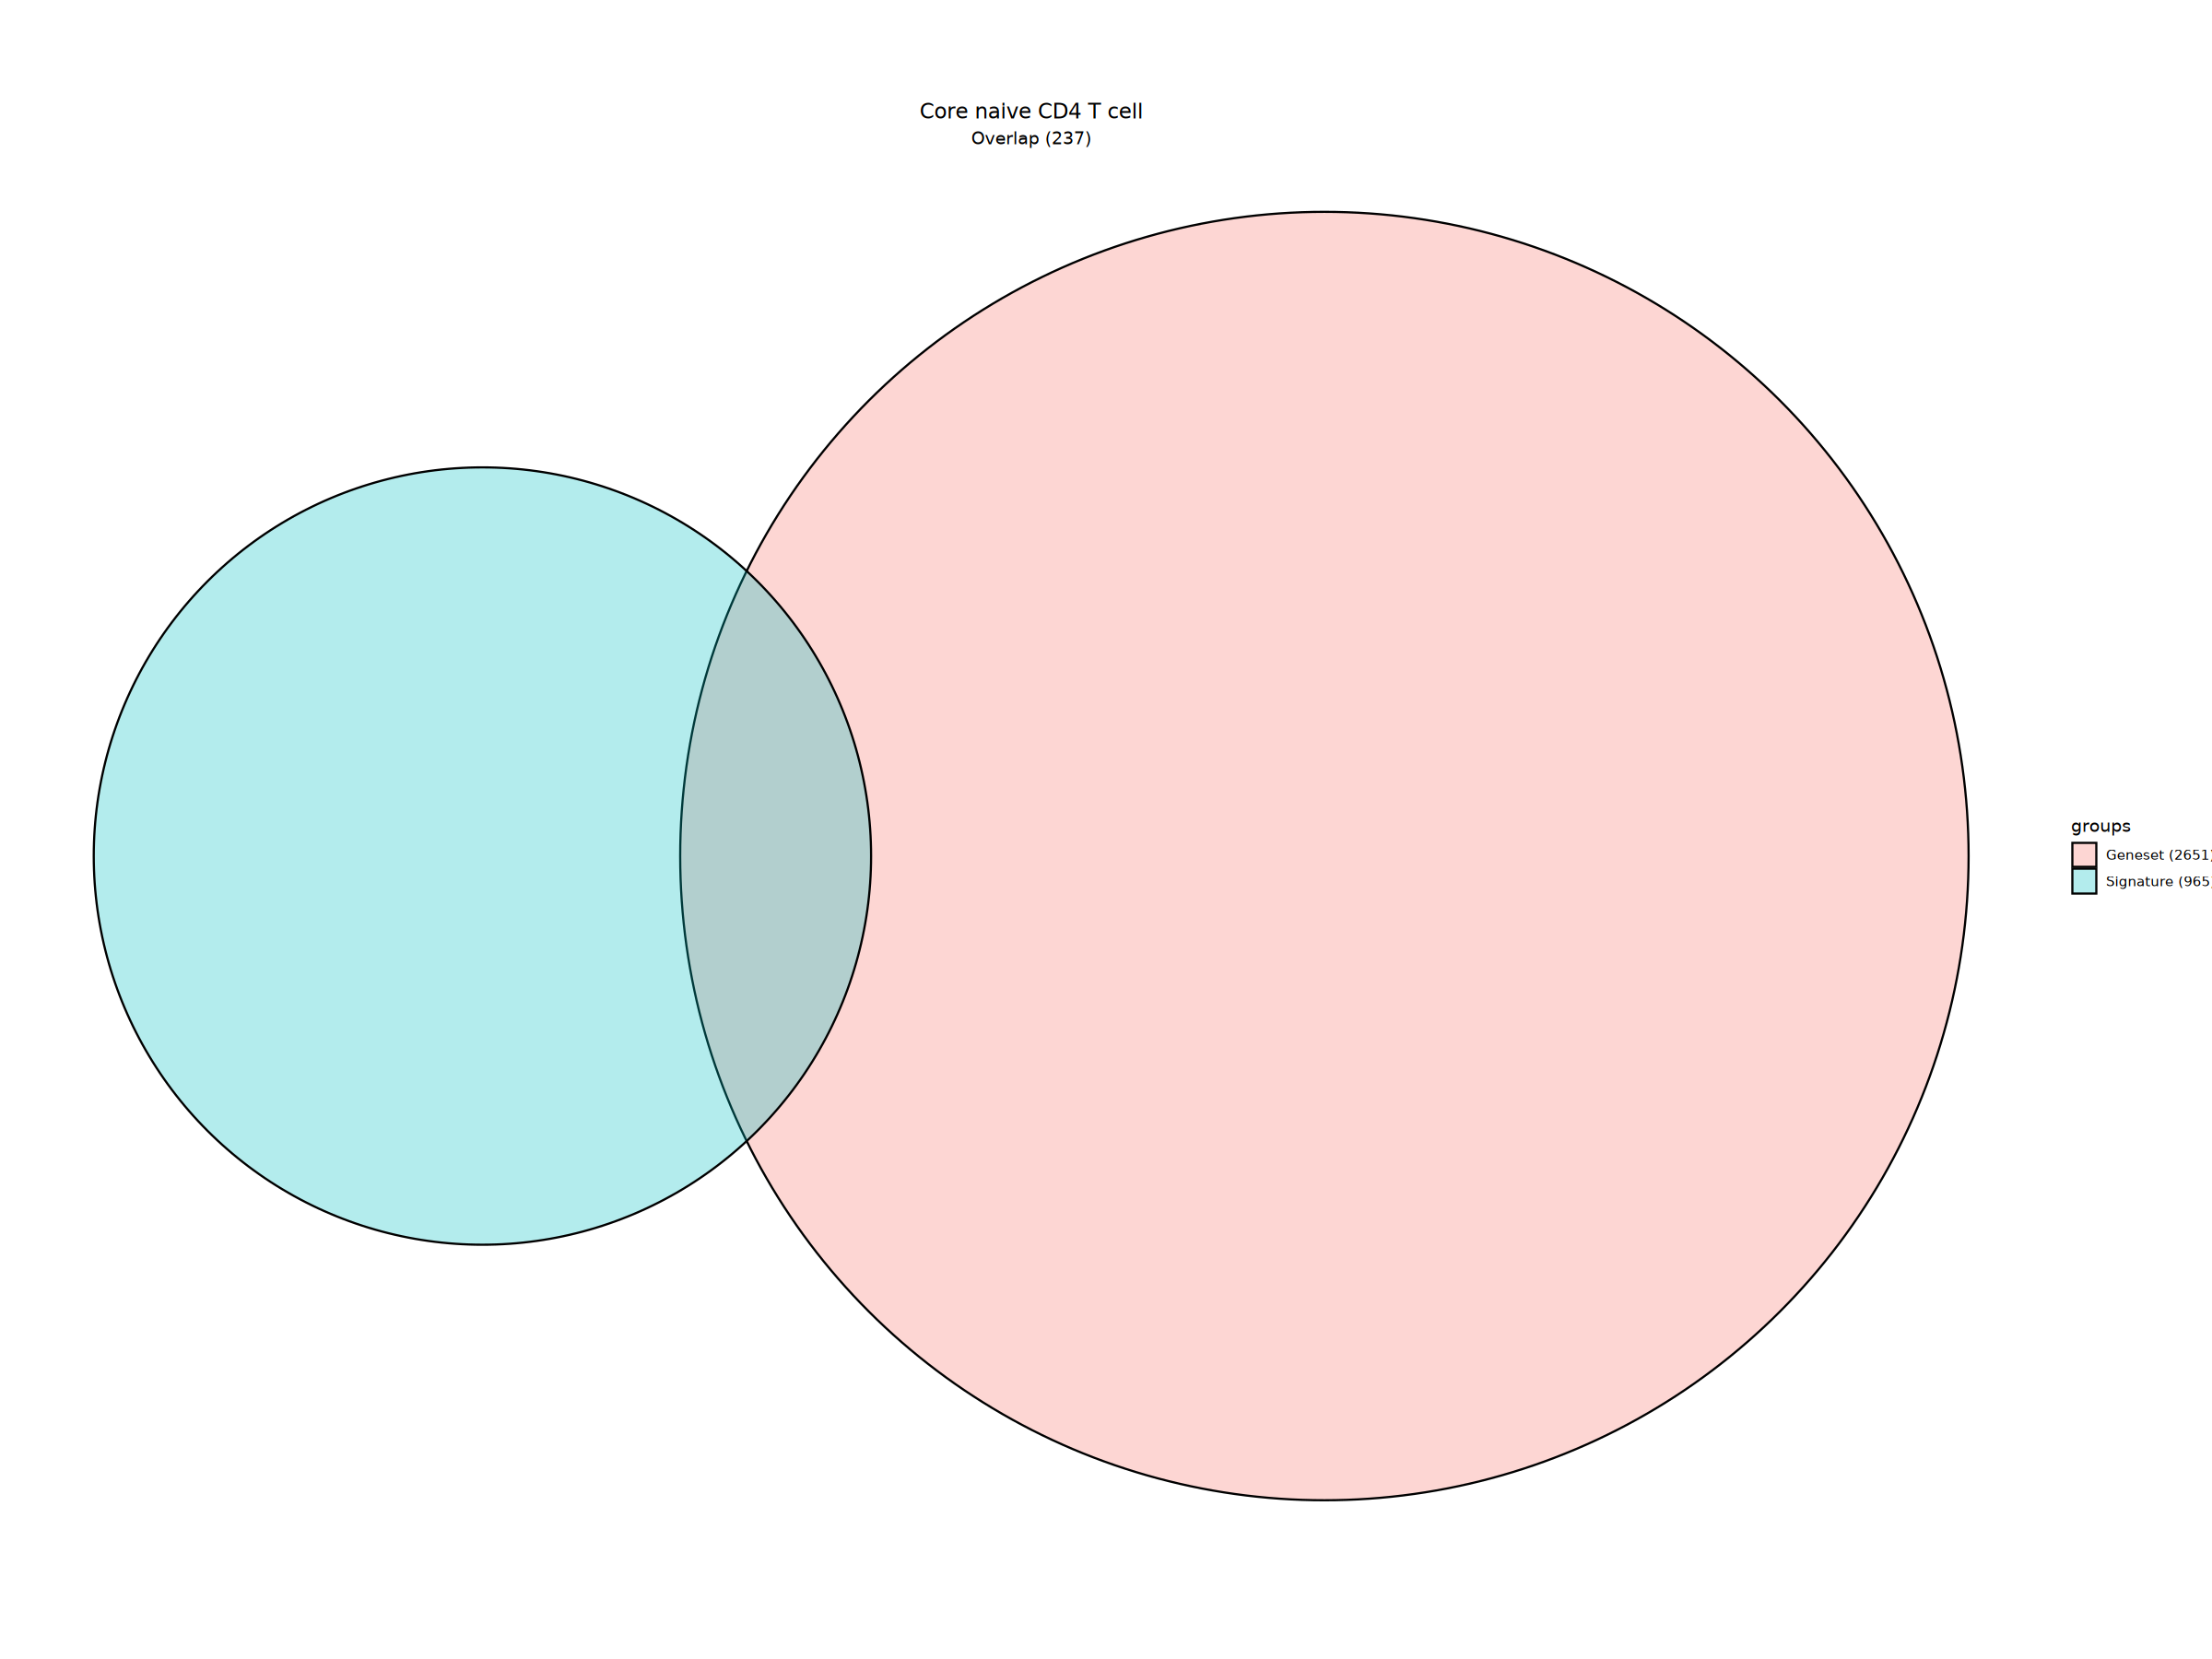

In [32]:
hyp_obj$plots[[1]]

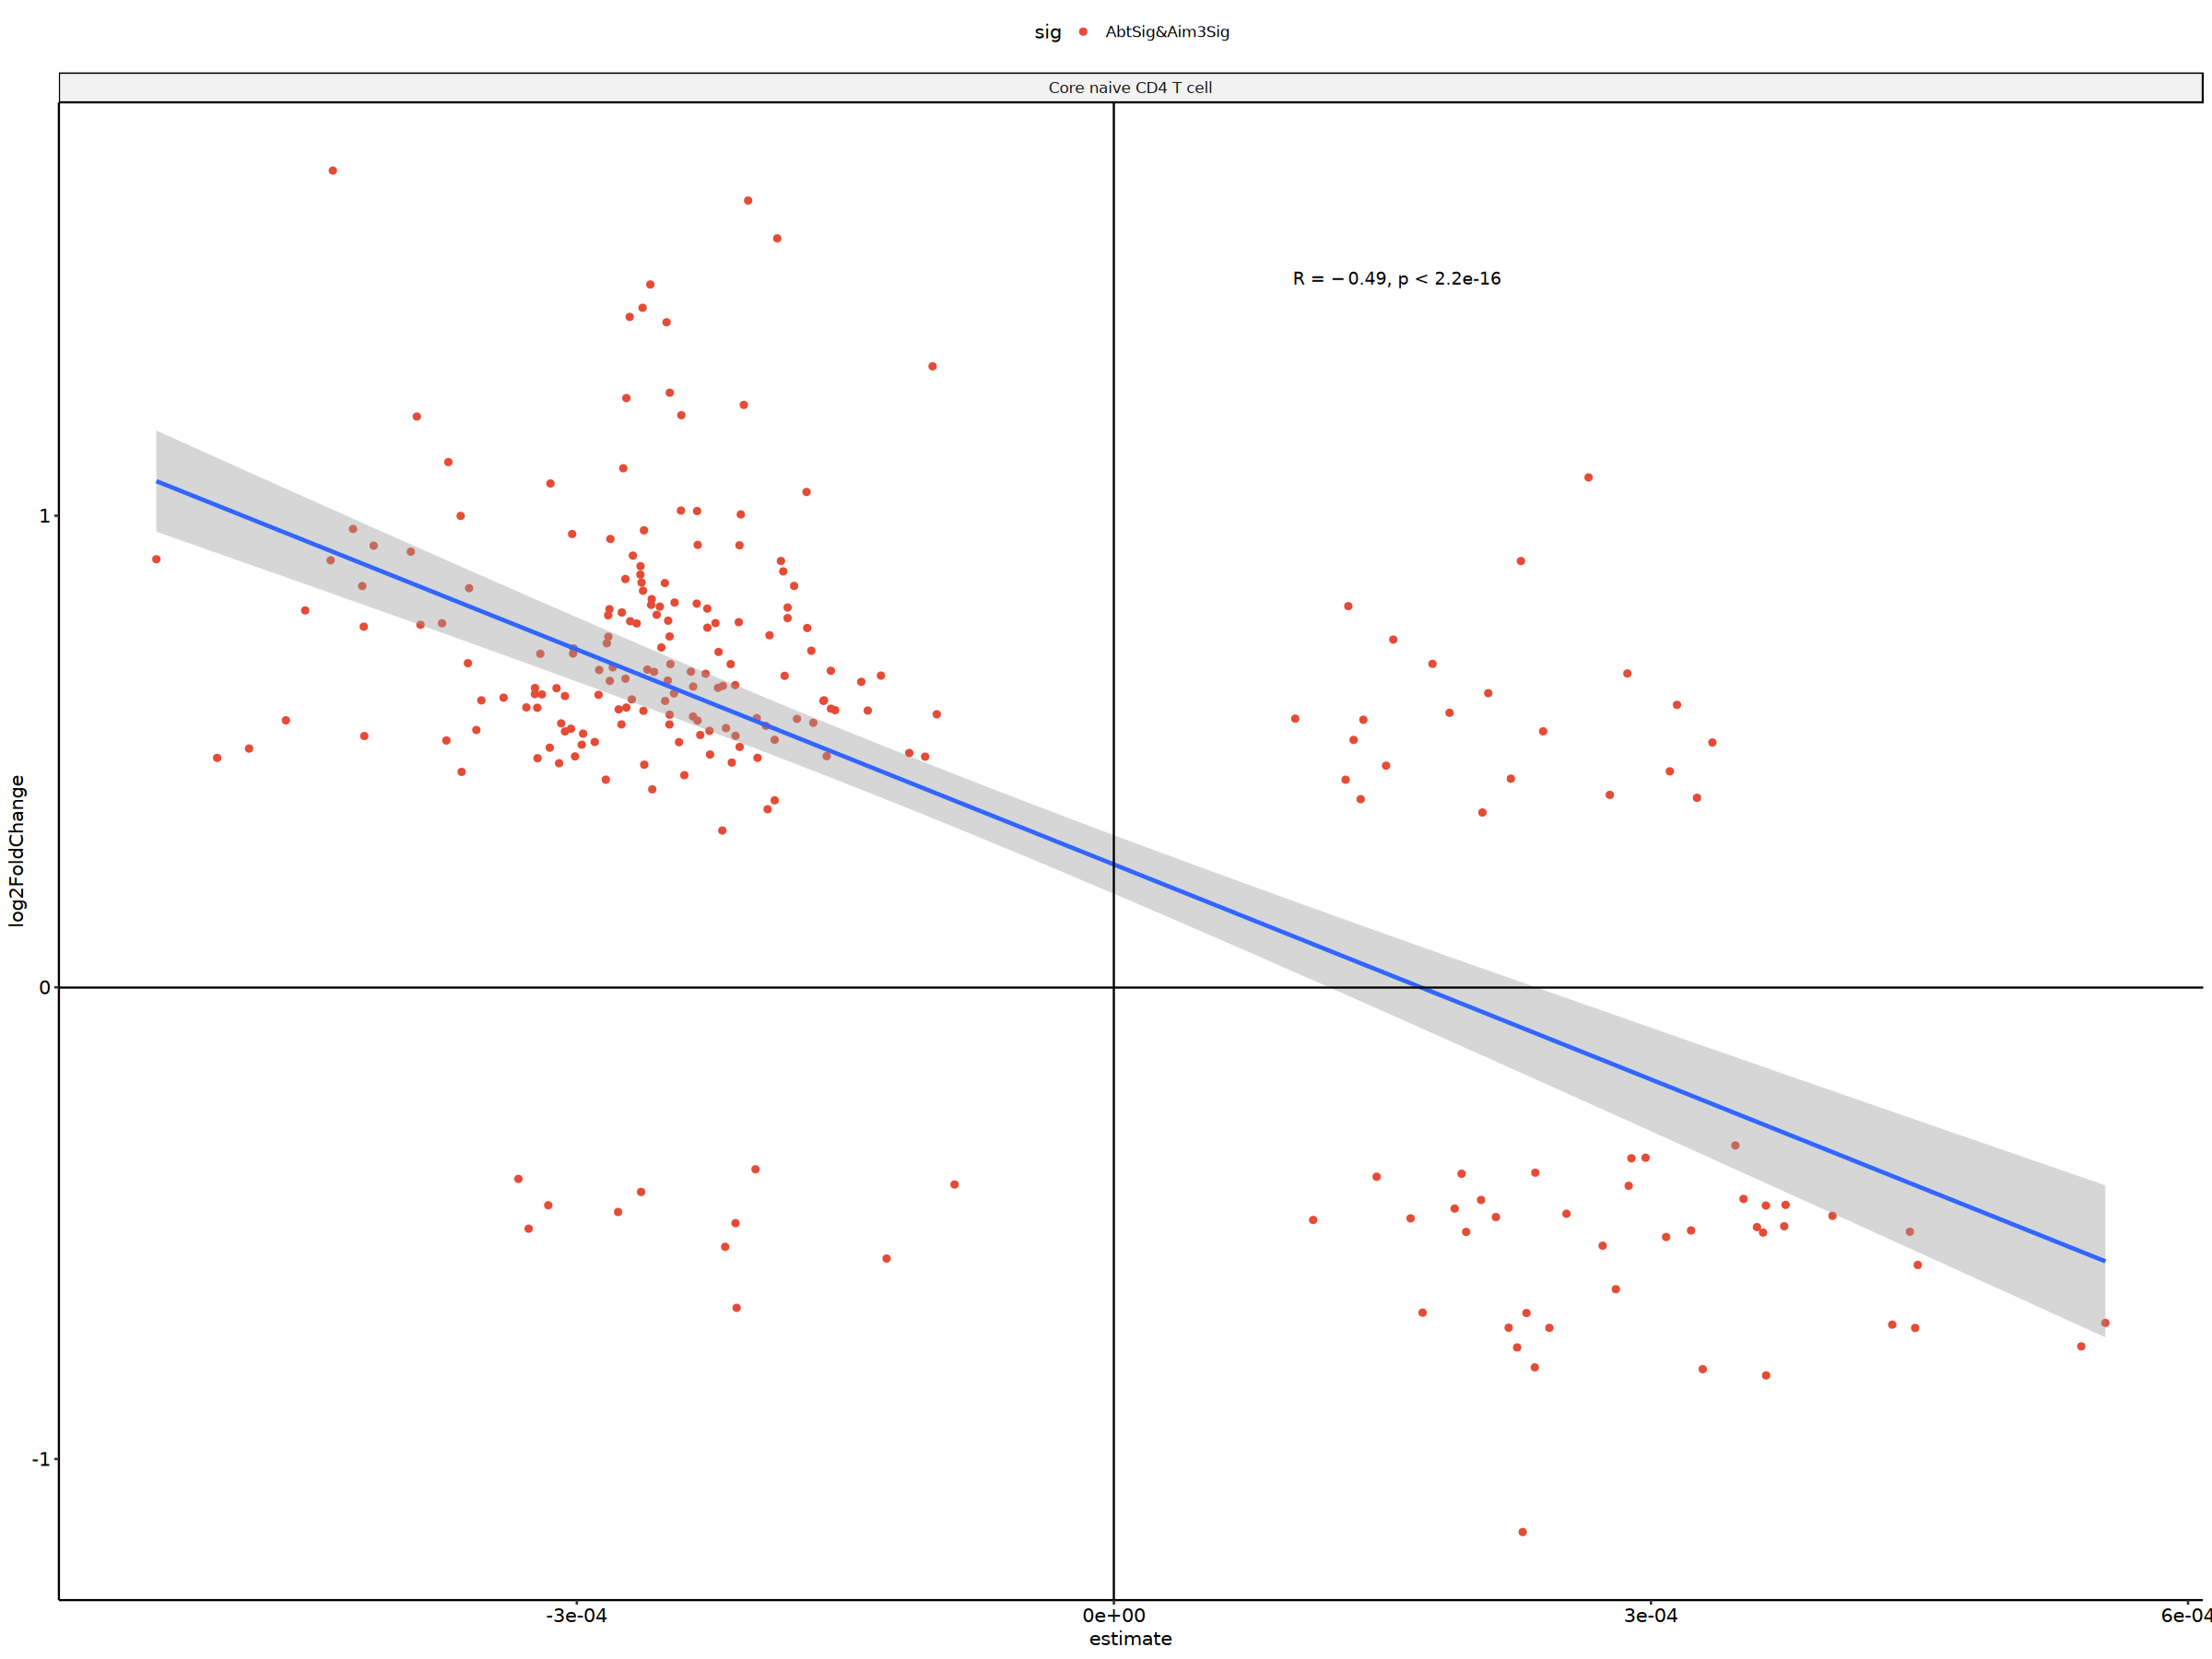

In [33]:
# plot the significant genes
abt_aim3_degs_comparison %>% filter(q_values_abt<0.1)%>%
    filter(cell_type%in%c('Core naive CD4 T cell'))%>%
    ggplot(aes(y=log2FoldChange, x=estimate
                          )) +
    geom_point(aes(color=sig)) +
    # ggrepel::geom_text_repel(aes(label=gene), 
    #                         ) +
    stat_smooth(method = "lm", 
              formula = y ~ x, 
              geom = "smooth") + 
    geom_vline(xintercept = 0)+ geom_hline(yintercept = 0)+ 
    ggpubr::stat_cor(method = "spearman", label.x = 0.0001, label.y = 1.5)+
    facet_wrap(vars(cell_type)) + scale_color_manual(values = npg_color) + theme_pubr()
ggsave(file.path(fig_path, paste0(proj_name,'abecetpt_responder_Aim3_deg_cd4na_logfc_cor_plot.pdf')),
       width=4, height=4)

Warning message:
“ggrepel: 2630 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 2591 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


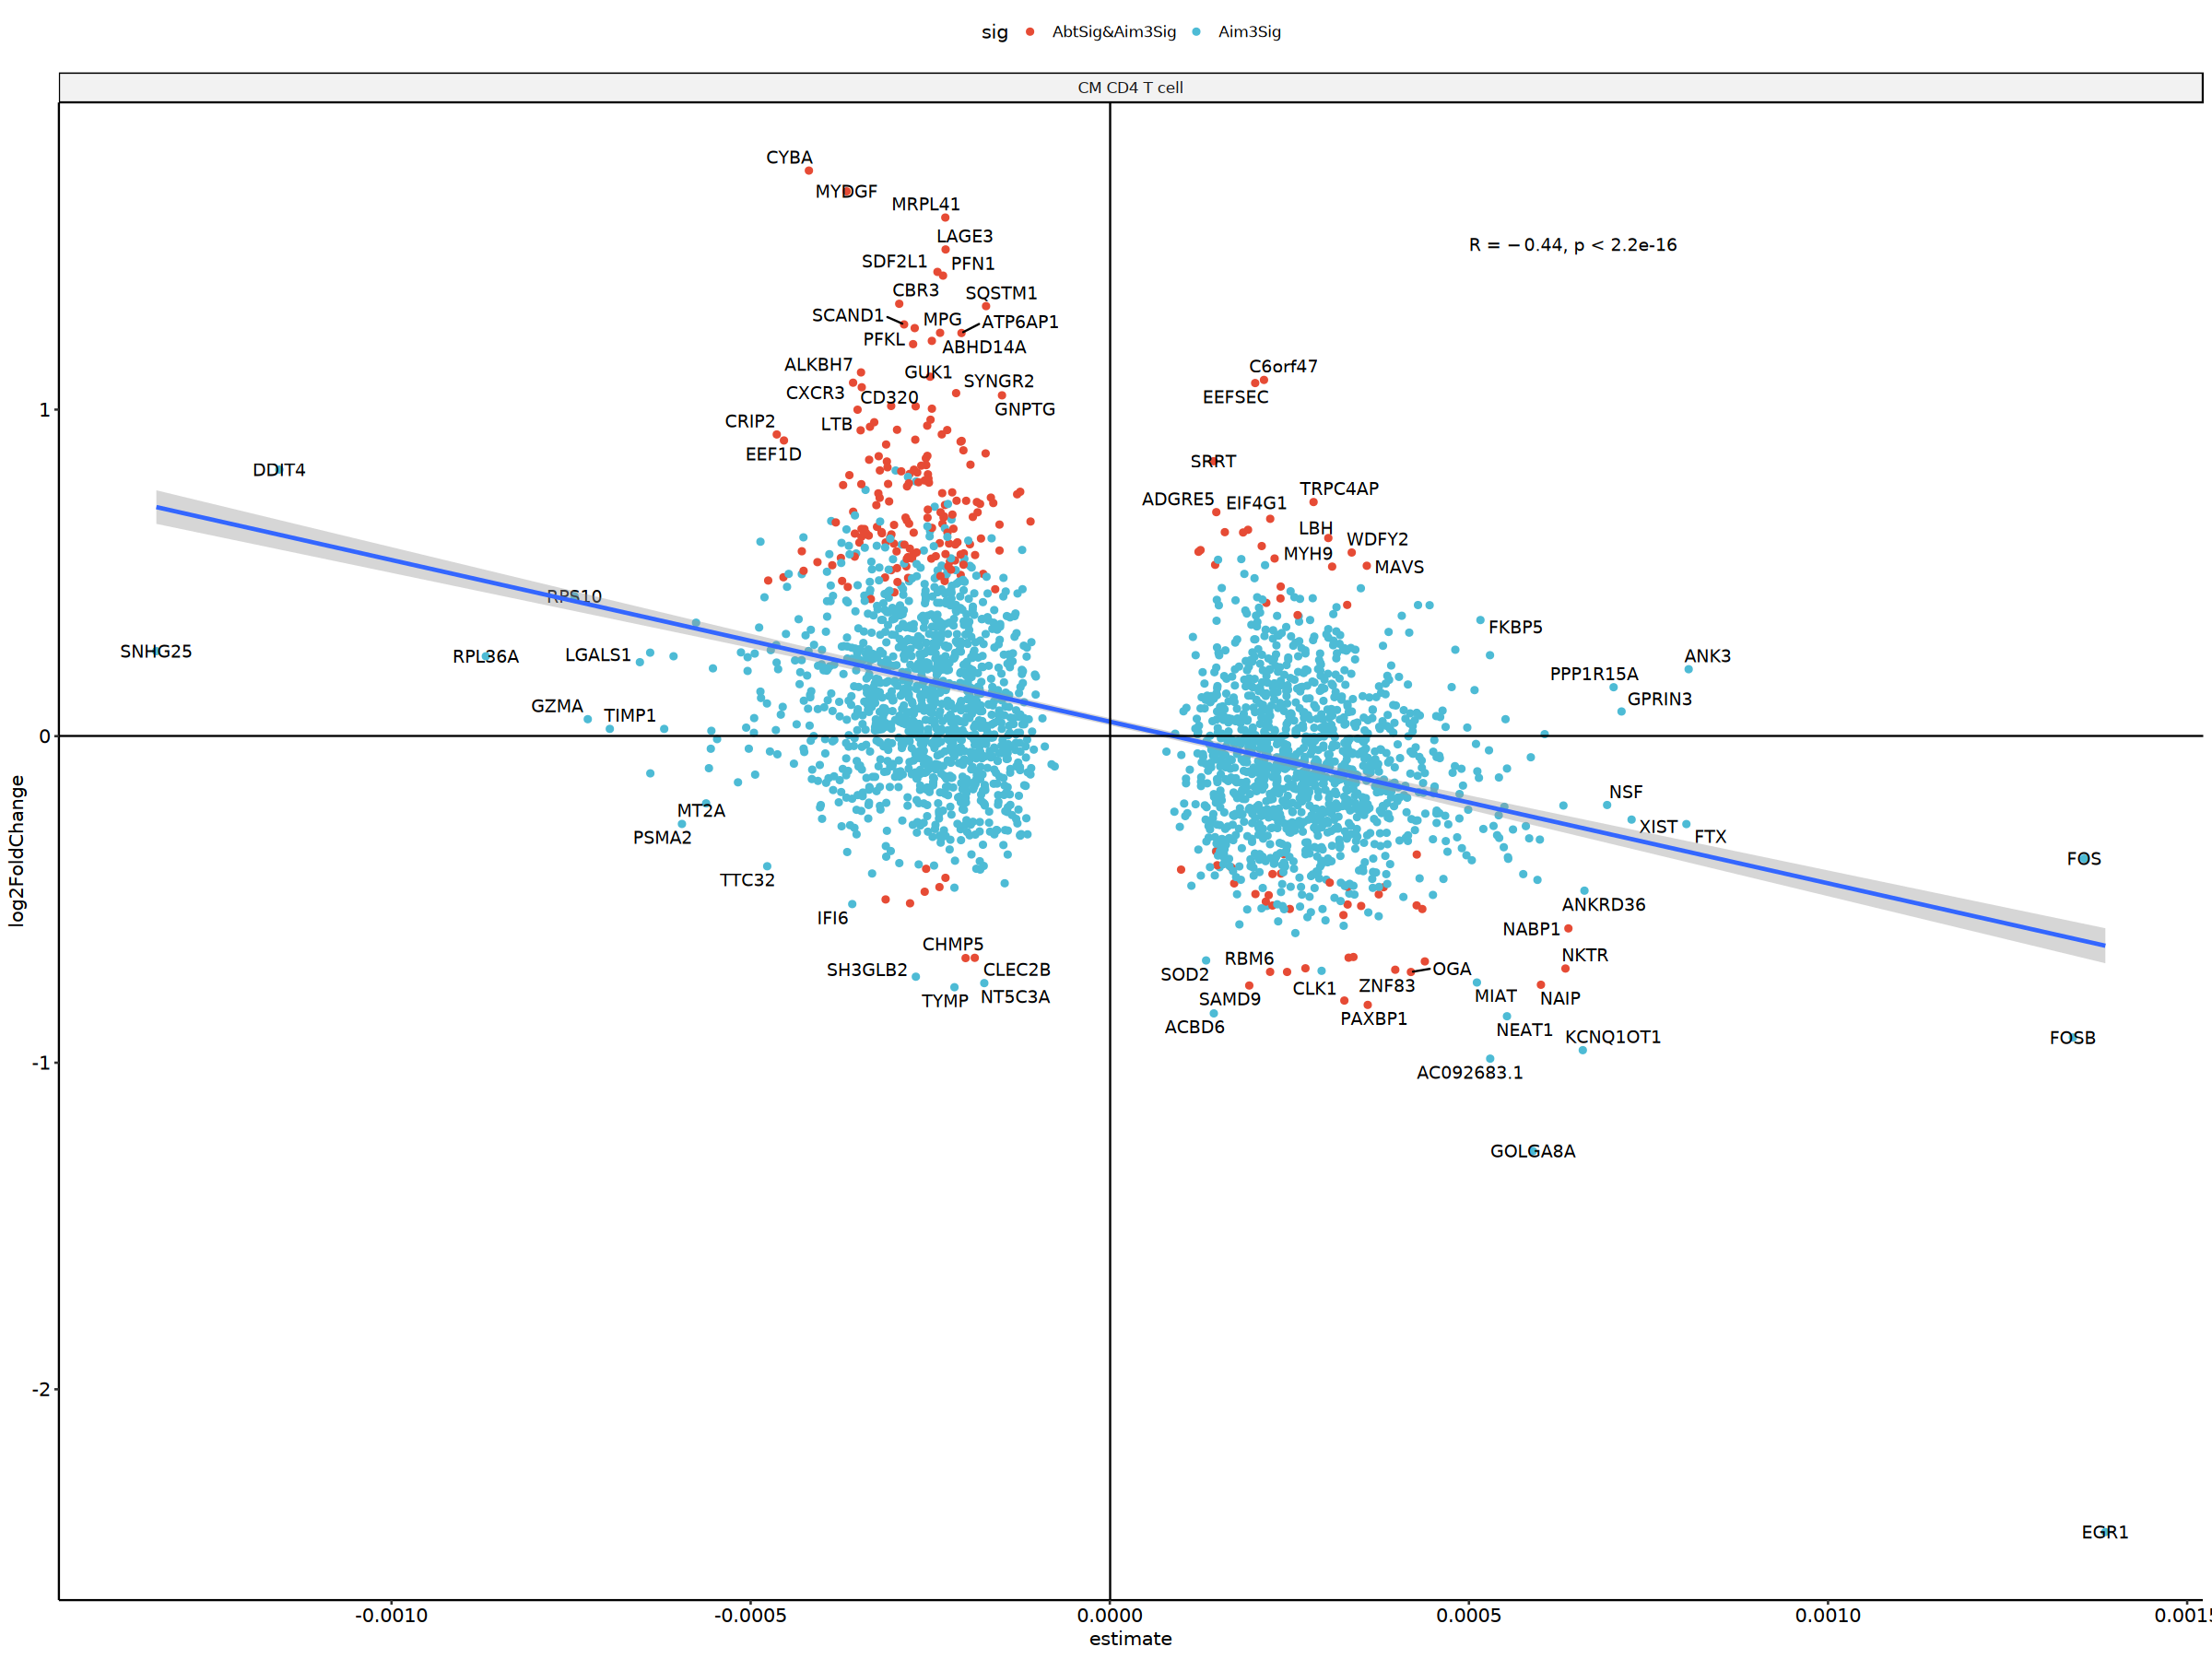

In [34]:
# plot the significant genes
abt_aim3_degs_comparison %>%
    filter(cell_type%in%c('CM CD4 T cell'))%>%
    ggplot(aes(y=log2FoldChange, x=estimate
                          )) +
    geom_point(aes(color=sig)) +
    ggrepel::geom_text_repel(aes(label=gene), 
                            ) +
    stat_smooth(method = "lm", 
              formula = y ~ x, 
              geom = "smooth") + 
    geom_vline(xintercept = 0)+ geom_hline(yintercept = 0)+ 
    ggpubr::stat_cor(method = "spearman", label.x = 0.0005, label.y = 1.5)+
    facet_wrap(vars(cell_type)) + scale_color_manual(values = npg_color) + theme_pubr()
ggsave(file.path(fig_path, paste0(proj_name,
                                  'abecetpt_responder_Aim3_deg_cd4cm_logfc_cor_plot.png')),
       width=16, height=12)

### run mcnemar test

In [35]:
# run mcnemar test
abt_aim3_degs_comparison_counts <- abt_aim3_degs_comparison %>% filter(q_values_abt<0.1)%>%
    group_by(cell_type, aim3_direction, abt_direction)%>% tally()%>%
    ungroup()
celltypes_test = abt_aim3_degs_comparison_counts%>%
    group_by(cell_type)%>%tally()%>%filter(n>=4)%>%pull(cell_type)
celltypes_test

mcnemar_res <- abt_aim3_degs_comparison_counts%>%filter(cell_type%in%celltypes_test)%>%group_by(cell_type)%>% 
    group_modify(~run_mcnemar_test(.x))
# cont_counts = abt_aim3_degs_comparison_counts%>%filter(cell_type=='Core_naive_CD4_T_cell')%>%
#     pivot_wider(id_cols = aim3_direction, names_from = abt_direction , values_from = n)
# sex_counts = aim1_filedesc_fl%>%group_by(status, subject.biologicalSex)%>%tally()%>%
#     pivot_wider(id_cols = subject.biologicalSex, names_from = status , values_from = n)
# sex_counts 
mcnemar_res

[1] "CM CD4 T cell"                    "Core naive CD4 T cell"           
[3] "KLRF1+ GZMB+ CD27- EM CD8 T cell" "KLRF1- GZMB+ CD27- EM CD8 T cell"

cell_type,n,statistic,df,p,p.signif,method
<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
CM CD4 T cell,233,79.84653,1,4.05e-19,****,McNemar test
Core naive CD4 T cell,237,74.16176,1,7.20e-18,****,McNemar test
KLRF1+ GZMB+ CD27- EM CD8 T cell,16,1.50000,1,2.21e-01,ns,McNemar test
KLRF1- GZMB+ CD27- EM CD8 T cell,11,3.12500,1,7.71e-02,ns,McNemar test


In [36]:
abt_aim3_degs_comparison_counts%>%
    filter(cell_type%in%c('CM CD4 T cell'))%>%
            pivot_wider(id_cols = c(cell_type, aim3_direction), 
                        names_from = abt_direction , values_from = n)

cell_type,aim3_direction,abt_down,abt_up
<chr>,<chr>,<int>,<int>
CM CD4 T cell,aim3_down,8,165
CM CD4 T cell,aim3_up,37,23


In [37]:
# GGally::ggtable(abt_aim3_degs_comparison %>% filter(q_values_abt<0.1)%>%
#     filter(cell_type%in%c('Core_naive_CD4_T_cell', 'CM_CD4_T_cell')),
#         "cell_type", c("aim3_direction", "abt_direction"))

Warning message:
“ggrepel: 2638 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 176 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 2587 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 199 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 2638 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 178 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 2587 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 200 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


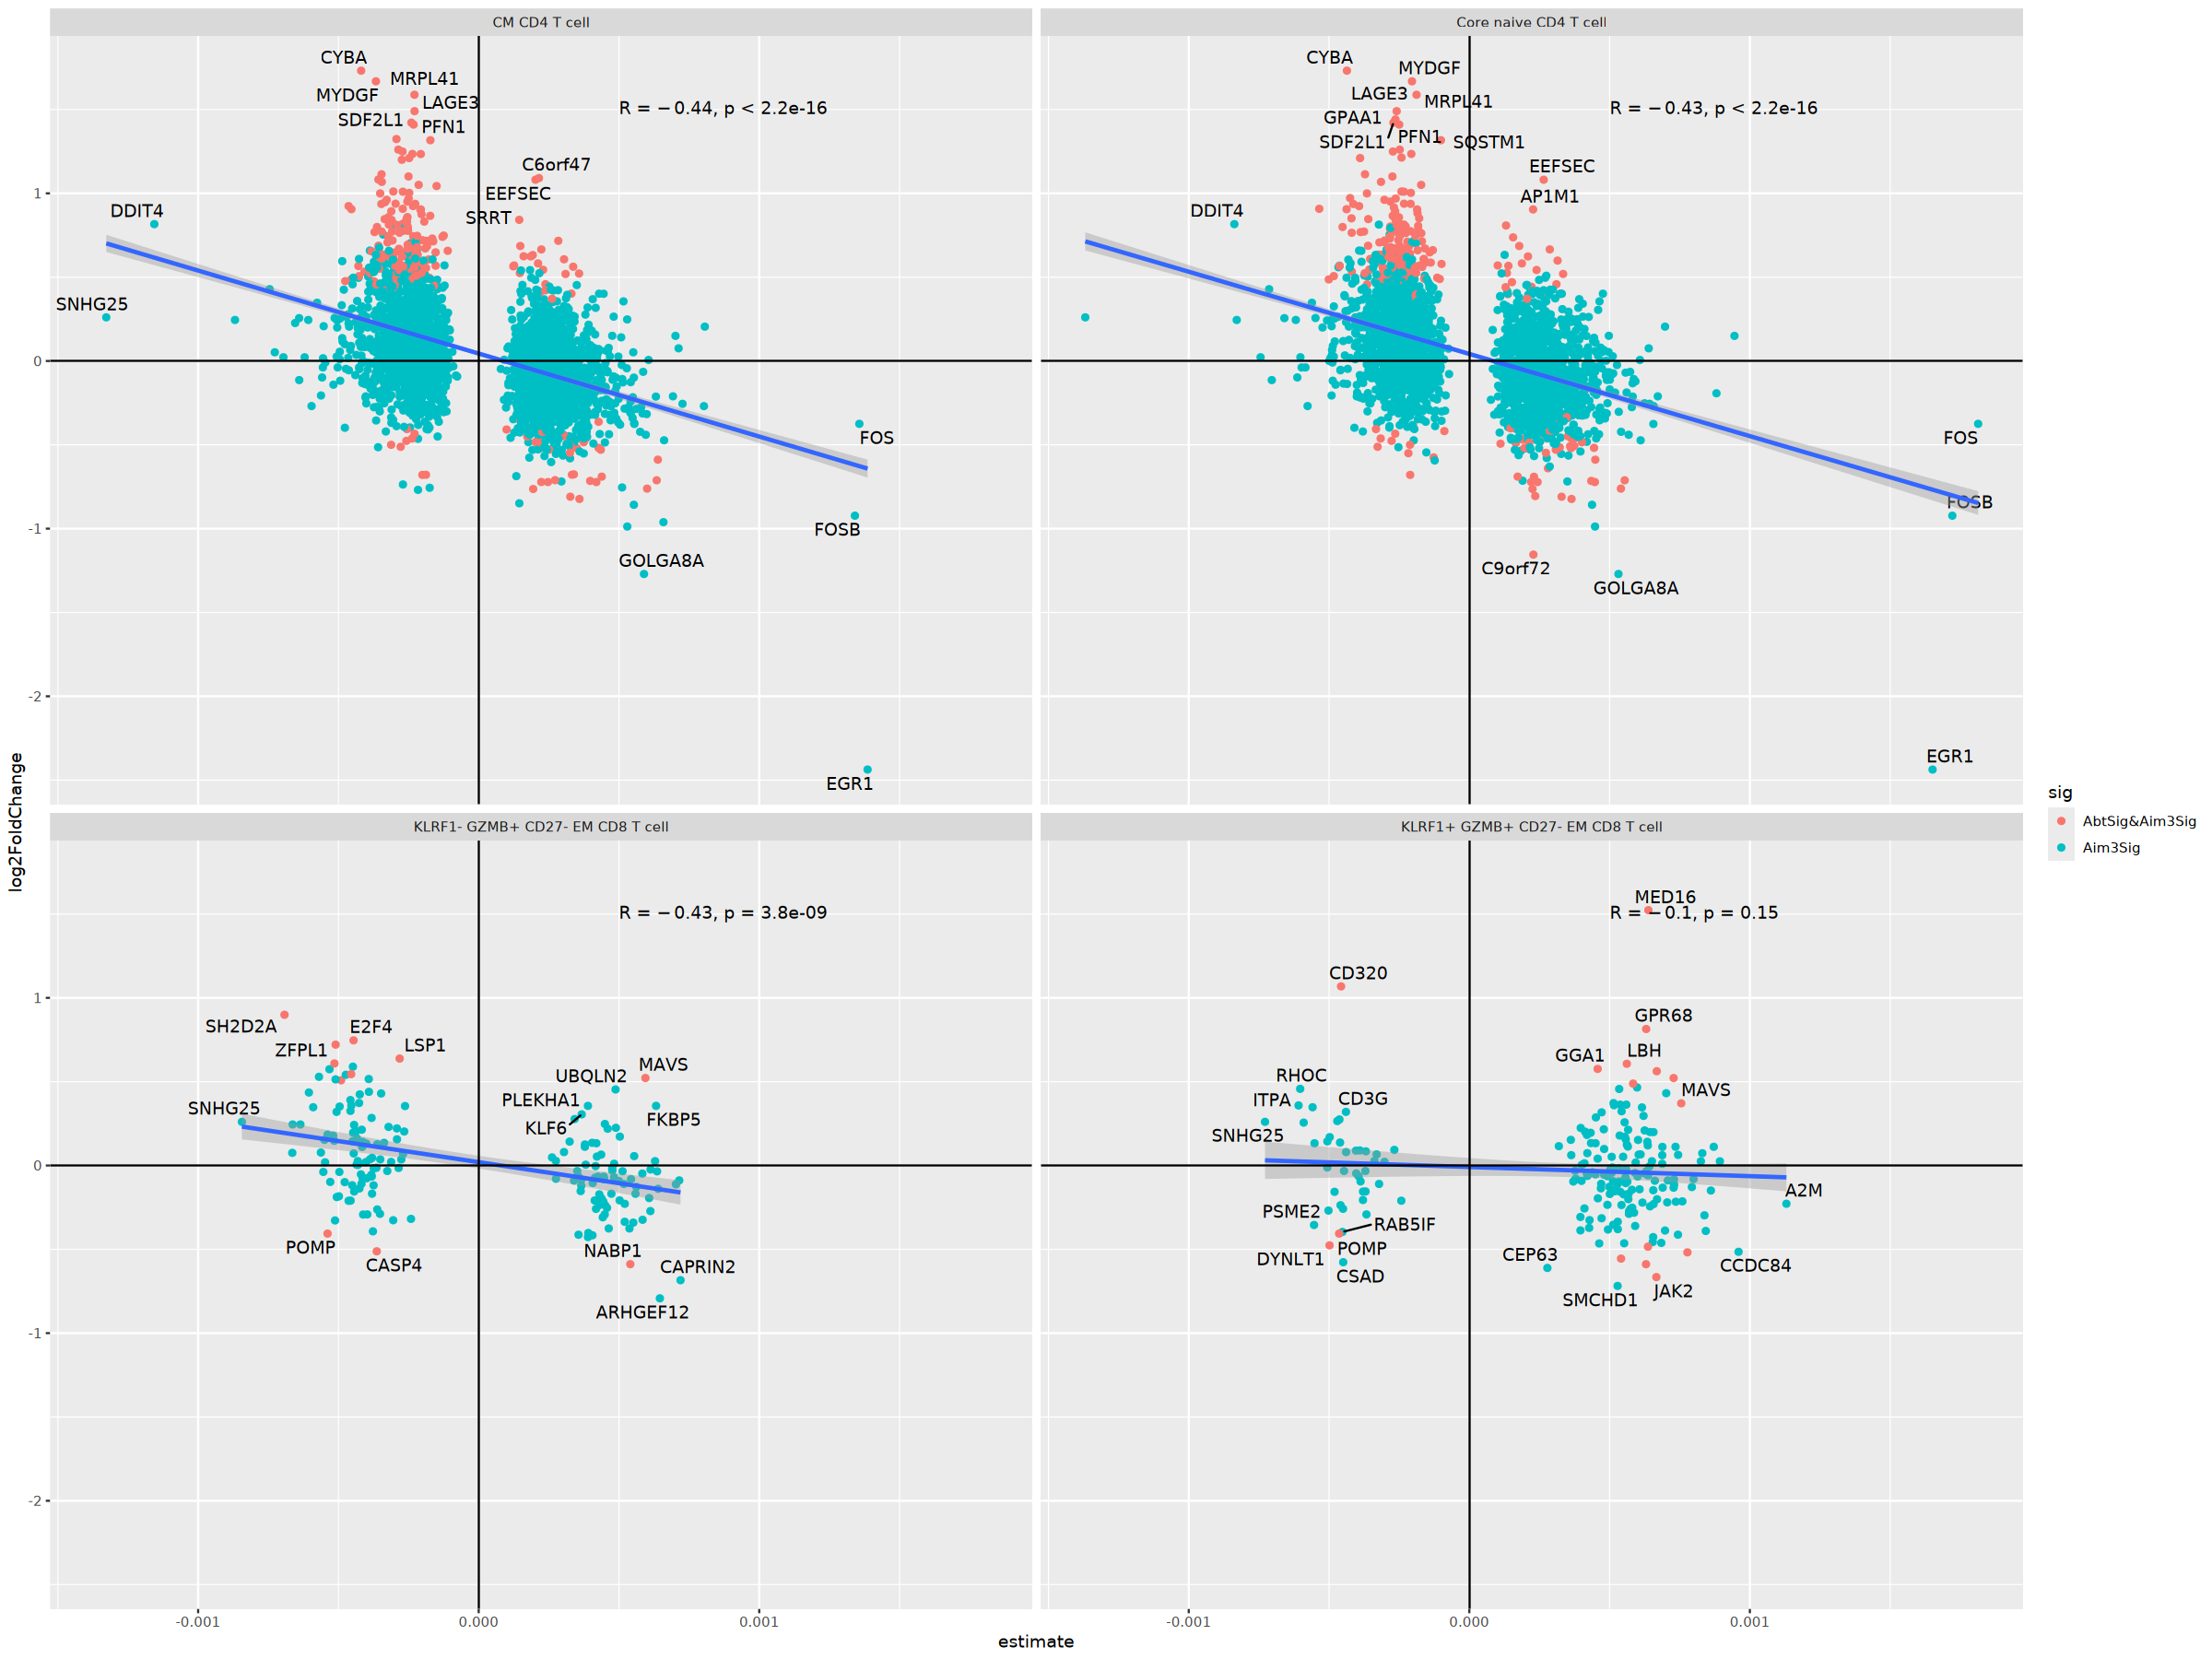

In [38]:
abt_aim3_degs_comparison%>%filter(cell_type%in%	celltypes_test)%>%
    ggplot(aes(y=log2FoldChange, x=estimate
                          )) +
    geom_point(aes(color=sig)) +
    ggrepel::geom_text_repel(aes(label=gene)
                            ) +
    stat_smooth(method = "lm", 
              formula = y ~ x, 
              geom = "smooth") + 
    geom_vline(xintercept = 0)+ geom_hline(yintercept = 0)+ 
    ggpubr::stat_cor(method = "spearman", label.x = 0.0005, label.y = 1.5)+
    facet_wrap(vars(cell_type))
ggsave(file.path(fig_path, paste0('abecetpt_Aim3_deg_all_celltype_logfc_cor_plot.png')),
       width=8, height=6)

In [39]:
# abt_cor <- abt_aim3_degs_comparison %>% filter(!is.na(log2FoldChange) & !is.na(estimate))%>% 
#   group_by(cell_type) %>% 
#   rstatix::cor_test(log2FoldChange, estimate, method =  "spearman", 
#                     conf.level=TRUE)

In [40]:
# p1 <- ggplot(abt_cor, aes(x=cell_type, y=cor)) +
#   geom_segment( aes(x=cell_type, xend=cell_type, y=0, yend=cor), color="grey") +
#   geom_point( size=2) + #ylim(-0.5, 1)+
#   geom_hline(yintercept = 0 ,linetype=2)+
#  # geom_errorbar( aes( ymin=cor-sd, ymax=value+sd), width=0.4, colour="orange", alpha=0.9, size=1.3)+
#   theme_light() +  coord_flip()+
#   theme(
#     panel.grid.major.x = element_blank(),
#     panel.border = element_blank(),
#     axis.ticks.x = element_blank(),
#     #legend.position="none"
#   ) + scale_color_manual(values = npg_color)+
#   xlab("") +
#   ylab("spearman correlation coefficient") +
#     ggtitle('responder', )
# p1

# analyze non-responder

In [41]:
# seperate responder and non-responder and construct the deseq2 object
# non-responder
nonres_sample = sampleTable%>%filter(response=='Non_responder')
nonres_count = counts[, colnames(counts)%in%rownames(nonres_sample)]
# res_sample
dds_nonresp <- DESeqDataSetFromMatrix(round(nonres_count), nonres_sample, ~ patient + time)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


In [42]:
smallestGroupSize <- 15
keep <- rowSums(counts(dds_nonresp) >= 10) >= smallestGroupSize
dds_nonresp <- dds_nonresp[keep,]
dds_nonresp

class: DESeqDataSet 
dim: 13275 30 
metadata(1): version
assays(1): counts
rownames(13275): DPM1 SCYL3 ... AC133644.2 AC064836.3
rowData names(0):
colnames(30): NR01_0M NR01_3M ... NR15_0M NR15_3M
colData names(4): sample patient time response

In [43]:
dds_nonresp$time <- factor(dds_nonresp$time, levels = c("0M","3M"))

In [44]:
# run deseq2 in non-responder
dds_nonresp <- DESeq(dds_nonresp)
dds_nonresp_res <- results(dds_nonresp)
dds_nonresp_res_tb = dds_nonresp_res%>%as_tibble(rownames = 'gene')

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [45]:
# # calculate the qvalues
dds_nonresp_res_tb <- dds_nonresp_res_tb %>% mutate(q_values = qvalue::qvalue(pvalue)$qvalues) %>%
    select(-padj)
dds_nonresp_res_tb%>%head()

gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DPM1,379.14259,-0.05712159,0.1720638,-0.3319792,0.73990500,0.9552337
SCYL3,343.65831,0.02574844,0.1391630,0.1850236,0.85321051,0.9655959
C1orf112,71.51417,-0.04306472,0.2046950,-0.2103848,0.83336736,0.9647510
FGR,5741.95475,-0.12543644,0.2116220,-0.5927381,0.55335644,0.9272609
CFH,63.91320,0.17075121,0.2480037,0.6885025,0.49113637,0.9160209
FUCA2,265.58381,-0.41320596,0.2245246,-1.8403593,0.06571551,0.6199254


In [46]:
# save the deg table
dds_nonresp_res_tb %>% write_csv(file.path(output_path, paste0(proj_name, 'nonresponder_pre_post_degs.csv')))

In [47]:
dds_nonresp_res_tb%>%filter(is.na(q_values))

gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


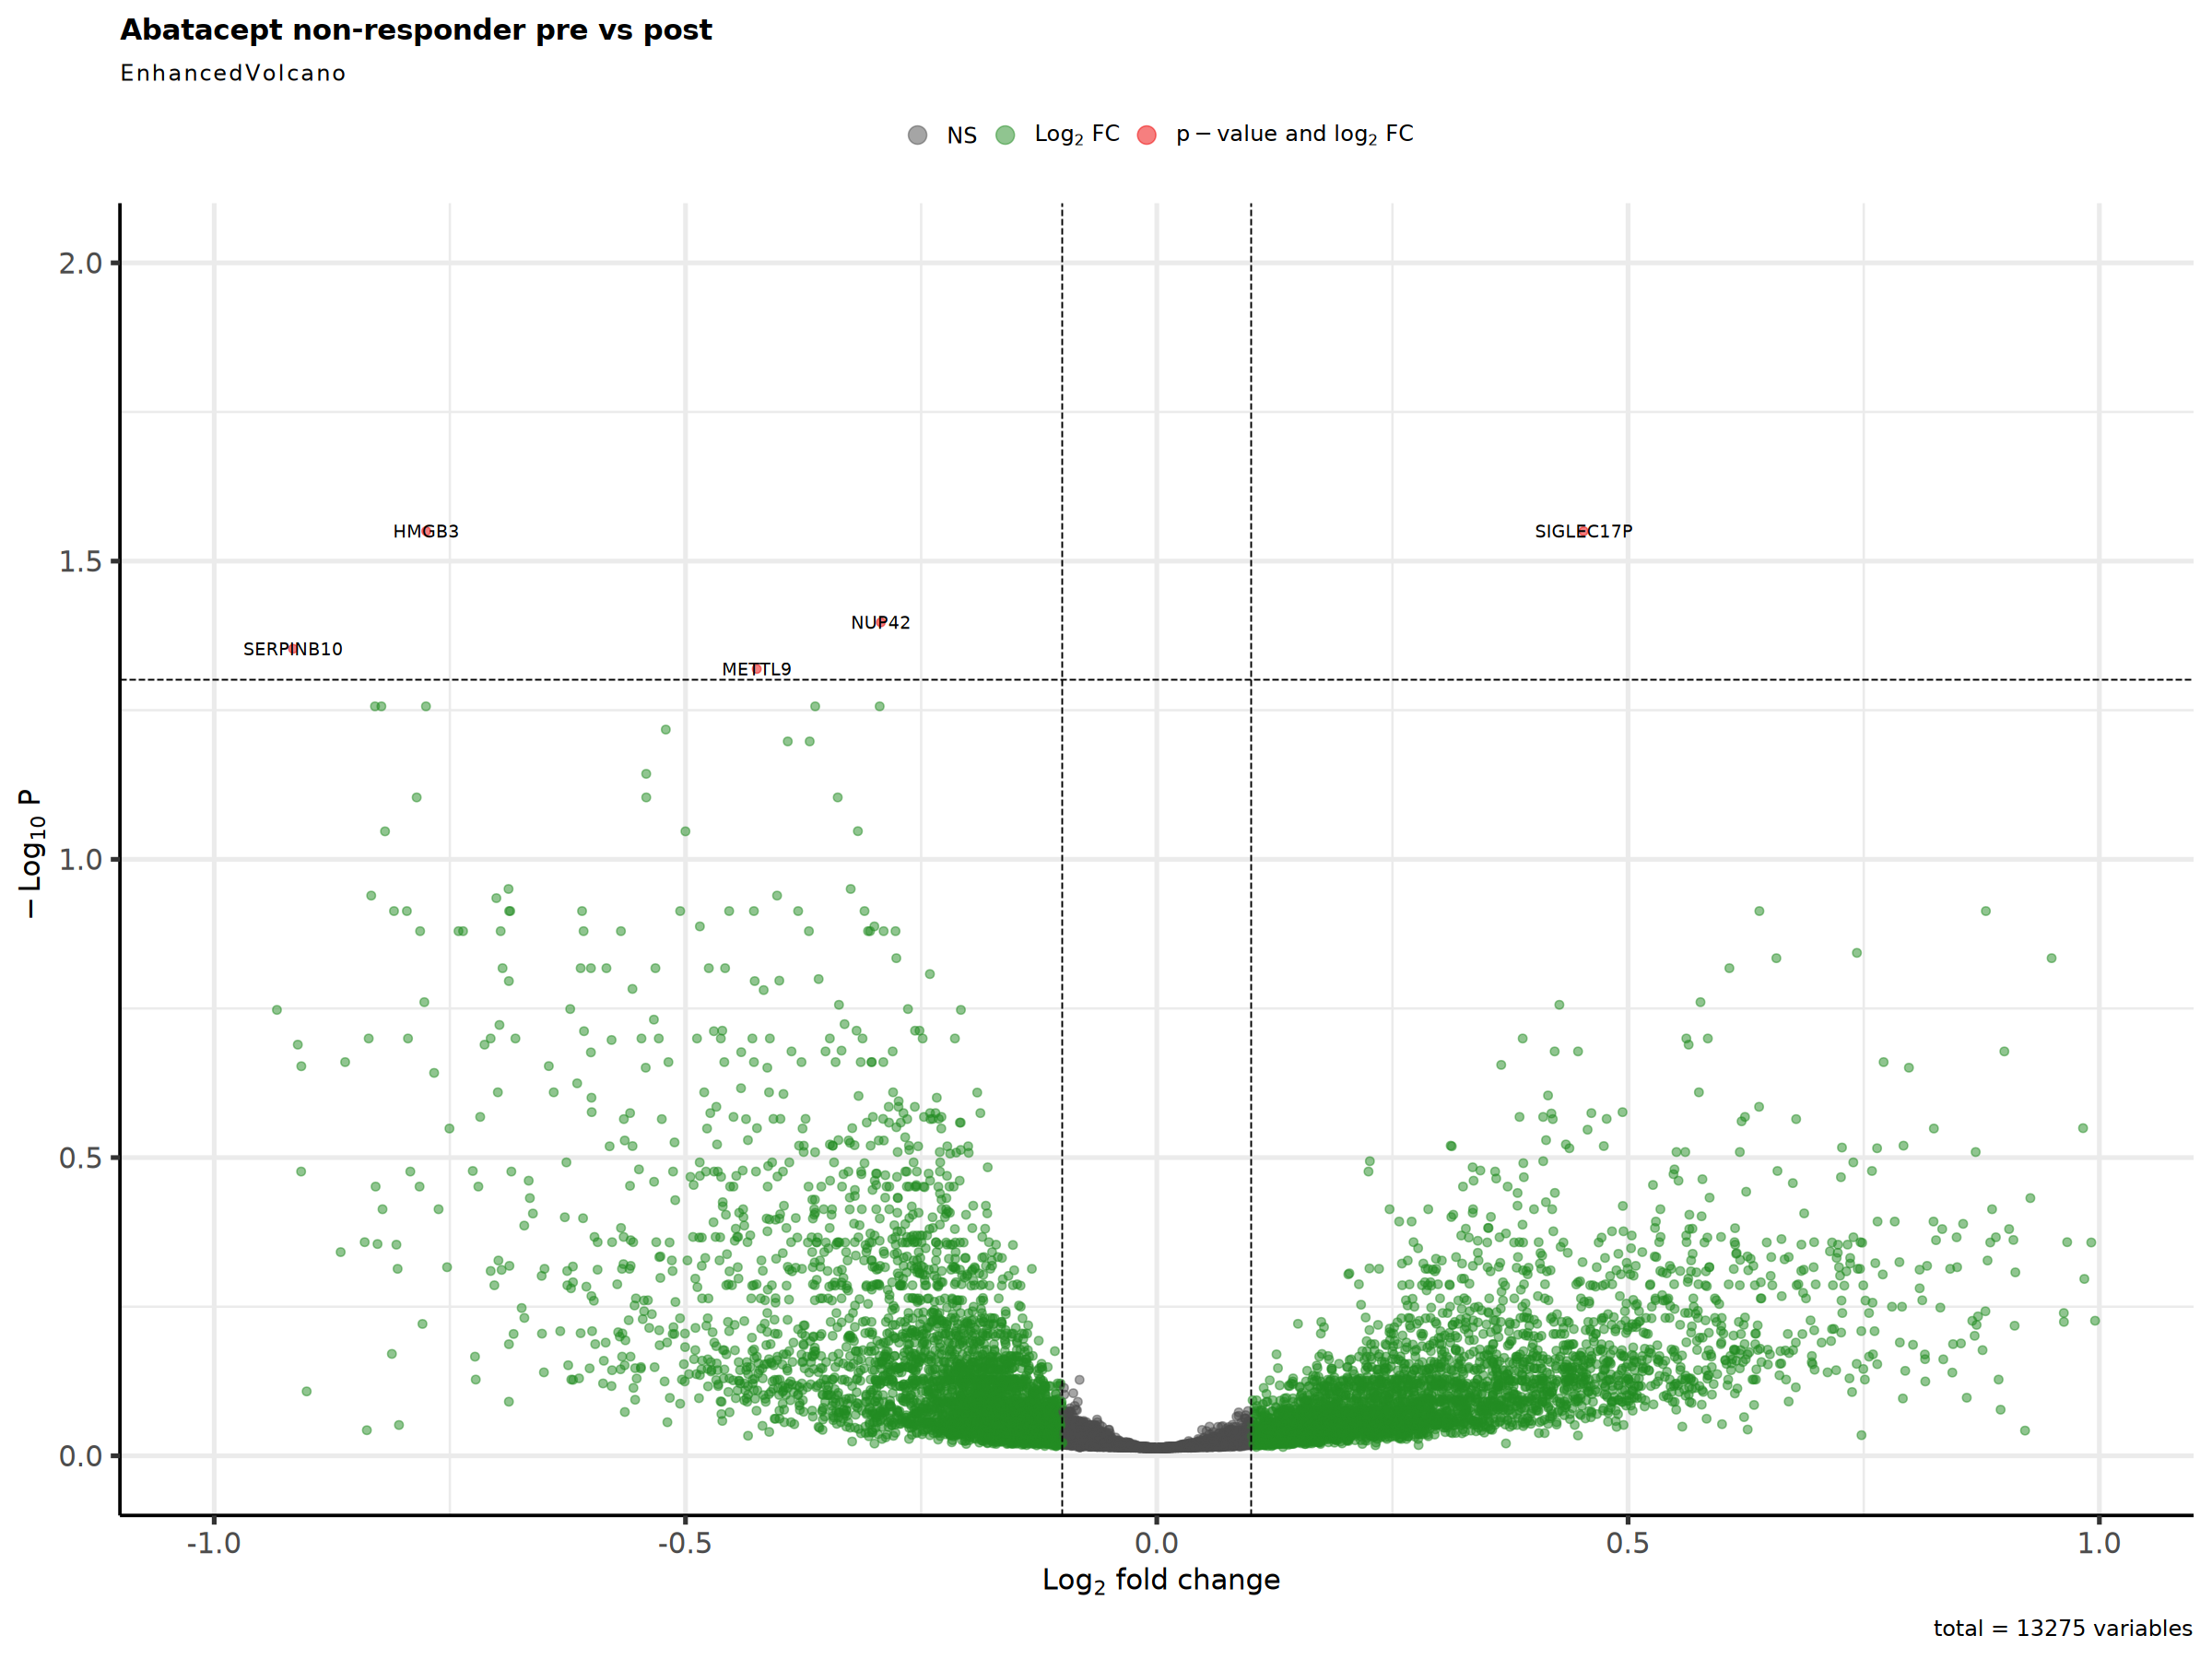

In [48]:
# Plot the DA results for aim1
p1<-EnhancedVolcano::EnhancedVolcano(dds_nonresp_res_tb,title = 'Abatacept non-responder pre vs post', 
    lab = dds_nonresp_res_tb$gene,
    x = 'log2FoldChange',
    y = 'q_values',
    pCutoff = 0.05,
    FCcutoff = 0.1,
    pointSize = 2.0, #drawConnectors = TRUE,
    widthConnectors = 1.0,
    colConnectors = 'black',
    arrowheads = FALSE,
    labSize = 4.0) + 
    xlim(c(-1, 1)) + ylim(0, 2)
p1
ggsave(file.path(fig_path, paste0(proj_name, 'Abatacept_nonresponders_prevspost_valcano_plot.png')),
       width=8, height=6)

### run a HyperGeometric Enrichment test

In [49]:
library(hypeR)

In [50]:
# # use abt response genes as the reference
# # check if the aim3 degs are significant enriched.
# celltype_test = 'Core_naive_CD4_T_cell'
# aim3_sig_genes <- aim3_degs %>%
#     filter(cell_type==celltype_test&q_values<0.1)%>%pull(gene)
# aim3_bg_genes <- aim3_degs %>%
#     filter(cell_type==celltype_test)%>%pull(gene)

# abt_sig_genes <- dds_nonresp_res_tb%>%filter(q_values<0.1)%>%pull(gene)


# hyp_obj <- hypeR(aim3_sig_genes, abt_genes_list, 
#                  test="hypergeometric", background=length(aim3_bg_genes), plotting=TRUE)
# hyp_obj

In [51]:
# make a degs list per cell type
celltypes_test = aim3_degs %>%
    filter(q_values<0.1)%>%group_by(cell_type) %>%
    tally()%>%filter(n>10)%>%pull(cell_type)%>%
    unique()
aim3_genes_list = lapply(celltypes_test, function(x){
    sig_genes <- aim3_degs %>%
        filter(cell_type==x&q_values<0.1)%>%pull(gene)
    return(sig_genes)
})
names(aim3_genes_list) = celltypes_test
celltypes_test

[1] "CM CD4 T cell"                    "CM CD8 T cell"                   
[3] "Core naive B cell"                "Core naive CD4 T cell"           
[5] "Core naive CD8 T cell"            "GZMK+ CD27+ EM CD8 T cell"       
[7] "KLRF1+ GZMB+ CD27- EM CD8 T cell" "KLRF1- GZMB+ CD27- EM CD8 T cell"
[9] "Naive CD4 Treg"

In [52]:
# aim3_genes_list
abtnon_sig_genes <- dds_nonresp_res_tb%>%filter(q_values<0.1)%>%pull(gene)
abtnon_bg_genes <- dds_nonresp_res_tb %>%pull(gene)

hyp_nonp <- hypeR(abtnon_sig_genes, aim3_genes_list, 
                 test="hypergeometric", background=length(abtnon_bg_genes), plotting=TRUE)


In [53]:
hyp_to_excel(hyp_nonp, file_path=file.path(output_path,"non_responders_pathways.xlsx"))

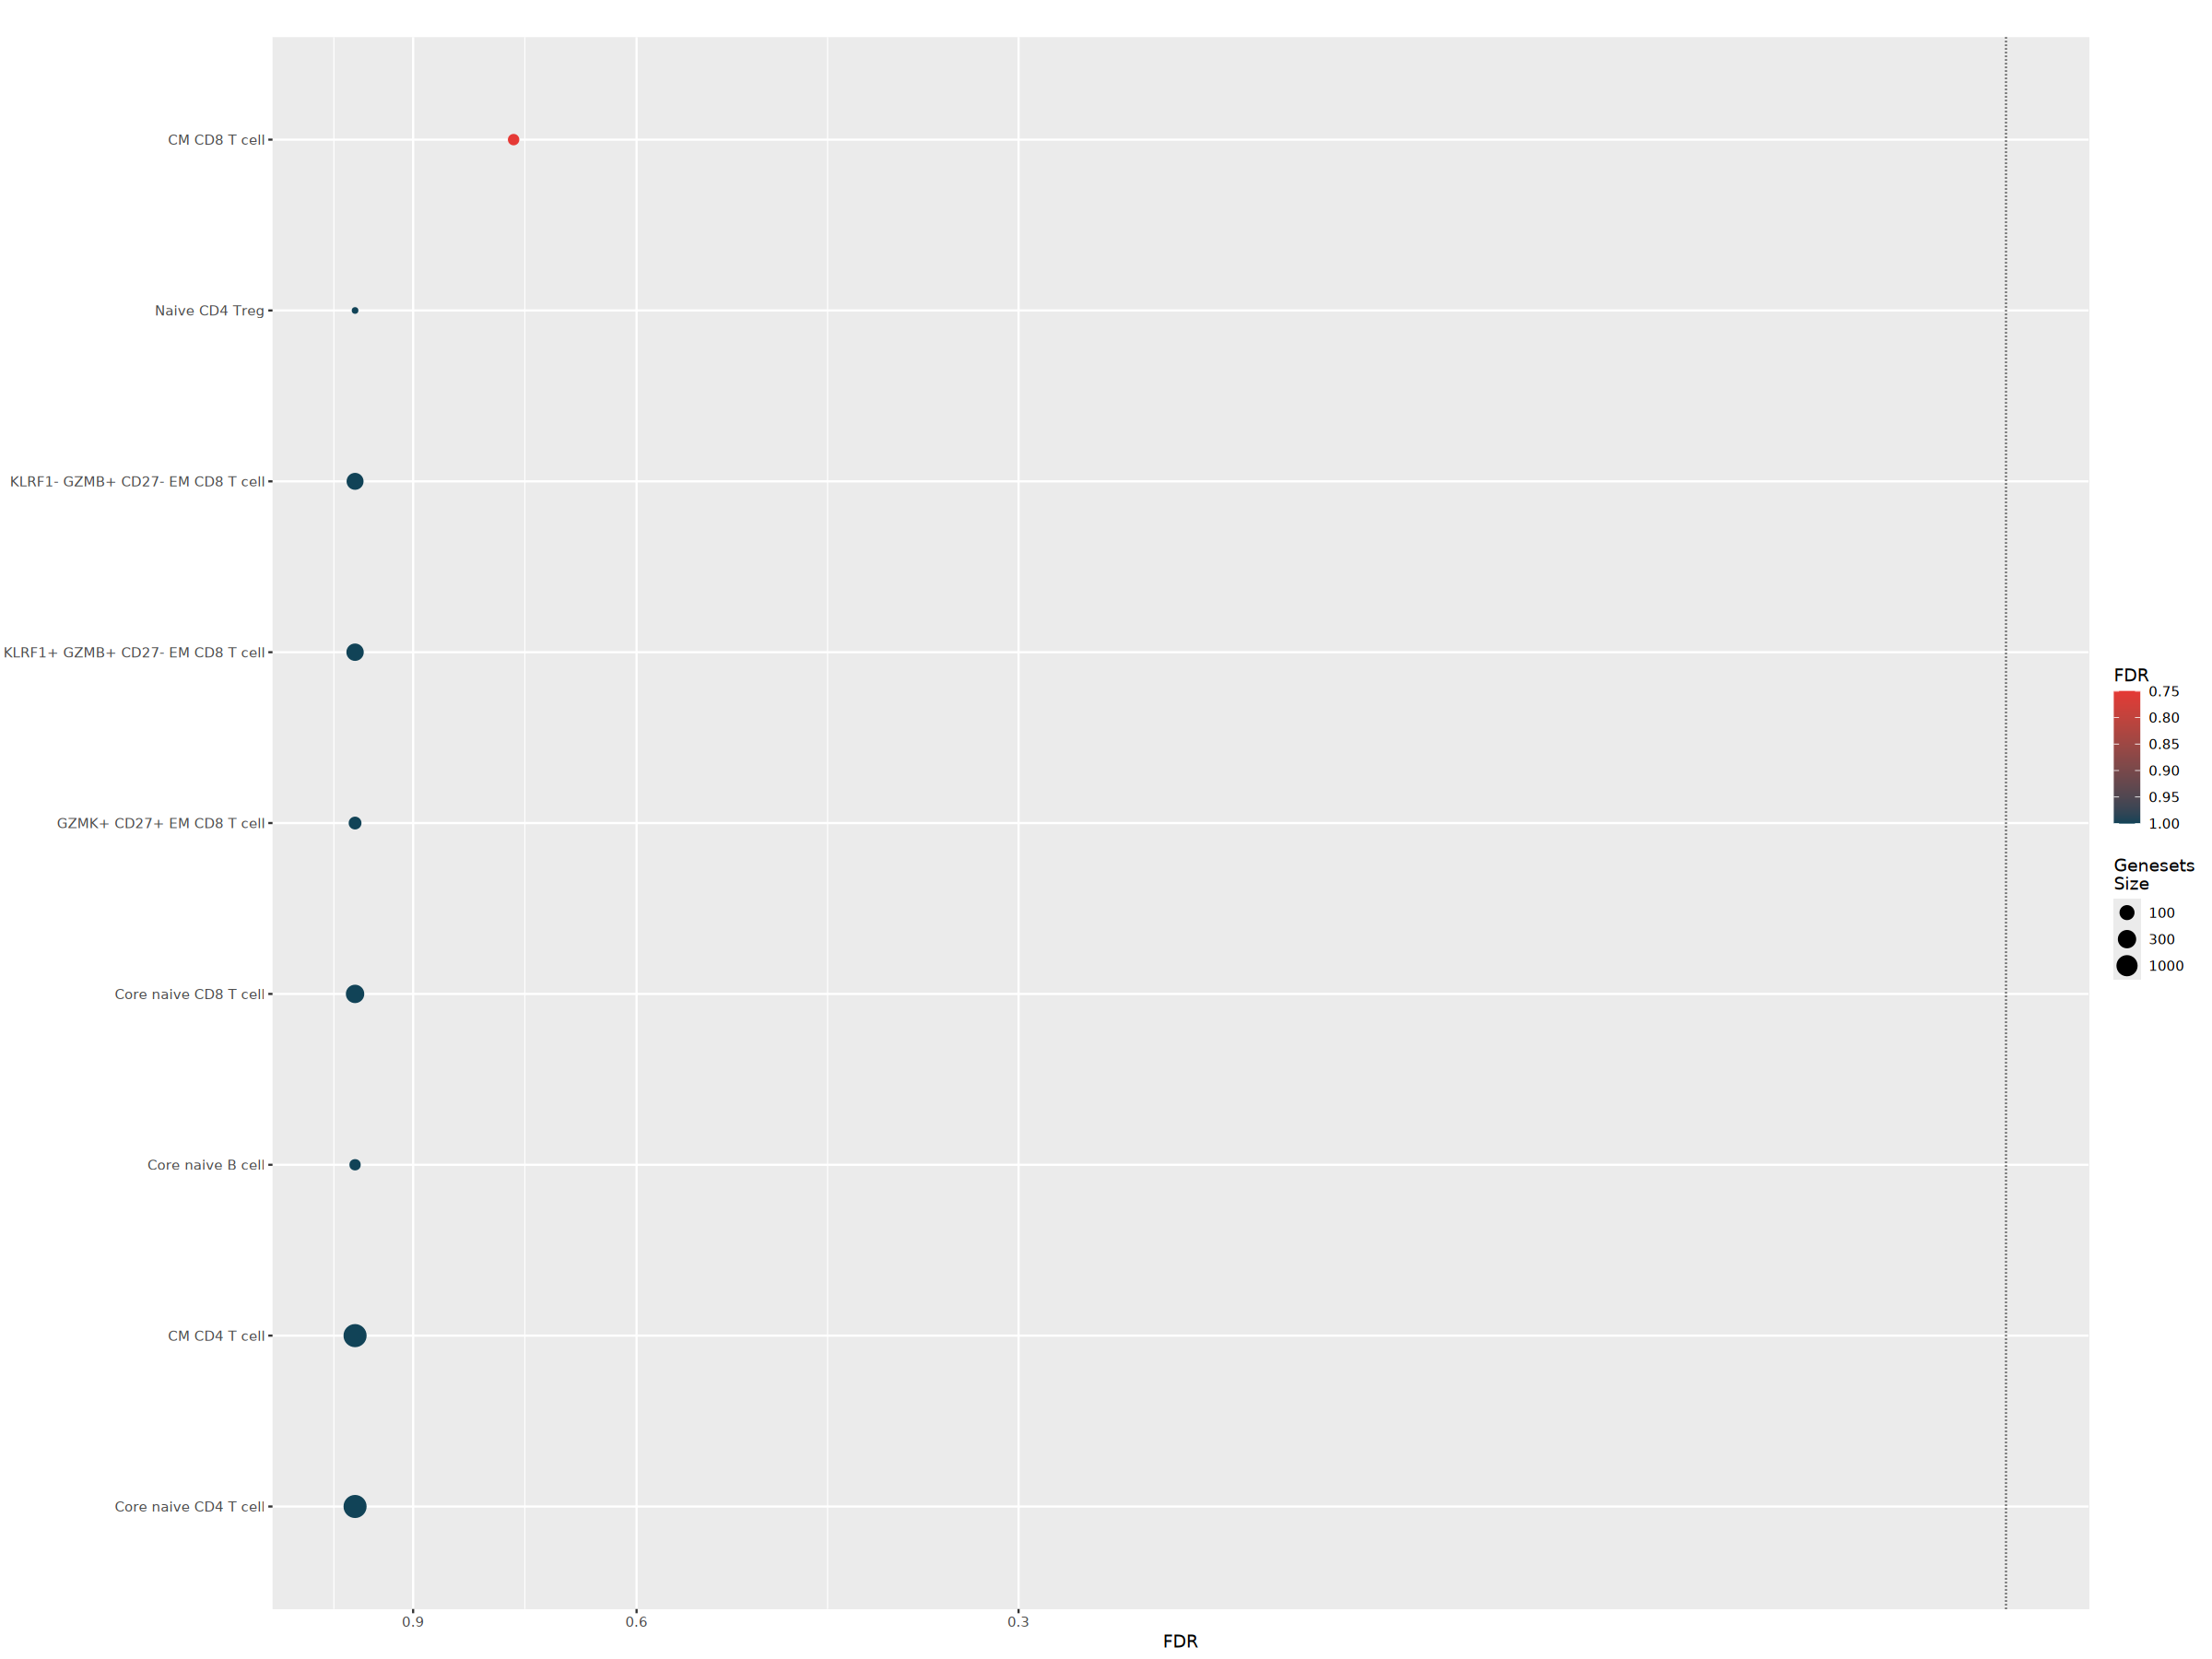

In [54]:
hyp_dots(hyp_nonp)
ggsave(file.path(fig_path, paste0(proj_name, 'gene_signature_abt_nonresponder.png')), width = 8, height = 4)

In [55]:
# combine the deg results
abtnon_aim3_degs_comparison <- dds_nonresp_res_tb %>% full_join(aim3_degs, by=c('gene'),
                                          suffix = c('_abt', '_aim3'))%>%
    dplyr::rename('pvalue_aim3'='p.value')%>%
   filter(q_values_aim3<0.1 & q_values_abt<0.1&
          !is.na(log2FoldChange))%>% 
    mutate(sig = case_when(q_values_abt<=0.05&q_values_aim3<=0.1 ~ 'AbtSig&Aim3Sig', 
                    q_values_abt>0.05&q_values_aim3<=0.1 ~ 'Aim3Sig', 
                    q_values_abt<=0.05&q_values_aim3>0.1 ~ 'AbtSig', 
                    q_values_abt>0.05&q_values_aim3>0.1~ 'No sig'))%>% 
    mutate(aim3_direction = if_else(estimate>0, 'aim3_up', 'aim3_down'),
          abt_direction = if_else(log2FoldChange>0, 'abt_up', 'abt_down'))
abtnon_aim3_degs_comparison%>%colnames()

[1] "gene"           "baseMean"       "log2FoldChange" "lfcSE"         
 [5] "stat"           "pvalue"         "q_values_abt"   "cell_type"     
 [9] "effect"         "group"          "term"           "estimate"      
[13] "std.error"      "statistic"      "df"             "pvalue_aim3"   
[17] "q_values_aim3"  "sig"            "aim3_direction" "abt_direction"

In [56]:
abtnon_aim3_degs_comparison%>%filter(is.na(sig))

gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values_abt,cell_type,effect,group,term,estimate,std.error,statistic,df,pvalue_aim3,q_values_aim3,sig,aim3_direction,abt_direction
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>


In [57]:
# calculate the numbers
abtnon_aim3_degs_comparison_counts <- abtnon_aim3_degs_comparison %>% 
    group_by(cell_type, aim3_direction, abt_direction)%>% tally()%>%
    ungroup()
abtnon_aim3_degs_comparison_counts

cell_type,aim3_direction,abt_direction,n
<chr>,<chr>,<chr>,<int>
CM CD4 T cell,aim3_down,abt_down,5
CM CD8 T cell,aim3_down,abt_down,1
Core naive CD4 T cell,aim3_down,abt_down,5


In [58]:
# # run mcnemar test

# celltypes_test = abtnon_aim3_degs_comparison_counts%>%
#     group_by(cell_type)%>%tally()%>%filter(n>=4)%>%pull(cell_type)
# celltypes_test

# mcnemar_res <- abtnon_aim3_degs_comparison_counts %>%filter(cell_type%in%celltypes_test)%>%group_by(cell_type)%>% 
#     group_modify(~run_mcnemar_test(.x))
# # cont_counts = abt_aim3_degs_comparison_counts%>%filter(cell_type=='Core_naive_CD4_T_cell')%>%
# #     pivot_wider(id_cols = aim3_direction, names_from = abt_direction , values_from = n)
# # sex_counts = aim1_filedesc_fl%>%group_by(status, subject.biologicalSex)%>%tally()%>%
# #     pivot_wider(id_cols = subject.biologicalSex, names_from = status , values_from = n)
# # sex_counts 
# mcnemar_res

In [59]:
abtnon_aim3_degs_comparison_counts%>%
    filter(cell_type%in%c('CM CD4 T cell'))%>%
            pivot_wider(id_cols = c(cell_type, aim3_direction), 
                        names_from = abt_direction , values_from = n)

cell_type,aim3_direction,abt_down
<chr>,<chr>,<int>
CM CD4 T cell,aim3_down,5


In [60]:
abtnon_aim3_degs_comparison_counts%>%head()

cell_type,aim3_direction,abt_direction,n
<chr>,<chr>,<chr>,<int>
CM CD4 T cell,aim3_down,abt_down,5
CM CD8 T cell,aim3_down,abt_down,1
Core naive CD4 T cell,aim3_down,abt_down,5


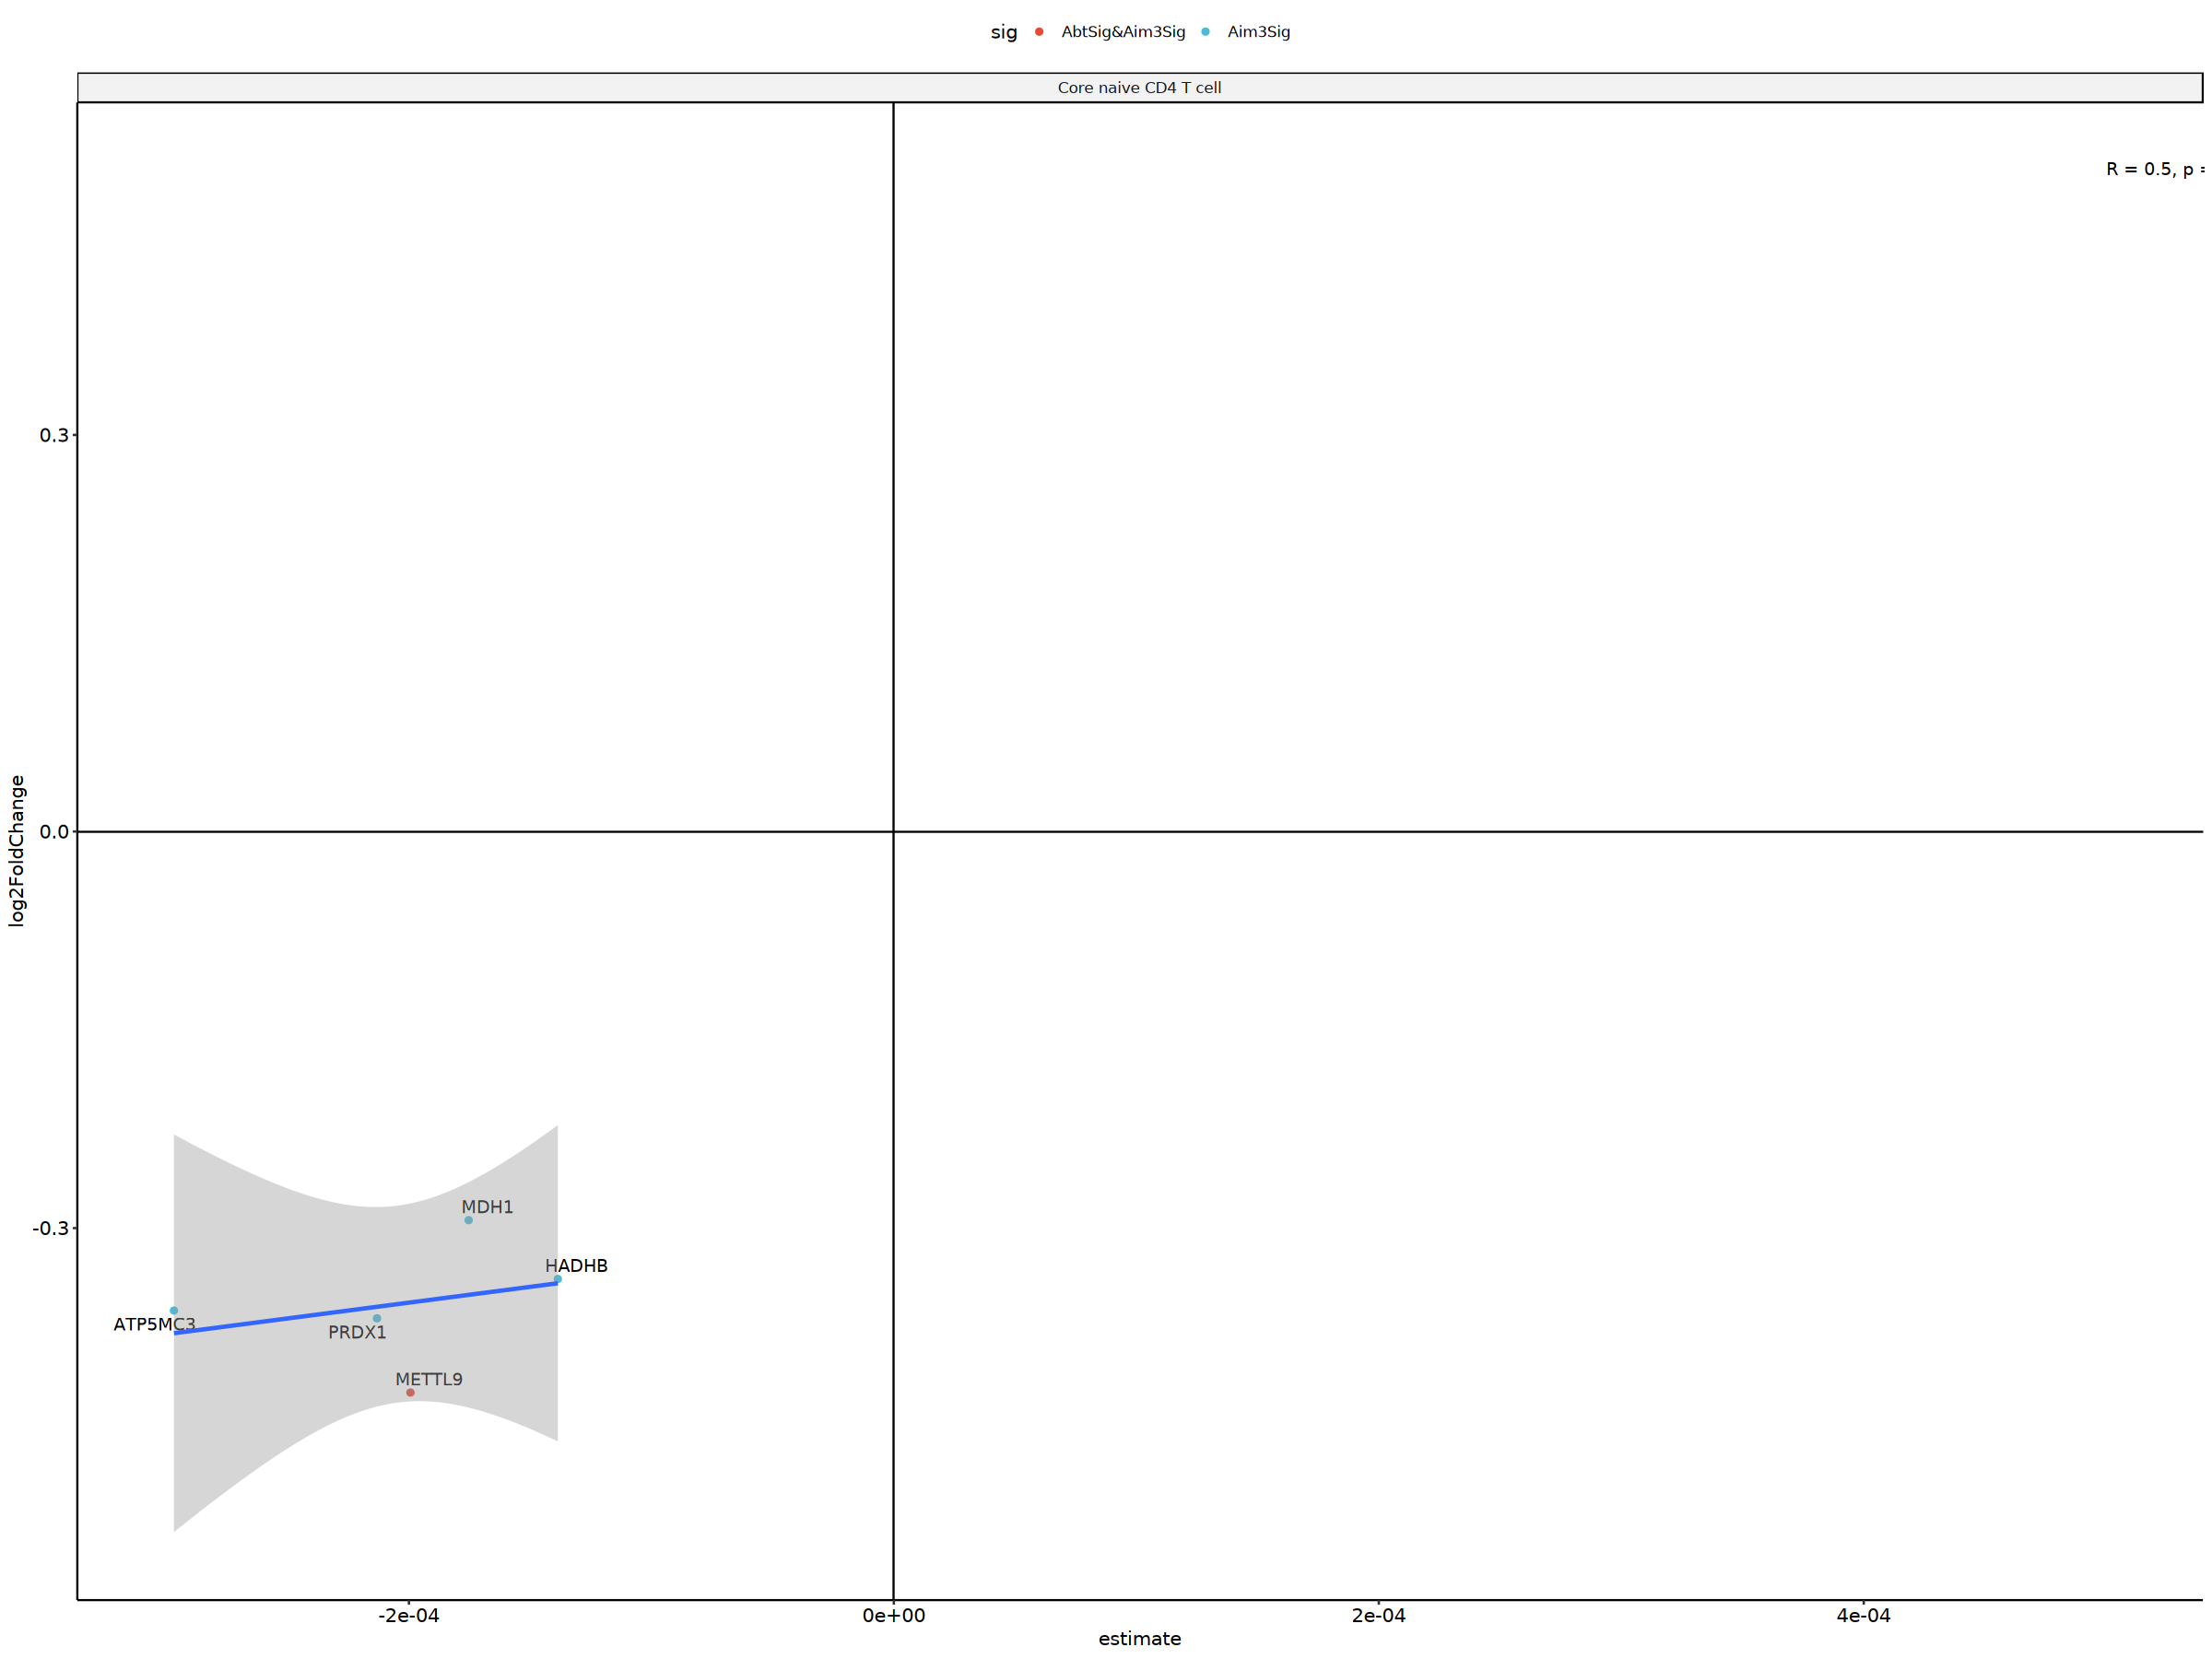

In [61]:
# plot the significant genes
abtnon_aim3_degs_comparison %>%
    filter(cell_type%in%c('Core naive CD4 T cell'))%>%
    ggplot(aes(y=log2FoldChange, x=estimate
                          )) +
    geom_point(aes(color=sig)) +
    ggrepel::geom_text_repel(aes(label=gene), 
                            ) +
    stat_smooth(method = "lm", 
              formula = y ~ x, 
              geom = "smooth") + 
    geom_vline(xintercept = 0)+ geom_hline(yintercept = 0)+ 
    ggpubr::stat_cor(method = "spearman", label.x = 0.0005, label.y = 0.5)+
    facet_wrap(vars(cell_type)) + scale_color_manual(values = npg_color) + theme_pubr()
ggsave(file.path(fig_path, paste0(proj_name,'abecetpt_nonresponder_Aim3_deg_cd4nat_logfc_cor_plot.png')),
       width=6, height=6)

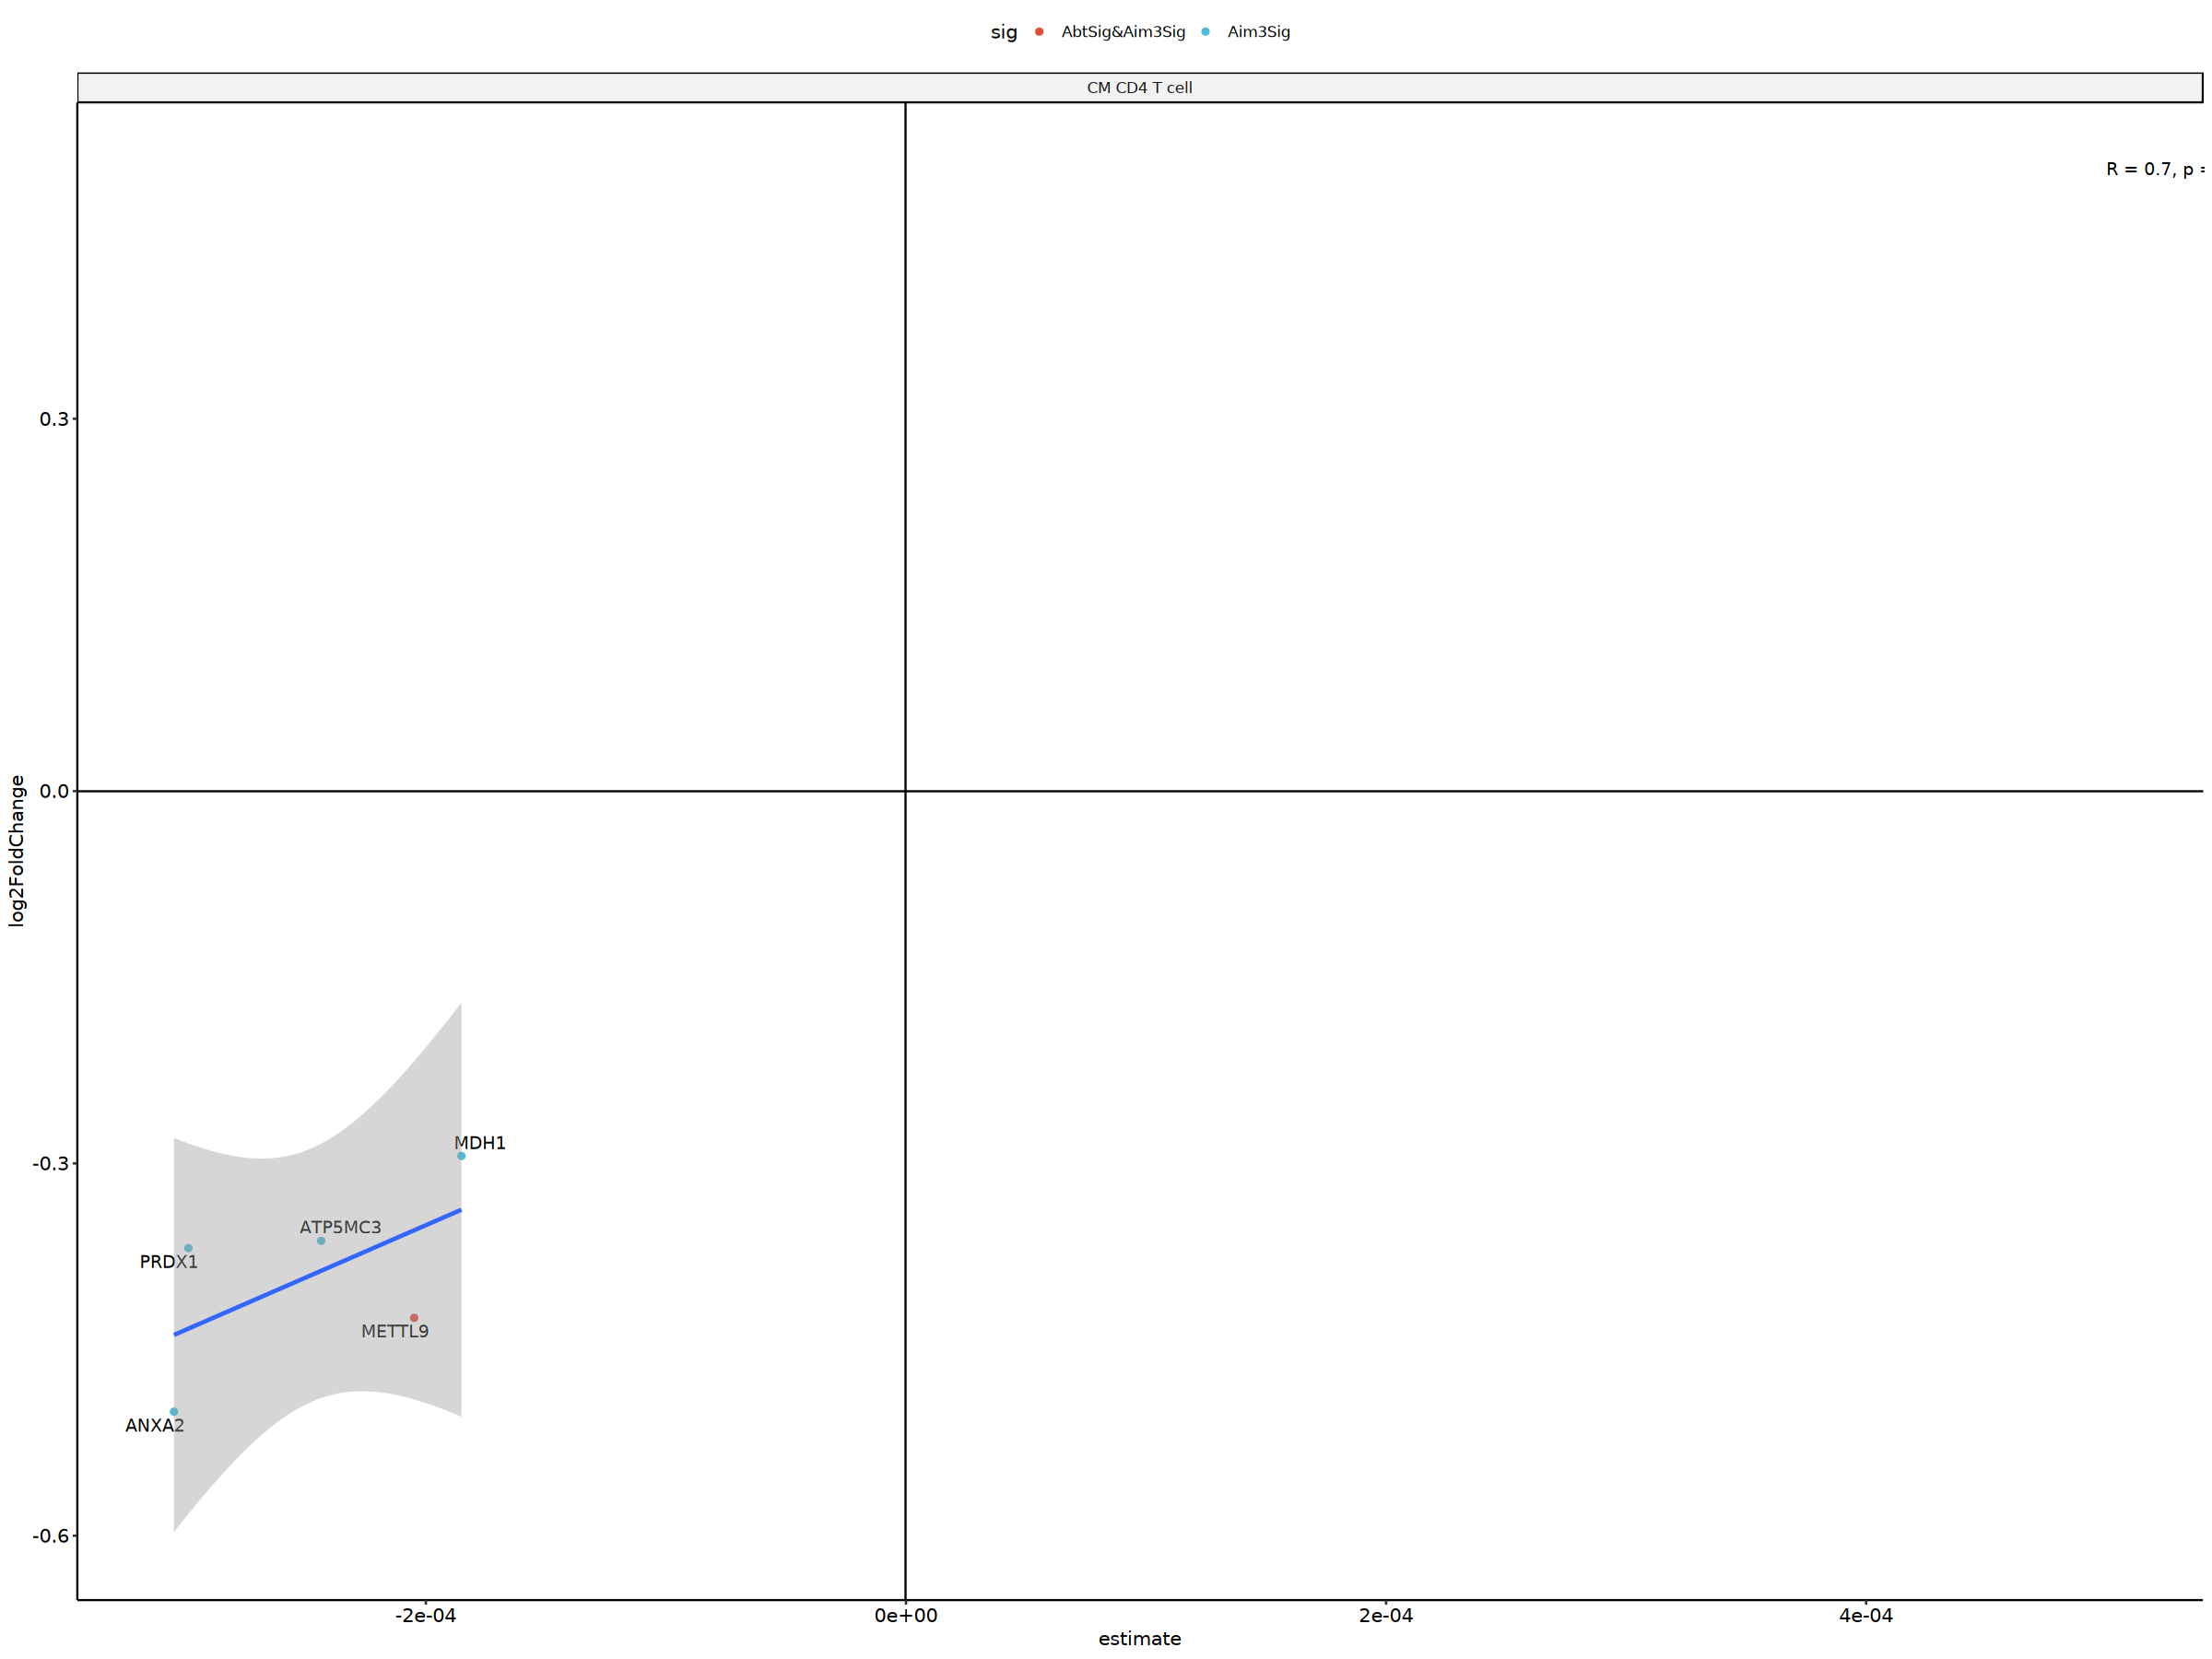

In [62]:
# plot the significant genes
abtnon_aim3_degs_comparison %>%
    filter(cell_type%in%c('CM CD4 T cell'))%>%
    ggplot(aes(y=log2FoldChange, x=estimate
                          )) +
    geom_point(aes(color=sig)) +
    ggrepel::geom_text_repel(aes(label=gene), 
                            ) +
    stat_smooth(method = "lm", 
              formula = y ~ x, 
              geom = "smooth") + 
    geom_vline(xintercept = 0)+ geom_hline(yintercept = 0)+ 
    ggpubr::stat_cor(method = "spearman", label.x = 0.0005, label.y = 0.5)+
    facet_wrap(vars(cell_type)) + scale_color_manual(values = npg_color) + theme_pubr()
ggsave(file.path(fig_path, paste0(proj_name,'abecetpt_nonresponder_Aim3_deg_cd4CM_logfc_cor_plot.png')),
       width=6, height=6)

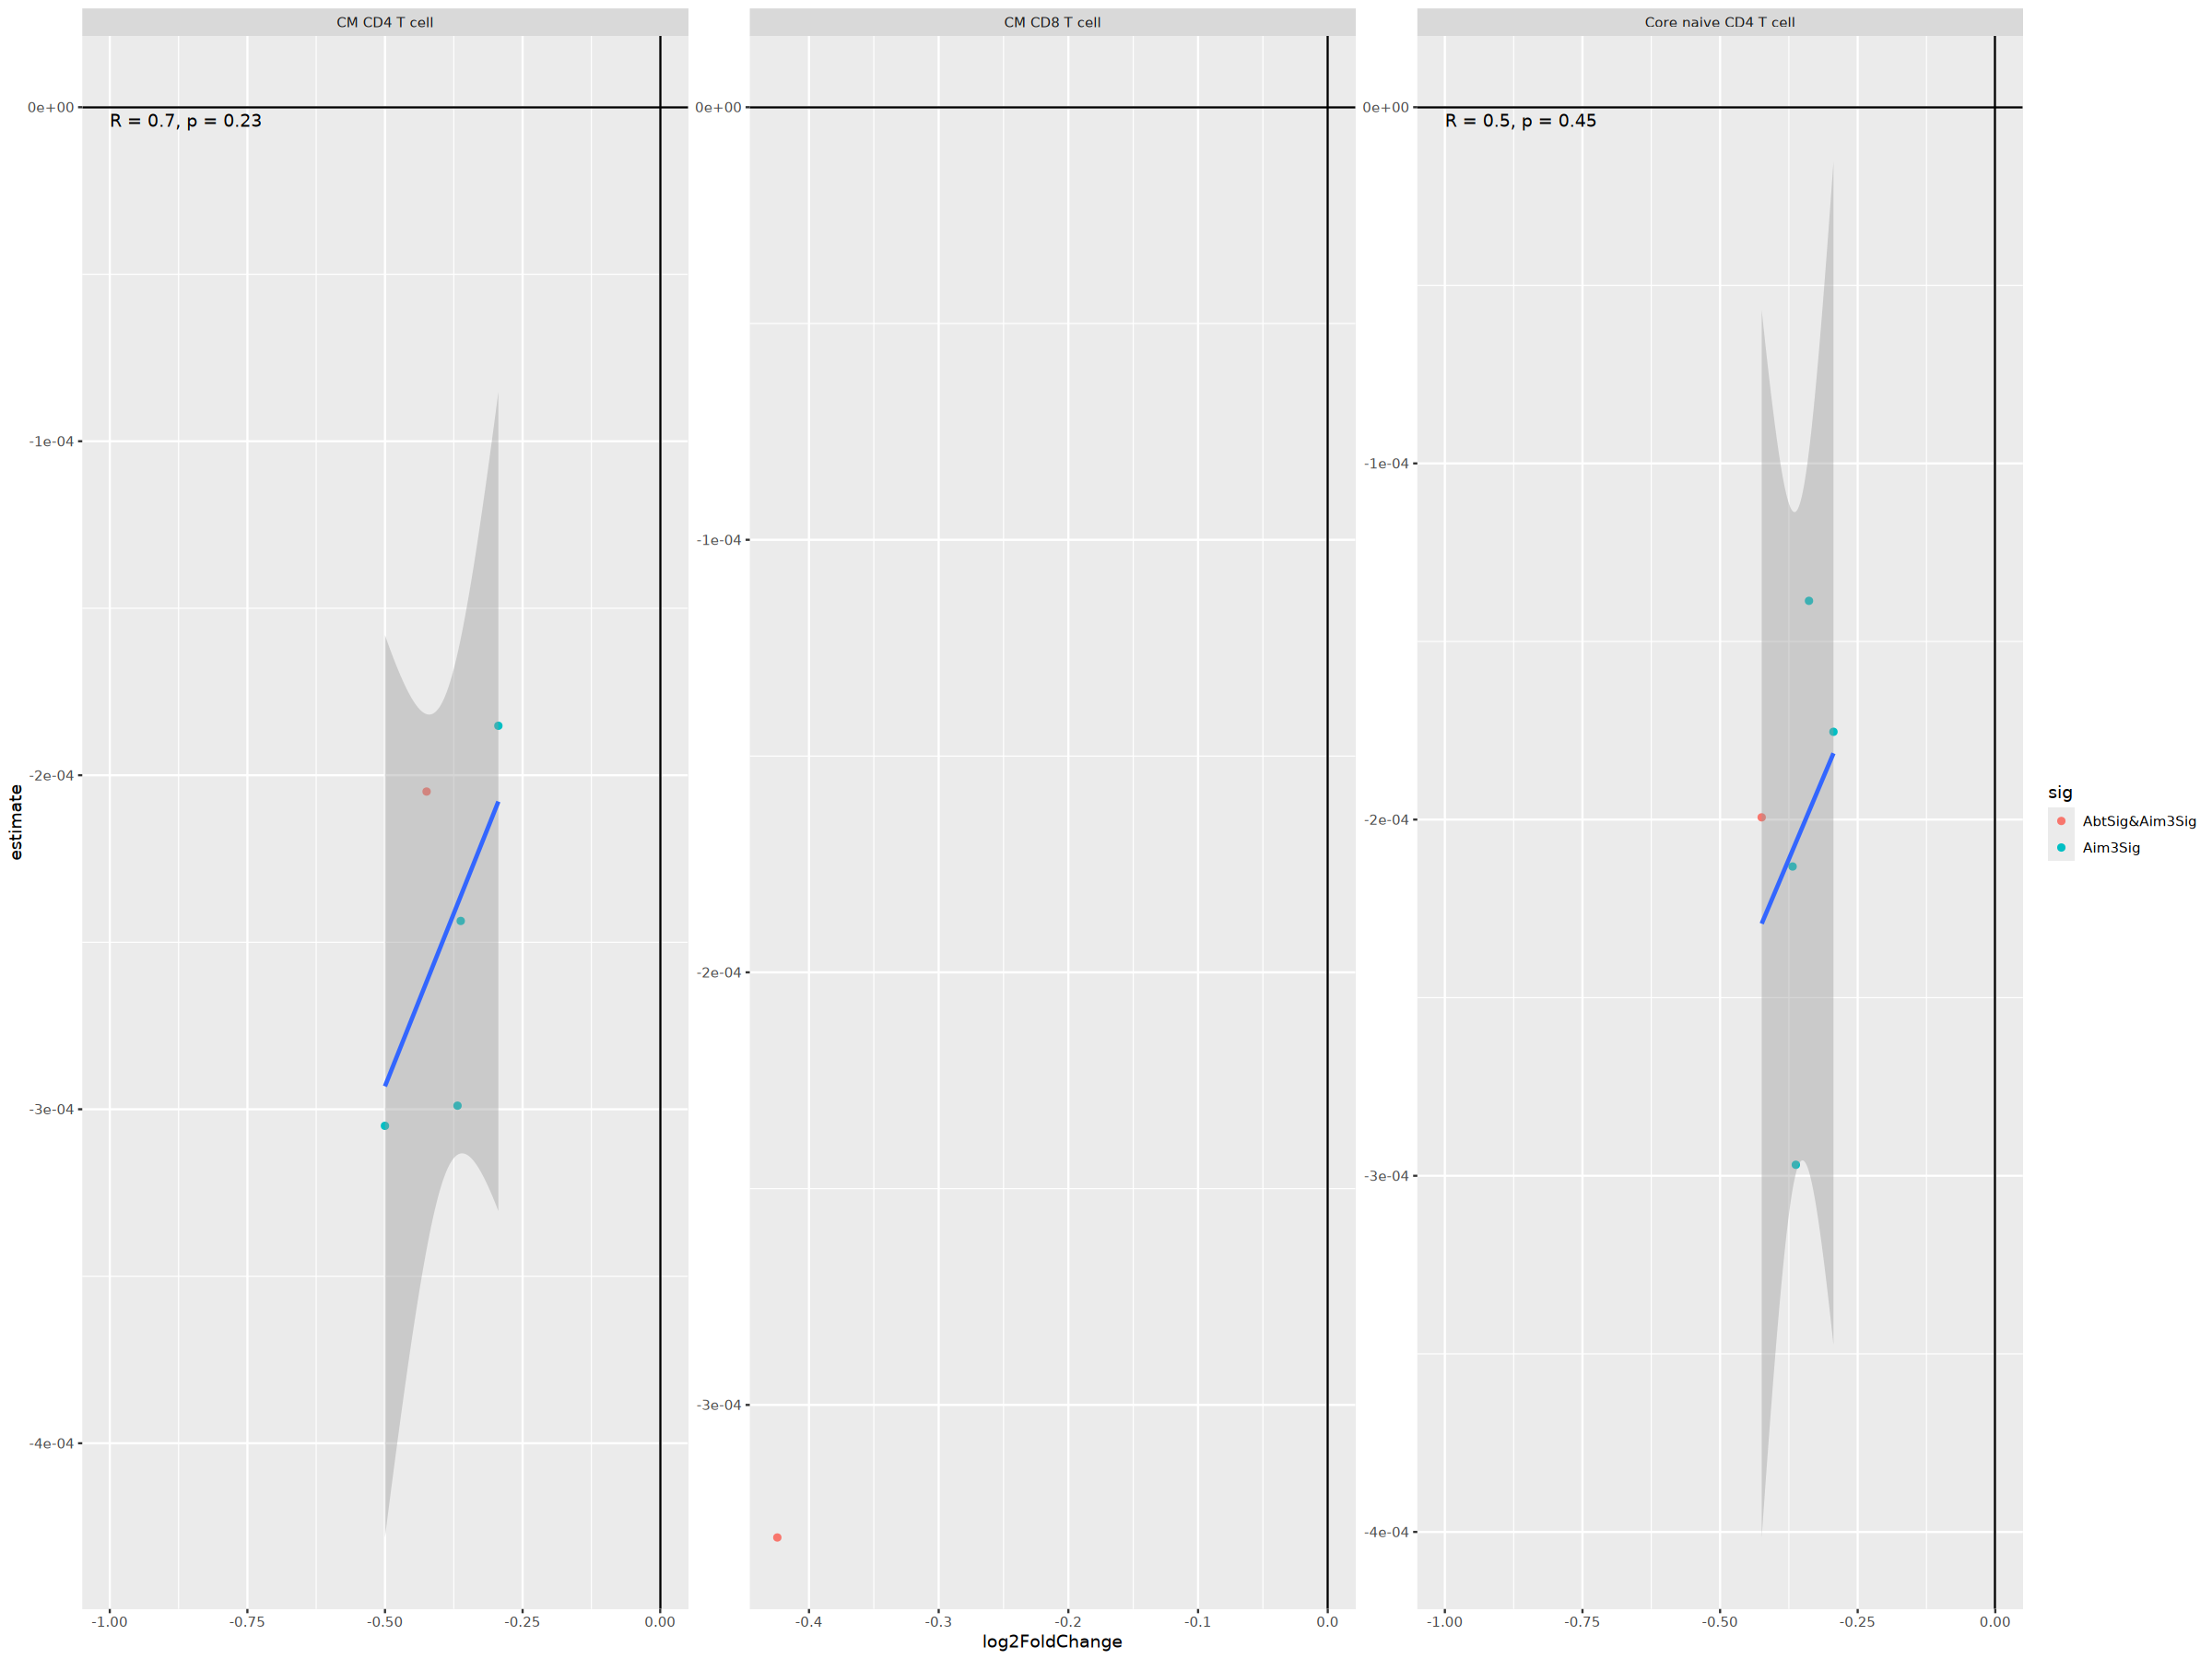

In [63]:
# plot aim1 and aim3 corrlation 
p1<- abtnon_aim3_degs_comparison%>%
    ggplot(aes(x=log2FoldChange, y=estimate
                          )) +
    geom_point(aes(color=sig)) +                                      
  stat_smooth(method = "lm", 
              formula = y ~ x, 
              geom = "smooth") + 
    geom_vline(xintercept = 0)+ geom_hline(yintercept = 0)+
    facet_wrap(vars(cell_type), scale='free')+ 
    ggpubr::stat_cor(method = "spearman", label.x = -1)
p1
ggsave(file.path(fig_path, paste0('abecetpt_non_responder_Aim3_deg_logfc_cor_plot.png')),
       width=18, height=12)

In [64]:
# abt_non_cor <- abtnon_aim3_degs_comparison %>% filter(!is.na(log2FoldChange) & !is.na(estimate))%>% 
#   group_by(cell_type) %>% 
#   rstatix::cor_test(log2FoldChange, estimate, method =  "spearman", 
#                     conf.level=TRUE)

In [65]:
# p2 <- ggplot(abt_non_cor, aes(x=cell_type, y=cor)) +
#   geom_segment( aes(x=cell_type, xend=cell_type, y=0, yend=cor), color="grey") +
#   geom_point( size=2) + ylim(-0.1, 0.3)+
#   geom_hline(yintercept = 0 ,linetype=2)+
#  # geom_errorbar( aes( ymin=cor-sd, ymax=value+sd), width=0.4, colour="orange", alpha=0.9, size=1.3)+
#   theme_light() +  coord_flip()+
#   theme(
#     panel.grid.major.x = element_blank(),
#     panel.border = element_blank(),
#     axis.ticks.x = element_blank(),
#     #  axis.ticks.y = element_blank(),
#     #legend.position="none"
#   ) + scale_color_manual(values = npg_color)+
#   xlab("") +
#   ylab("spearman correlation coefficient") +
#   ggtitle('Non-responder')
# p2

In [66]:
# abt_non_cor%>%head()

In [67]:
# p1 <- ggplot(abt_cor, aes(x=cell_type, y=cor)) +
#   geom_segment( aes(x=cell_type, xend=cell_type, y=0, yend=cor), color="grey") +
#   geom_point( size=2) + #ylim(-0.5, 1)+
#   geom_hline(yintercept = 0 ,linetype=2)+
#  # geom_errorbar( aes( ymin=cor-sd, ymax=value+sd), width=0.4, colour="orange", alpha=0.9, size=1.3)+
#   theme_light() +  coord_flip()+
#   theme(
#     panel.grid.major.x = element_blank(),
#     panel.border = element_blank(),
#     axis.ticks.x = element_blank(),
#     #legend.position="none"
#   ) + scale_color_manual(values = npg_color)+
#   xlab("") +
#   ylab("spearman correlation coefficient") +
#     ggtitle('responder', )
# p2 <- ggplot(abt_non_cor, aes(x=cell_type, y=cor)) +
#   geom_segment( aes(x=cell_type, xend=cell_type, y=0, yend=cor), color="grey") +
#   geom_point( size=2) + ylim(-0.1, 0.3)+
#   geom_hline(yintercept = 0 ,linetype=2)+
#  # geom_errorbar( aes( ymin=cor-sd, ymax=value+sd), width=0.4, colour="orange", alpha=0.9, size=1.3)+
#   theme_light() +  coord_flip()+
#   theme(
#     panel.grid.major.x = element_blank(),
#     panel.border = element_blank(),
#     axis.ticks.x = element_blank(),
#     #  axis.ticks.y = element_blank(),
#     #legend.position="none"
#   ) + scale_color_manual(values = npg_color)+
#   xlab("") +
#   ylab("spearman correlation coefficient") +
#   ggtitle('Non-responder')
# cowplot::plot_grid(p1+ylim(-0.4, 0.1), p2+ylim(-0.1, 0.4))
# ggsave(file.path(fig_path, paste0('abecetpt__Aim3_deg_logfc_cor_coeffcient.png')),
#        width=12, height=8)

# plot the gene set enrichment results for responders and non-responders

In [68]:
# combine the HyperGeometric test result
resp_data = hyp_obj$data%>%as_tibble(rownames = 'cell_type')%>%
    mutate(response='Responder')
nonp_data = hyp_nonp$data%>%as_tibble(rownames = 'cell_type')%>%
    mutate(response='Non-responder')
hyp_results = resp_data%>%bind_rows(nonp_data)%>%
    mutate(cell_type=factor(cell_type, levels = rev(unique(cell_type))), 
          'log10_FDR' = -log10(fdr), 
          cell_type_anno=recode(cell_type, 'Core naive CD4 T cell' = 'Naive CD4 T', 
                               'CM CD4 T cell' = 'CM CD4 T', 
                               'Core naive CD8 T cell' = 'Naive CD8 T',
                                'KLRF1+ GZMB+ CD27- EM CD8 T cell' = 'KLRF1+ CD8 EM', 
                                'Core naive B cell' = 'Core naive B', 
                                'KLRF1- GZMB+ CD27- EM CD8 T cell' = 'KLRF1- CD8 EM', 
                                'GZMK+ CD27+ EM CD8 T cell' = 'GZMK+ CD8 EM'
                                ))
hyp_results%>%select(-hits)

cell_type,label,pval,fdr,signature,geneset,overlap,background,response,log10_FDR,cell_type_anno
<fct>,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<fct>
Core naive CD4 T cell,Core naive CD4 T cell,3.3e-05,0.0003,965,2651,237,13608,Responder,3.522878745,Naive CD4 T
CM CD4 T cell,CM CD4 T cell,5.0e-04,0.0022,965,2712,233,13608,Responder,2.657577319,CM CD4 T
Core naive CD8 T cell,Core naive CD8 T cell,2.5e-01,0.7400,965,305,25,13608,Responder,0.130768280,Naive CD8 T
Naive CD4 Treg,Naive CD4 Treg,4.0e-01,0.7400,965,32,3,13608,Responder,0.130768280,Naive CD4 Treg
KLRF1+ GZMB+ CD27- EM CD8 T cell,KLRF1+ GZMB+ CD27- EM CD8 T cell,4.1e-01,0.7400,965,209,16,13608,Responder,0.130768280,KLRF1+ CD8 EM
Core naive B cell,Core naive B cell,6.3e-01,0.9400,965,45,3,13608,Responder,0.026872146,Core naive B
KLRF1- GZMB+ CD27- EM CD8 T cell,KLRF1- GZMB+ CD27- EM CD8 T cell,7.4e-01,0.9600,965,181,11,13608,Responder,0.017728767,KLRF1- CD8 EM
CM CD8 T cell,CM CD8 T cell,9.7e-01,0.9900,965,46,1,13608,Responder,0.004364805,CM CD8 T cell
GZMK+ CD27+ EM CD8 T cell,GZMK+ CD27+ EM CD8 T cell,9.9e-01,0.9900,965,59,1,13608,Responder,0.004364805,GZMK+ CD8 EM


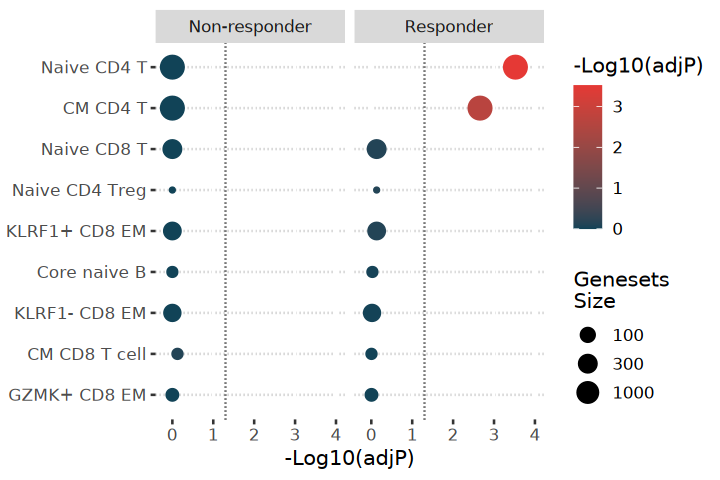

In [69]:
# plot the pathway enrichment results
options(repr.plot.width = 6, repr.plot.height = 4)
p1 <- ggplot(hyp_results, aes(x=log10_FDR, size = geneset,
                        y=cell_type_anno, 
                        color=log10_FDR)) + geom_point() +
    facet_wrap(vars(response)) +
    scale_color_continuous(low="#114357", high="#E53935")+
    geom_vline(xintercept= -log10(0.05), linetype="dotted") +
    ggpubr::theme_pubclean()+ xlim(c(-0.2, 4))+
    theme(axis.text.y = element_text(size=10),
          axis.title.y=element_blank(), legend.position="right")+ 
    scale_size_continuous(trans=scales::log10_trans()) + 
    labs(size="Genesets\nSize", x ='-Log10(adjP)', color ='-Log10(adjP)') 
p1
ggsave(file.path(fig_path, paste0('Fig6_abt_geneset_enrichment.pdf')),
       width=6, height=4)

In [70]:
abt_aim3_degs_comparison%>%colnames()

[1] "gene"           "baseMean"       "log2FoldChange" "lfcSE"         
 [5] "stat"           "pvalue"         "q_values_abt"   "cell_type"     
 [9] "effect"         "group"          "term"           "estimate"      
[13] "std.error"      "statistic"      "df"             "pvalue_aim3"   
[17] "q_values_aim3"  "sig"            "aim3_direction" "abt_direction"

In [71]:
# filter the significant gene only genes
abt_aim3_degs_comparison_sig <- abt_aim3_degs_comparison %>% 
    filter(q_values_abt<0.1&q_values_aim3<0.1)%>%
    mutate(direction=
           case_when(aim3_direction == 'aim3_up' & abt_direction=='abt_up' ~ 
                     'Increased during progression to RA&\nIncreased post ABT', 
                    aim3_direction == 'aim3_down' & abt_direction=='abt_down' ~ 
                     'Decreased during progression to RA&\nDecreased post ABT', 
                     aim3_direction == 'aim3_down' & abt_direction=='abt_up' ~ 
                     'Decreased during progression to RA&\nIncreased post ABT', 
                     aim3_direction == 'aim3_up' & abt_direction=='abt_down' ~ 
                     'Increased during progression to RA&\nDecreased post ABT'))
abt_aim3_degs_comparison_sig%>%head()

gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values_abt,cell_type,effect,group,⋯,estimate,std.error,statistic,df,pvalue_aim3,q_values_aim3,sig,aim3_direction,abt_direction,direction
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
CD99,3134.7115,0.4866086,0.1771889,2.746271,0.0060277009,0.075772893,CM CD4 T cell,fixed,NA,⋯,-0.0002296694,0.0001173063,-1.957861,40.31672,0.05719209,0.06575596,AbtSig&Aim3Sig,aim3_down,abt_up,Decreased during progression to RA& Increased post ABT
CD99,3134.7115,0.4866086,0.1771889,2.746271,0.0060277009,0.075772893,Core naive CD4 T cell,fixed,NA,⋯,-0.0001990364,0.0001113067,-1.788180,37.32523,0.08186729,0.07004380,AbtSig&Aim3Sig,aim3_down,abt_up,Decreased during progression to RA& Increased post ABT
MAD1L1,153.0922,0.8508763,0.2211721,3.847123,0.0001195129,0.005544172,CM CD4 T cell,fixed,NA,⋯,-0.0002560724,0.0001346330,-1.902003,40.22560,0.06434849,0.06847406,AbtSig&Aim3Sig,aim3_down,abt_up,Decreased during progression to RA& Increased post ABT
MAD1L1,153.0922,0.8508763,0.2211721,3.847123,0.0001195129,0.005544172,Core naive CD4 T cell,fixed,NA,⋯,-0.0004198534,0.0001582490,-2.653118,40.29612,0.01135635,0.03820139,AbtSig&Aim3Sig,aim3_down,abt_up,Decreased during progression to RA& Increased post ABT
RBM6,1467.7965,-0.7217532,0.2460898,-2.932886,0.0033582771,0.054751190,CM CD4 T cell,fixed,NA,⋯,0.0002232038,0.0001010066,2.209794,44.88062,0.03226333,0.05520082,AbtSig&Aim3Sig,aim3_up,abt_down,Increased during progression to RA& Decreased post ABT
RBM6,1467.7965,-0.7217532,0.2460898,-2.932886,0.0033582771,0.054751190,Core naive CD4 T cell,fixed,NA,⋯,0.0002205007,0.0001036961,2.126412,43.99683,0.03911578,0.05151709,AbtSig&Aim3Sig,aim3_up,abt_down,Increased during progression to RA& Decreased post ABT


In [72]:
proj_name

[1] "ALTRA_AIM3_scRNA_validation_"

In [73]:
abt_aim3_degs_comparison_sig%>%write_csv(file.path(output_path, paste0(proj_name, 'ABT_responder_AIM3_degs.csv')))

In [12]:
abt_aim3_degs_comparison_sig <- read_csv(file.path(output_path, paste0(proj_name, 'ABT_responder_AIM3_degs.csv')))%>%
    mutate(direction=factor(direction))

Rows: 532 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (8): gene, cell_type, effect, term, sig, aim3_direction, abt_direction,...
dbl (12): baseMean, log2FoldChange, lfcSE, stat, pvalue, q_values_abt, estim...
lgl  (1): group

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [15]:
abt_aim3_degs_comparison_sig$direction%>%levels()
abt_colors = c('grey80', '#F59F00', '#840032', 'grey80')

[1] "Decreased during progression to RA&\nDecreased post ABT"
[2] "Decreased during progression to RA&\nIncreased post ABT"
[3] "Increased during progression to RA&\nDecreased post ABT"
[4] "Increased during progression to RA&\nIncreased post ABT"

direction,n
<fct>,<int>
Decreased during progression to RA& Decreased post ABT,11
Decreased during progression to RA& Increased post ABT,164
Increased during progression to RA& Decreased post ABT,40
Increased during progression to RA& Increased post ABT,22


Warning message:
“Removed 229 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 229 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


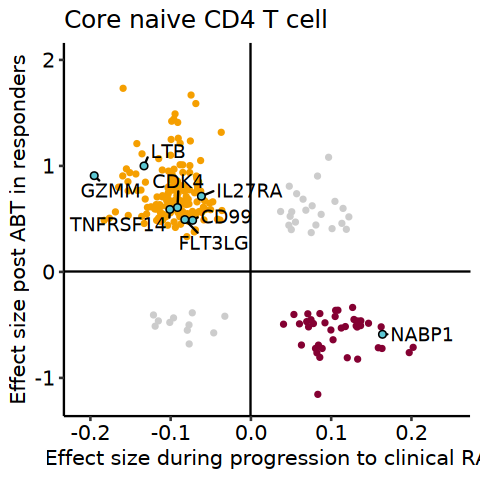

In [49]:
# plot the significant genes
options(repr.plot.width = 4, repr.plot.height = 4)
cell_type_plot =  'Core naive CD4 T cell'
# label perticular genes 
hightlight_genes = c( 'CD99', 'CDK4', 'CXCR3',
                     'FLT3LG', 'GZMM', 'LTB', 'TNFRSF14', 
                'IL27RA', 'NABP1')
abt_aim3_degs_comparison_sig %>% filter(cell_type==cell_type_plot)%>%group_by(direction)%>%tally()
p1 <- abt_aim3_degs_comparison_sig %>% filter(cell_type==cell_type_plot)%>%
    mutate(highlight_gene = if_else(gene%in%hightlight_genes, gene, NA))%>%
    ggplot(aes(y=log2FoldChange, x=365*estimate
                          )) +
    geom_point(aes(color=direction), size=1) +
    ggrepel::geom_text_repel(aes(label=highlight_gene), min.segment.length = 0,  nudge_x = 0.015
                            ) +
    geom_point(data = abt_aim3_degs_comparison_sig %>% filter(cell_type==cell_type_plot&gene%in%hightlight_genes), 
             fill = "#5DC7D3", color = "black", size = 1.5, shape = 21, stroke = .5) +  # Yellow fill with black outline
    geom_vline(xintercept = 0)+ geom_hline(yintercept = 0)+ 
    ylim(-1.2, 2) + xlim(-0.21, 0.25) +
    scale_color_manual(values = abt_colors) + 
    theme_pubr() +
    guides(color='none') + 
    labs(title = cell_type_plot, x='Effect size during progression to clinical RA', 
        y='Effect size post ABT in responders')
p1
ggsave(file.path(fig_path, paste0(proj_name,'abecetpt_responder_Aim3_deg_',cell_type_plot,'_logfc_cor_plot_labeled.pdf')),
       width=4, height=4)

direction,n
<fct>,<int>
Decreased during progression to RA& Decreased post ABT,8
Decreased during progression to RA& Increased post ABT,165
Increased during progression to RA& Decreased post ABT,37
Increased during progression to RA& Increased post ABT,23


Warning message:
“Removed 225 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 225 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


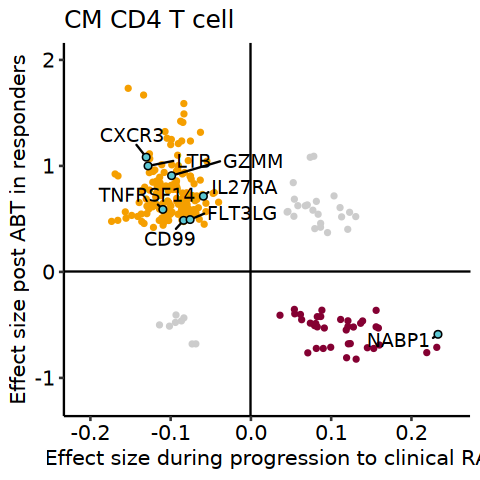

In [50]:
# plot the significant genes
cell_type_plot =  'CM CD4 T cell'
abt_aim3_degs_comparison_sig %>% filter(cell_type==cell_type_plot)%>%group_by(direction)%>%tally()
p1 <- abt_aim3_degs_comparison_sig %>% filter(cell_type==cell_type_plot)%>%
    mutate(highlight_gene = if_else(gene%in%hightlight_genes, gene, NA))%>%
    ggplot(aes(y=log2FoldChange, x=365*estimate
                          )) +
    geom_point(aes(color=direction), size=1) +
    ggrepel::geom_text_repel(aes(label=highlight_gene), min.segment.length = 0 , nudge_x = 0.015,
                            ) +
    geom_point(data = abt_aim3_degs_comparison_sig %>% filter(cell_type==cell_type_plot&gene%in%hightlight_genes), 
             fill = "#5DC7D3", color = "black", size = 1.5, shape = 21, stroke = .5) +  # Yellow fill with black outline
    geom_vline(xintercept = 0)+ geom_hline(yintercept = 0)+ 
    ylim(-1.2, 2) + xlim(-0.21, 0.25) +
    scale_color_manual(values = abt_colors) + theme_pubr() +
    guides(color='none') + 
    labs(title = cell_type_plot, x='Effect size during progression to clinical RA', 
        y='Effect size post ABT in responders')
p1
ggsave(file.path(fig_path, paste0(proj_name,'abecetpt_responder_Aim3_deg_',cell_type_plot,'_logfc_cor_plot_labeled.pdf')),
       width=4, height=4)

In [48]:
abt_aim3_degs_comparison_sig %>% filter(cell_type== 'CM CD4 T cell')%>%
    filter(q_values_abt<0.05&q_values_aim3<0.05&(aim3_direction=='aim3_up'&abt_direction=='abt_down'))

gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values_abt,cell_type,effect,group,⋯,estimate,std.error,statistic,df,pvalue_aim3,q_values_aim3,sig,aim3_direction,abt_direction,direction
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<fct>
LUC7L3,679.9239,-0.5293458,0.1714175,-3.088049,0.0020147510,0.038709759,CM CD4 T cell,fixed,NA,⋯,0.0004351209,0.0001701003,2.558025,45.91334,0.013892538,0.04473971,AbtSig&Aim3Sig,aim3_up,abt_down,Increased during progression to RA& Decreased post ABT
SF3B1,4378.0218,-0.4627013,0.1261296,-3.668459,0.0002440173,0.009410519,CM CD4 T cell,fixed,NA,⋯,0.0003812325,0.0001381306,2.759942,42.82167,0.008473902,0.04077438,AbtSig&Aim3Sig,aim3_up,abt_down,Increased during progression to RA& Decreased post ABT
PRPF3,878.1049,-0.4486165,0.1290589,-3.476060,0.0005088383,0.016073059,CM CD4 T cell,fixed,NA,⋯,0.0003062412,0.0001004173,3.049685,45.93138,0.003795473,0.03466158,AbtSig&Aim3Sig,aim3_up,abt_down,Increased during progression to RA& Decreased post ABT
NABP1,989.9993,-0.5886575,0.1972668,-2.984067,0.0028444415,0.048950275,CM CD4 T cell,fixed,NA,⋯,0.0006385191,0.0002046917,3.119418,45.18839,0.003151955,0.03424478,AbtSig&Aim3Sig,aim3_up,abt_down,Increased during progression to RA& Decreased post ABT
NAIP,1185.5164,-0.7612663,0.2454766,-3.101176,0.0019275351,0.037697551,CM CD4 T cell,fixed,NA,⋯,0.0006002651,0.0002313428,2.594700,43.30072,0.012871136,0.04393876,AbtSig&Aim3Sig,aim3_up,abt_down,Increased during progression to RA& Decreased post ABT


### plot individual genes

In [88]:
dds_resp

class: DESeqDataSet 
dim: 13608 14 
metadata(1): version
assays(4): counts mu H cooks
rownames(13608): TSPAN6 DPM1 ... AL031666.3 AC012510.1
rowData names(46): baseMean baseVar ... deviance maxCooks
colnames(14): R01_0M R01_3M ... R07_0M R07_3M
colData names(5): sample patient time response sizeFactor

In [89]:
vst_resp <- vst(dds_resp, blind=FALSE)
vst_resp

class: DESeqTransform 
dim: 13608 14 
metadata(1): version
assays(1): ''
rownames(13608): TSPAN6 DPM1 ... AL031666.3 AC012510.1
rowData names(46): baseMean baseVar ... maxCooks dispFit
colnames(14): R01_0M R01_3M ... R07_0M R07_3M
colData names(5): sample patient time response sizeFactor

In [92]:
NAIP_counts = tibble('Normalized counts'=assay(vst_resp)['NABP1', ], 
                     'time'=colData(vst_resp)$time, 
                    'patient'=colData(vst_resp)$patient)%>%
    mutate(timepoint=recode(time, '0M'='Pre-ABT', '3M'='Post-ABT'))
NAIP_counts%>%head()

Normalized counts,time,patient,timepoint
<dbl>,<fct>,<fct>,<fct>
9.352057,0M,R01,Pre-ABT
8.916999,3M,R01,Post-ABT
9.611694,0M,R02,Pre-ABT
9.042851,3M,R02,Post-ABT
10.831938,0M,R03,Pre-ABT
9.835668,3M,R03,Post-ABT


In [93]:
# NAIP_counts = plotCounts(vst_resp, 'NAIP', intgroup = c('time', 'patient'), returnData=TRUE)%>%
#     as_tibble()%>%
#     mutate(timepoint=recode(time, '0M'='Pre-treatment', '3M'='post-treatment'))
# NAIP_counts%>%head()

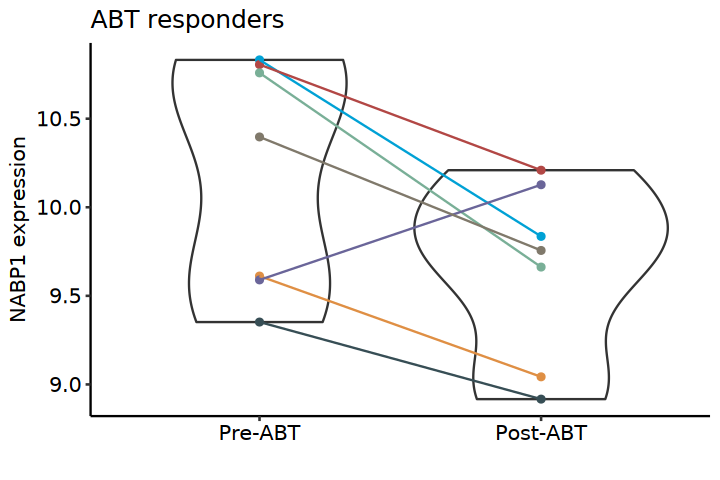

In [94]:
p2 <- NAIP_counts %>% 
        ggplot(aes(x = timepoint, y = `Normalized counts`)) +
        geom_violin(aes(), alpha = 0.6) +
        geom_point(aes(group = patient, color = patient)) +
        geom_line(aes(group = patient, color = patient)) +
        labs(title = "ABT responders", x = "", y = "NABP1 expression") +
        scale_color_manual(values = jama_color) +
        ggpubr::theme_pubr()  +
        scale_shape_manual(values = c(1, 2)) +
        guides(color = 'none', fill = 'none')
p2
ggsave(file.path(fig_path, paste0(proj_name,'abecetpt_responder_NABP1_expression.pdf')),
       width=3, height=3)

# check AIM1 DEGs

In [7]:
# load aim1 deg
aim1_degs <- read_csv(file.path(file.path(data_path, 
                                          'AIM1_DC_batch_corr_DESeq_results_NA_filtered.csv')), 
                      show_col_types = FALSE, col_select = -1)%>%
    rename('genes'='gene')
aim1_degs%>%head()

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'rename': '/home/jupyter/data/ra_longitudinal/output_results/pseudobulk/deepclean/counts/combined/AIM1_DC_batch_corr_DESeq_results_NA_filtered.csv' does not exist.


In [68]:
# check the deg counts
aim1_degs_counts = aim1_degs %>% mutate(sig_0_1=if_else(q_values<0.1 & abs(log2FoldChange)>0.1, 'sig', 'ns'))%>%
    group_by(cell_type)%>%mutate(total_genes = n())%>%
    group_by(cell_type, sig_0_1)%>%summarise(counts =n(), total_genes=unique(total_genes))
aim1_degs_counts%>%filter(cell_type%in%c('Core_naive_CD4_T_cell', 'CM_CD4_T_cell'))

`summarise()` has grouped output by 'cell_type'. You can override using the
`.groups` argument.


cell_type,sig_0_1,counts,total_genes
<chr>,<chr>,<int>,<int>
CM_CD4_T_cell,ns,2947,4791
CM_CD4_T_cell,sig,1844,4791
Core_naive_CD4_T_cell,ns,2654,4349
Core_naive_CD4_T_cell,sig,1695,4349


In [69]:
# make a degs list per cell type
aim1_degs_sig <- aim1_degs %>%
    filter(q_values<0.05 & abs(log2FoldChange)>0.1)
celltypes_test = aim1_degs_sig%>%group_by(cell_type) %>%
    tally()%>%filter(n>10)%>%pull(cell_type)%>%
    unique()
aim1_genes_list = lapply(celltypes_test, function(x){
    sig_genes <- aim1_degs_sig %>%
        filter(cell_type==x)%>%pull(gene)
    return(sig_genes)
})

names(aim1_genes_list) = celltypes_test
# aim3_genes_list
abt_sig_genes <- dds_resp_res_tb%>%filter(q_values<0.05)%>%pull(gene)
abt_bg_genes <- dds_resp_res_tb %>%pull(gene)

aim1_hyp_obj <- hypeR(abt_sig_genes, aim1_genes_list, 
                 test="hypergeometric", background=length(abt_bg_genes), plotting=TRUE)


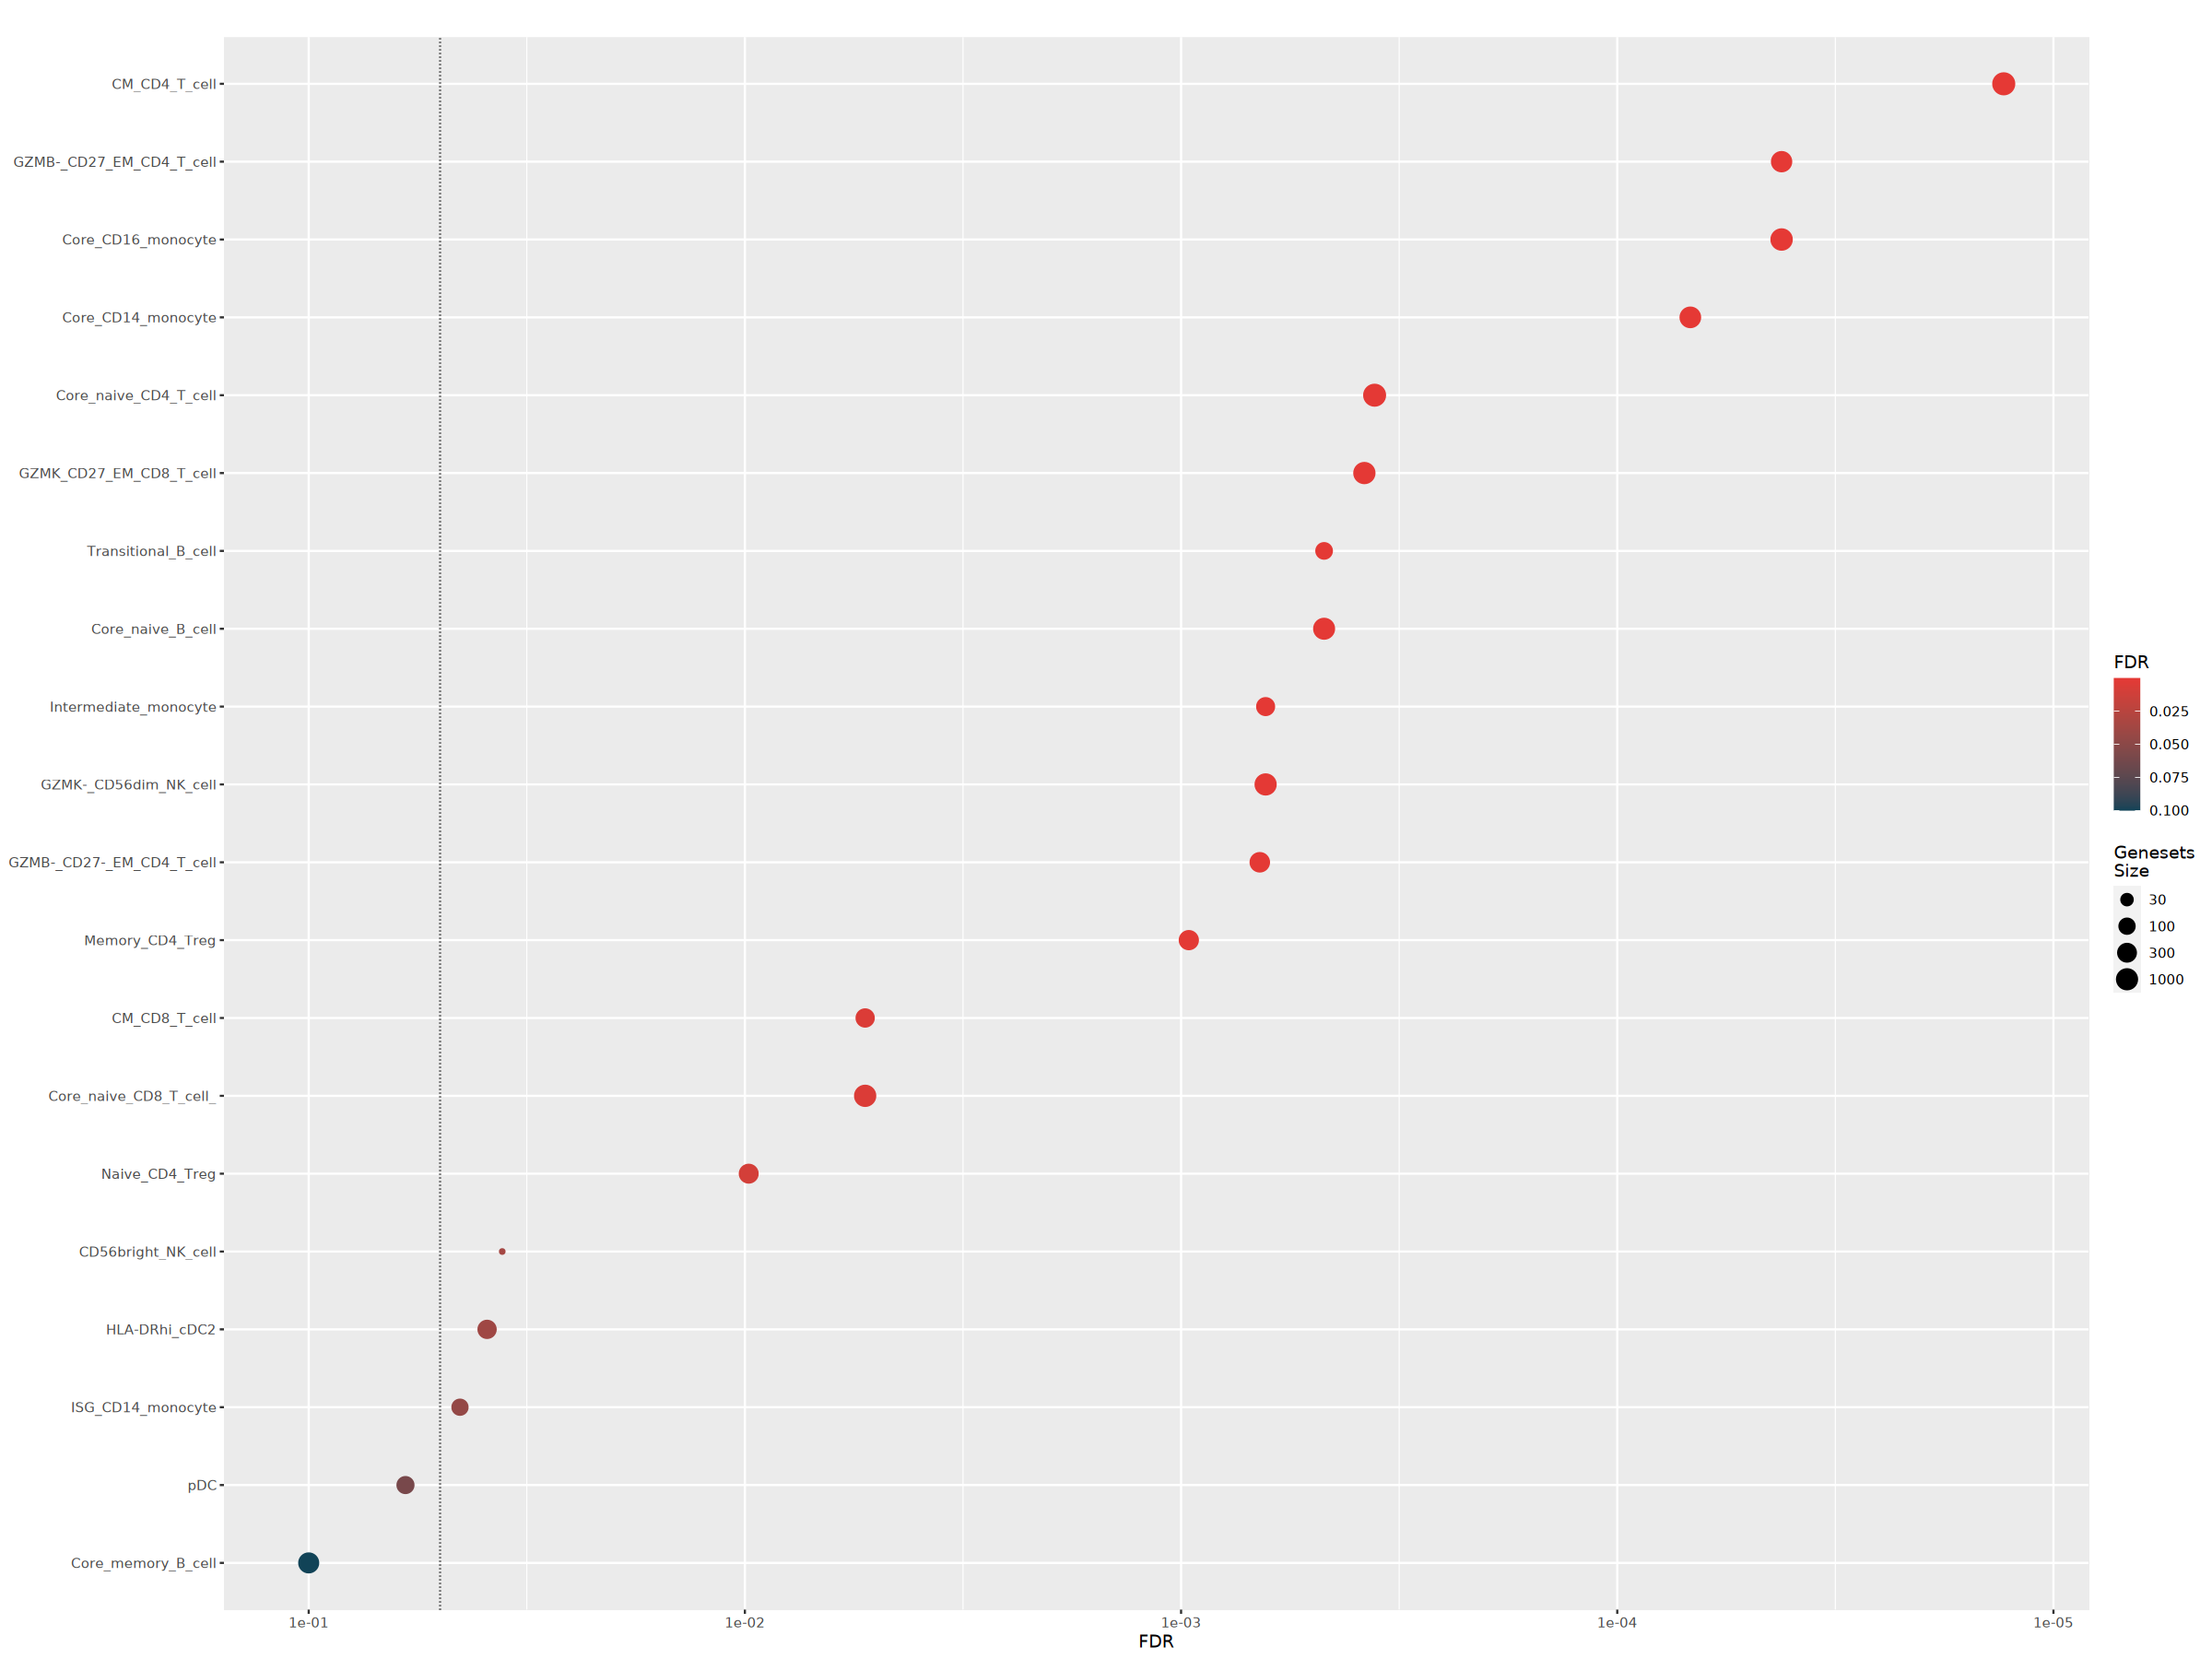

In [70]:
hyp_dots(aim1_hyp_obj)
ggsave(file.path(fig_path, paste0(proj_name, 'aim1_gene_signature_abt_responder.png')), width = 8, height = 4)

In [71]:
# make a degs list per cell type
aim1_degs_sig <- aim1_degs %>%
    filter(q_values<0.05 & abs(log2FoldChange)>0.1)
celltypes_test = aim1_degs_sig%>%group_by(cell_type) %>%
    tally()%>%filter(n>10)%>%pull(cell_type)%>%
    unique()
aim1_genes_list = lapply(celltypes_test, function(x){
    sig_genes <- aim1_degs_sig %>%
        filter(cell_type==x)%>%pull(gene)
    return(sig_genes)
})

names(aim1_genes_list) = celltypes_test
# aim3_genes_list
abt_sig_genes <- dds_nonresp_res_tb%>%filter(q_values<0.1)%>%pull(gene)
abt_bg_genes <- dds_nonresp_res_tb %>%pull(gene)

aim1_hyp_nonp <- hypeR(abt_sig_genes, aim1_genes_list, 
                 test="hypergeometric", background=length(abt_bg_genes), plotting=TRUE)


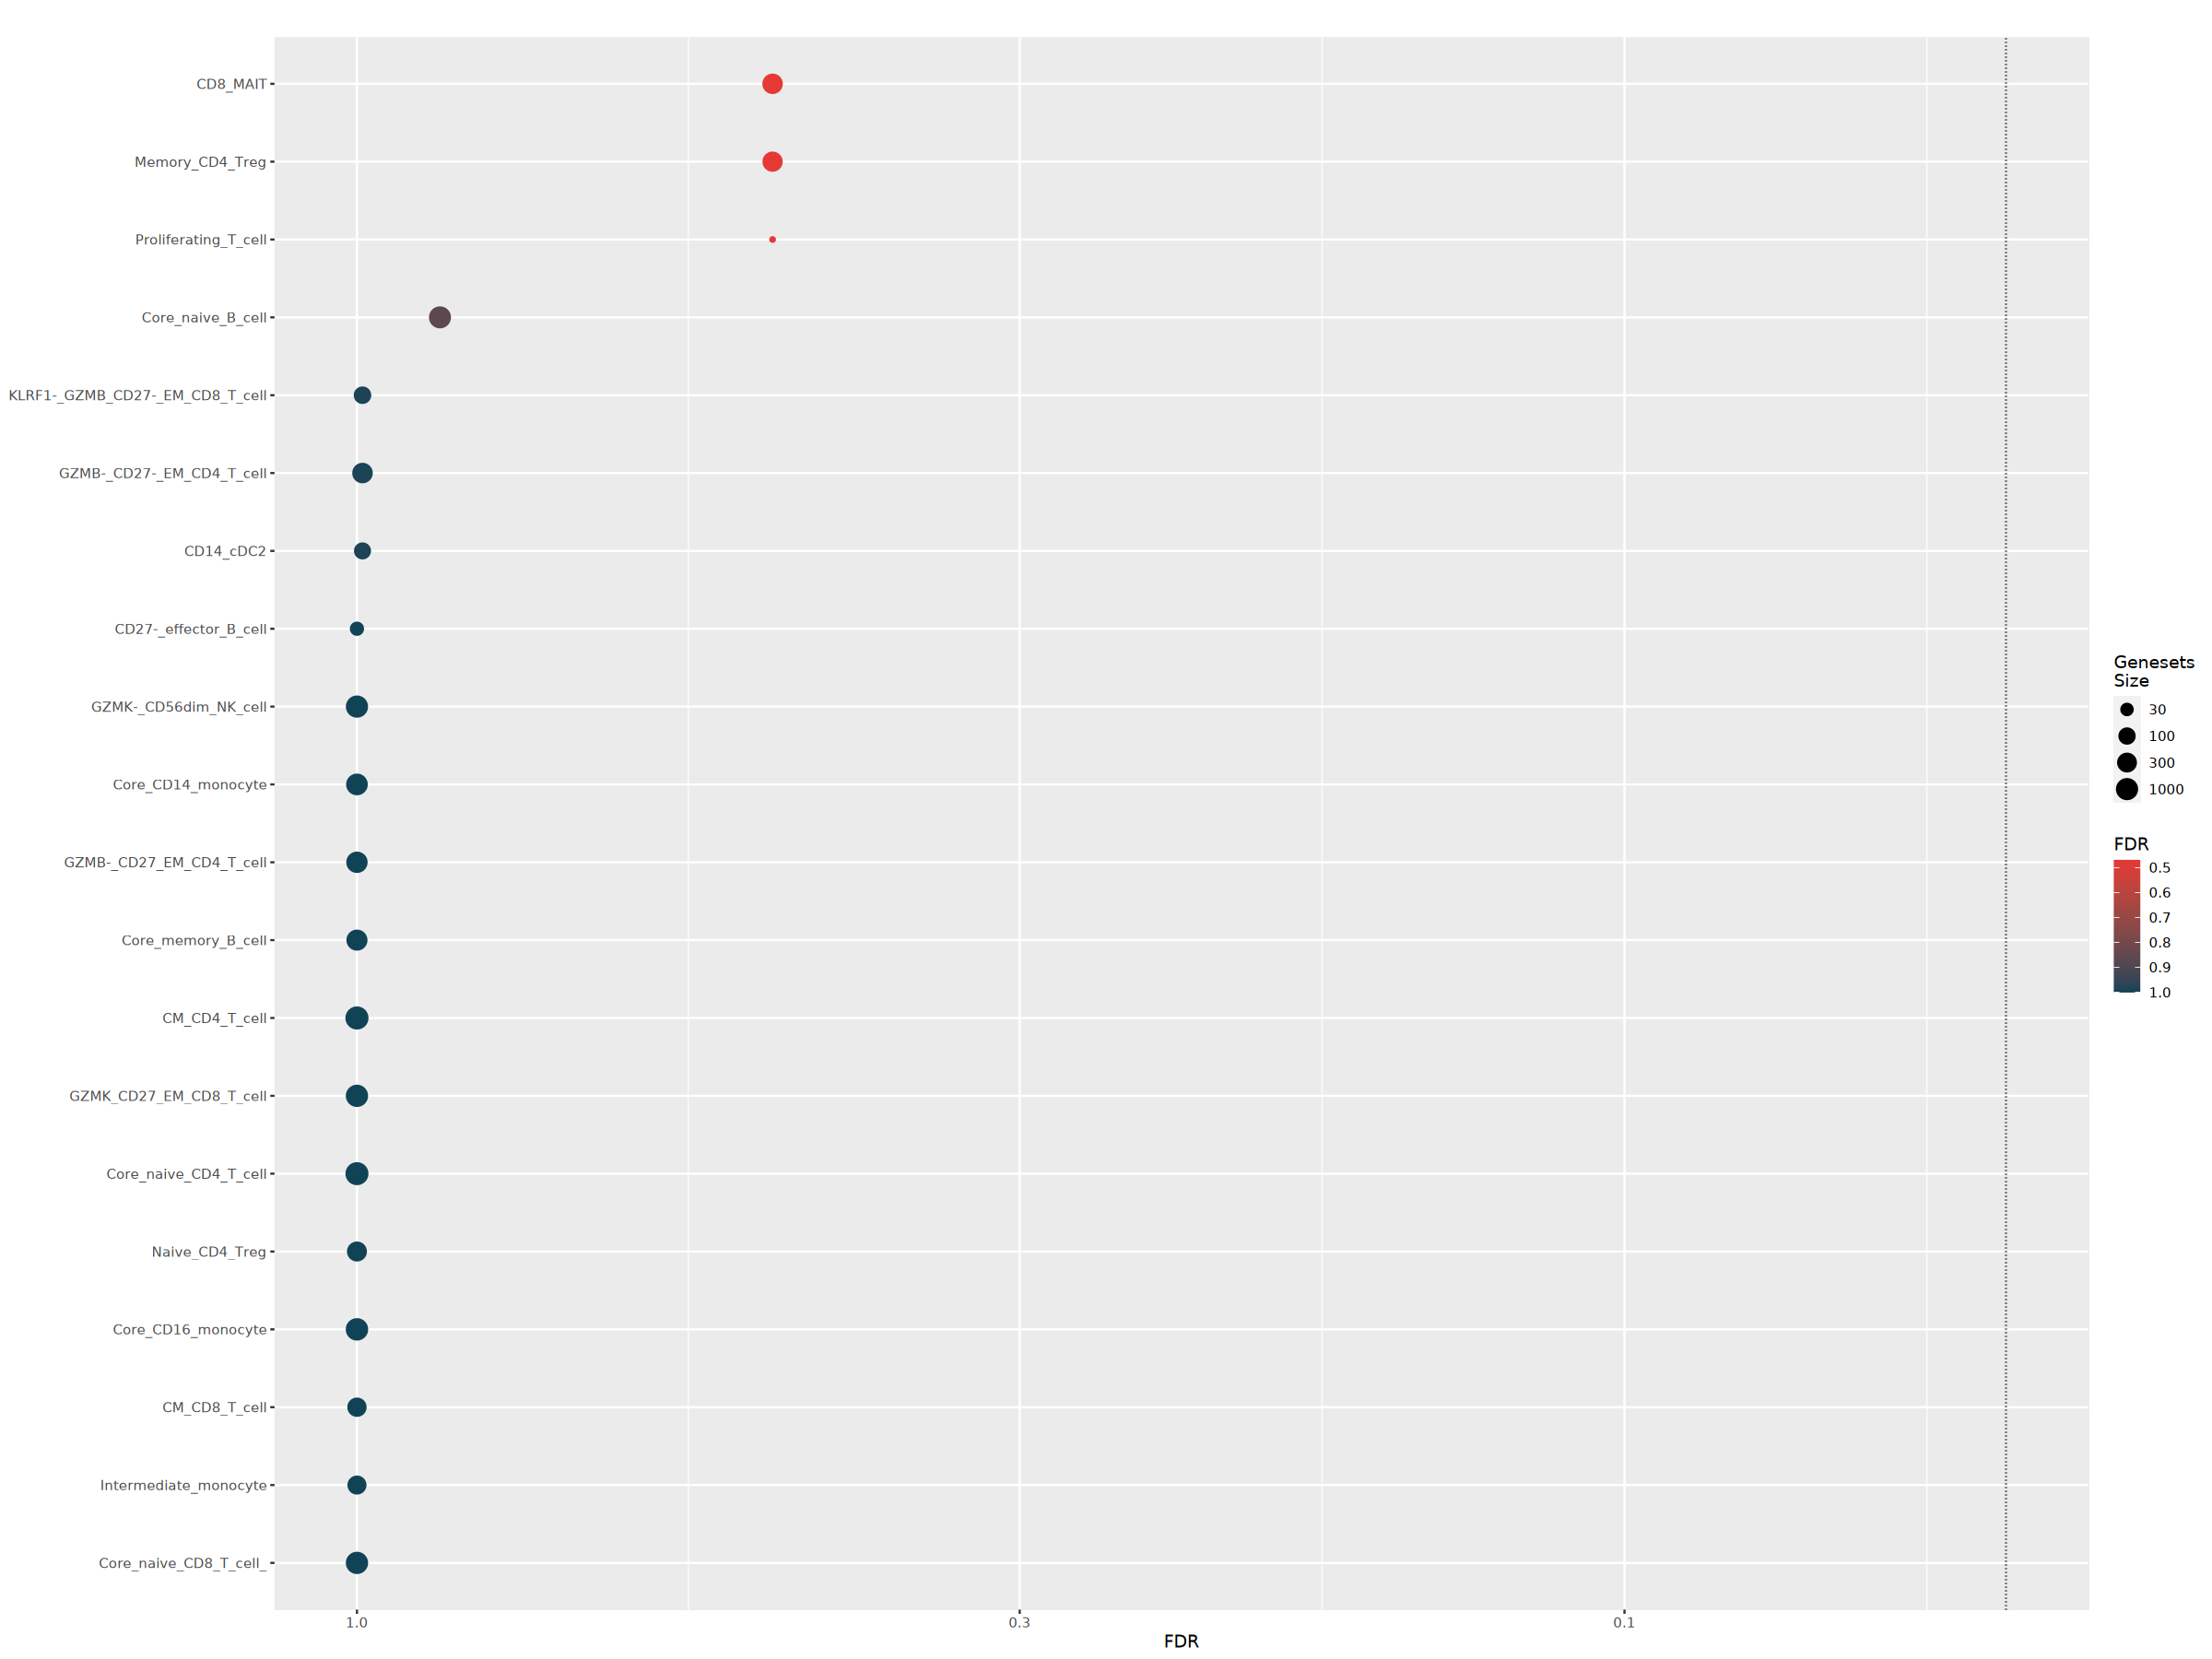

In [72]:
hyp_dots(aim1_hyp_nonp)
ggsave(file.path(fig_path, paste0(proj_name, 'aim1_gene_signature_abt_nonresponder.png')), width = 8, height = 4)

### run mcnemar test

In [75]:
aim1_degs%>%head()

cell_type,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,model_formula,q_values,direction
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>
Adaptive_NK_cell,54.04846,0.124886781,0.10474924,1.19224524,0.2331650997,0.65360396,AAK1,age +Sex+batch_corr+BMI+Status_Xsec,0.49841121,up
Adaptive_NK_cell,29.54902,0.094338813,0.11742573,0.80339129,0.4217486082,0.79037868,ABCF1,age +Sex+batch_corr+BMI+Status_Xsec,0.60480375,up
Adaptive_NK_cell,114.98916,-0.001701419,0.05889166,-0.02889066,0.9769517945,0.99458630,ABHD17A,age +Sex+batch_corr+BMI+Status_Xsec,0.74073517,down
Adaptive_NK_cell,30.14195,0.301588542,0.10930861,2.75905557,0.0057968677,0.15706719,ABI3,age +Sex+batch_corr+BMI+Status_Xsec,0.13914985,up
Adaptive_NK_cell,31.84575,0.192048519,0.10262771,1.87131261,0.0613017639,0.38423224,ABRACL,age +Sex+batch_corr+BMI+Status_Xsec,0.32251676,up
Adaptive_NK_cell,32.79473,-0.333036304,0.10102916,-3.29643738,0.0009791944,0.07784423,AC004687.1,age +Sex+batch_corr+BMI+Status_Xsec,0.07766794,down


In [86]:
# combine the deg results
abt_aim1_degs_comparison <- dds_resp_res_tb %>% full_join(aim1_degs, by=c('gene'),
                                          suffix = c('_abt', '_aim1'))%>%
   # dplyr::rename('pvalue_aim1'='pvalue')%>%
   filter(q_values_aim1<0.1 & #padj<0.1&
          !is.na(log2FoldChange_abt))%>% 
    mutate(sig = case_when(q_values_abt<=0.05&q_values_aim1<=0.1 ~ 'AbtSig&Aim1Sig', 
                    q_values_abt>0.05&q_values_aim1<=0.1 ~ 'Aim1Sig', 
                    q_values_abt<=0.05&q_values_aim1>0.1 ~ 'AbtSig', 
                    q_values_abt>0.05&q_values_aim1>0.1~ 'No sig'))%>% 
    mutate(aim1_direction = if_else(log2FoldChange_aim1>0, 'aim1_up', 'aim1_down'),
          abt_direction = if_else(log2FoldChange_abt>0, 'abt_up', 'abt_down'))
abt_aim3_degs_comparison%>%colnames()
#run mcnemar test
abt_aim1_degs_comparison_counts <- abt_aim1_degs_comparison %>% filter(q_values_abt<0.1)%>%
    group_by(cell_type, aim1_direction, abt_direction)%>% tally()%>%
    ungroup()
celltypes_test = abt_aim1_degs_comparison_counts%>%
    group_by(cell_type)%>%tally()%>%filter(n>=4)%>%pull(cell_type)
celltypes_test

# cont_counts = abt_aim3_degs_comparison_counts%>%filter(cell_type=='Core_naive_CD4_T_cell')%>%
#     pivot_wider(id_cols = aim3_direction, names_from = abt_direction , values_from = n)
# sex_counts = aim1_filedesc_fl%>%group_by(status, subject.biologicalSex)%>%tally()%>%
#     pivot_wider(id_cols = subject.biologicalSex, names_from = status , values_from = n)
# sex_counts 


[1] "gene"           "baseMean"       "log2FoldChange" "lfcSE"         
 [5] "stat"           "pvalue"         "padj"           "q_values_abt"  
 [9] "cell_type"      "effect"         "group"          "term"          
[13] "estimate"       "std.error"      "statistic"      "df"            
[17] "pvalue_aim3"    "q_values_aim3"  "sig"            "aim3_direction"
[21] "abt_direction"

[1] "CD8_MAIT"                        "CM_CD4_T_cell"                  
 [3] "CM_CD8_T_cell"                   "Core_CD14_monocyte"             
 [5] "Core_CD16_monocyte"              "Core_memory_B_cell"             
 [7] "Core_naive_B_cell"               "Core_naive_CD4_T_cell"          
 [9] "Core_naive_CD8_T_cell_"          "GZMB-_CD27_EM_CD4_T_cell"       
[11] "GZMB_Vd2_gdT"                    "GZMK-_CD56dim_NK_cell"          
[13] "GZMK_CD27_EM_CD8_T_cell"         "HLA-DRhi_cDC2"                  
[15] "ISG_CD16_monocyte"               "Intermediate_monocyte"          
[17] "KLRF1-_GZMB_CD27-_EM_CD8_T_cell" "Memory_CD4_Treg"                
[19] "Naive_CD4_Treg"                  "pDC"

In [93]:
run_mcnemar_test = function(x){
    cont_counts = x %>%
            pivot_wider(id_cols = aim1_direction, 
                        names_from = abt_direction , values_from = n)
    # print(cont_counts)
    test_res = rstatix::mcnemar_test(cont_counts%>%select(-aim1_direction))%>% as_tibble()
    return(test_res)
}

mcnemar_res <- abt_aim1_degs_comparison_counts%>%filter(cell_type%in%celltypes_test)%>%group_by(cell_type)%>% 
    group_modify(~run_mcnemar_test(.x))%>%rstatix::adjust_pvalue(p.col = 'p', method = 'BH')
mcnemar_res_sig = mcnemar_res%>%filter(p.adj<0.05)
mcnemar_res_sig

cell_type,n,statistic,df,p,p.signif,method,p.adj
<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
CD8_MAIT,89,8.470588,1,0.003610,**,McNemar test,0.003610
CM_CD4_T_cell,258,8.756757,1,0.003080,**,McNemar test,0.003080
Core_naive_B_cell,149,6.722222,1,0.009520,**,McNemar test,0.009520
Core_naive_CD4_T_cell,235,10.617647,1,0.001120,**,McNemar test,0.001120
Core_naive_CD8_T_cell_,170,7.840000,1,0.005110,**,McNemar test,0.005110
GZMK_CD27_EM_CD8_T_cell,177,11.130435,1,0.000849,***,McNemar test,0.000849


In [90]:
abt_aim1_degs_comparison_counts%>%
    filter(cell_type%in%c('CM_CD4_T_cell'))%>%
            pivot_wider(id_cols = c(cell_type, aim1_direction), 
                        names_from = abt_direction , values_from = n)

cell_type,aim1_direction,abt_down,abt_up
<chr>,<chr>,<int>,<int>
CM_CD4_T_cell,aim1_down,41,28
CM_CD4_T_cell,aim1_up,9,180


In [36]:
# GGally::ggtable(abt_aim3_degs_comparison %>% filter(q_values_abt<0.1)%>%
#     filter(cell_type%in%c('Core_naive_CD4_T_cell', 'CM_CD4_T_cell')),
#         "cell_type", c("aim3_direction", "abt_direction"))

Warning message:
“ggrepel: 840 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 2629 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 2724 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 1831 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 1444 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 1694 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 840 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 2629 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 2724 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggr

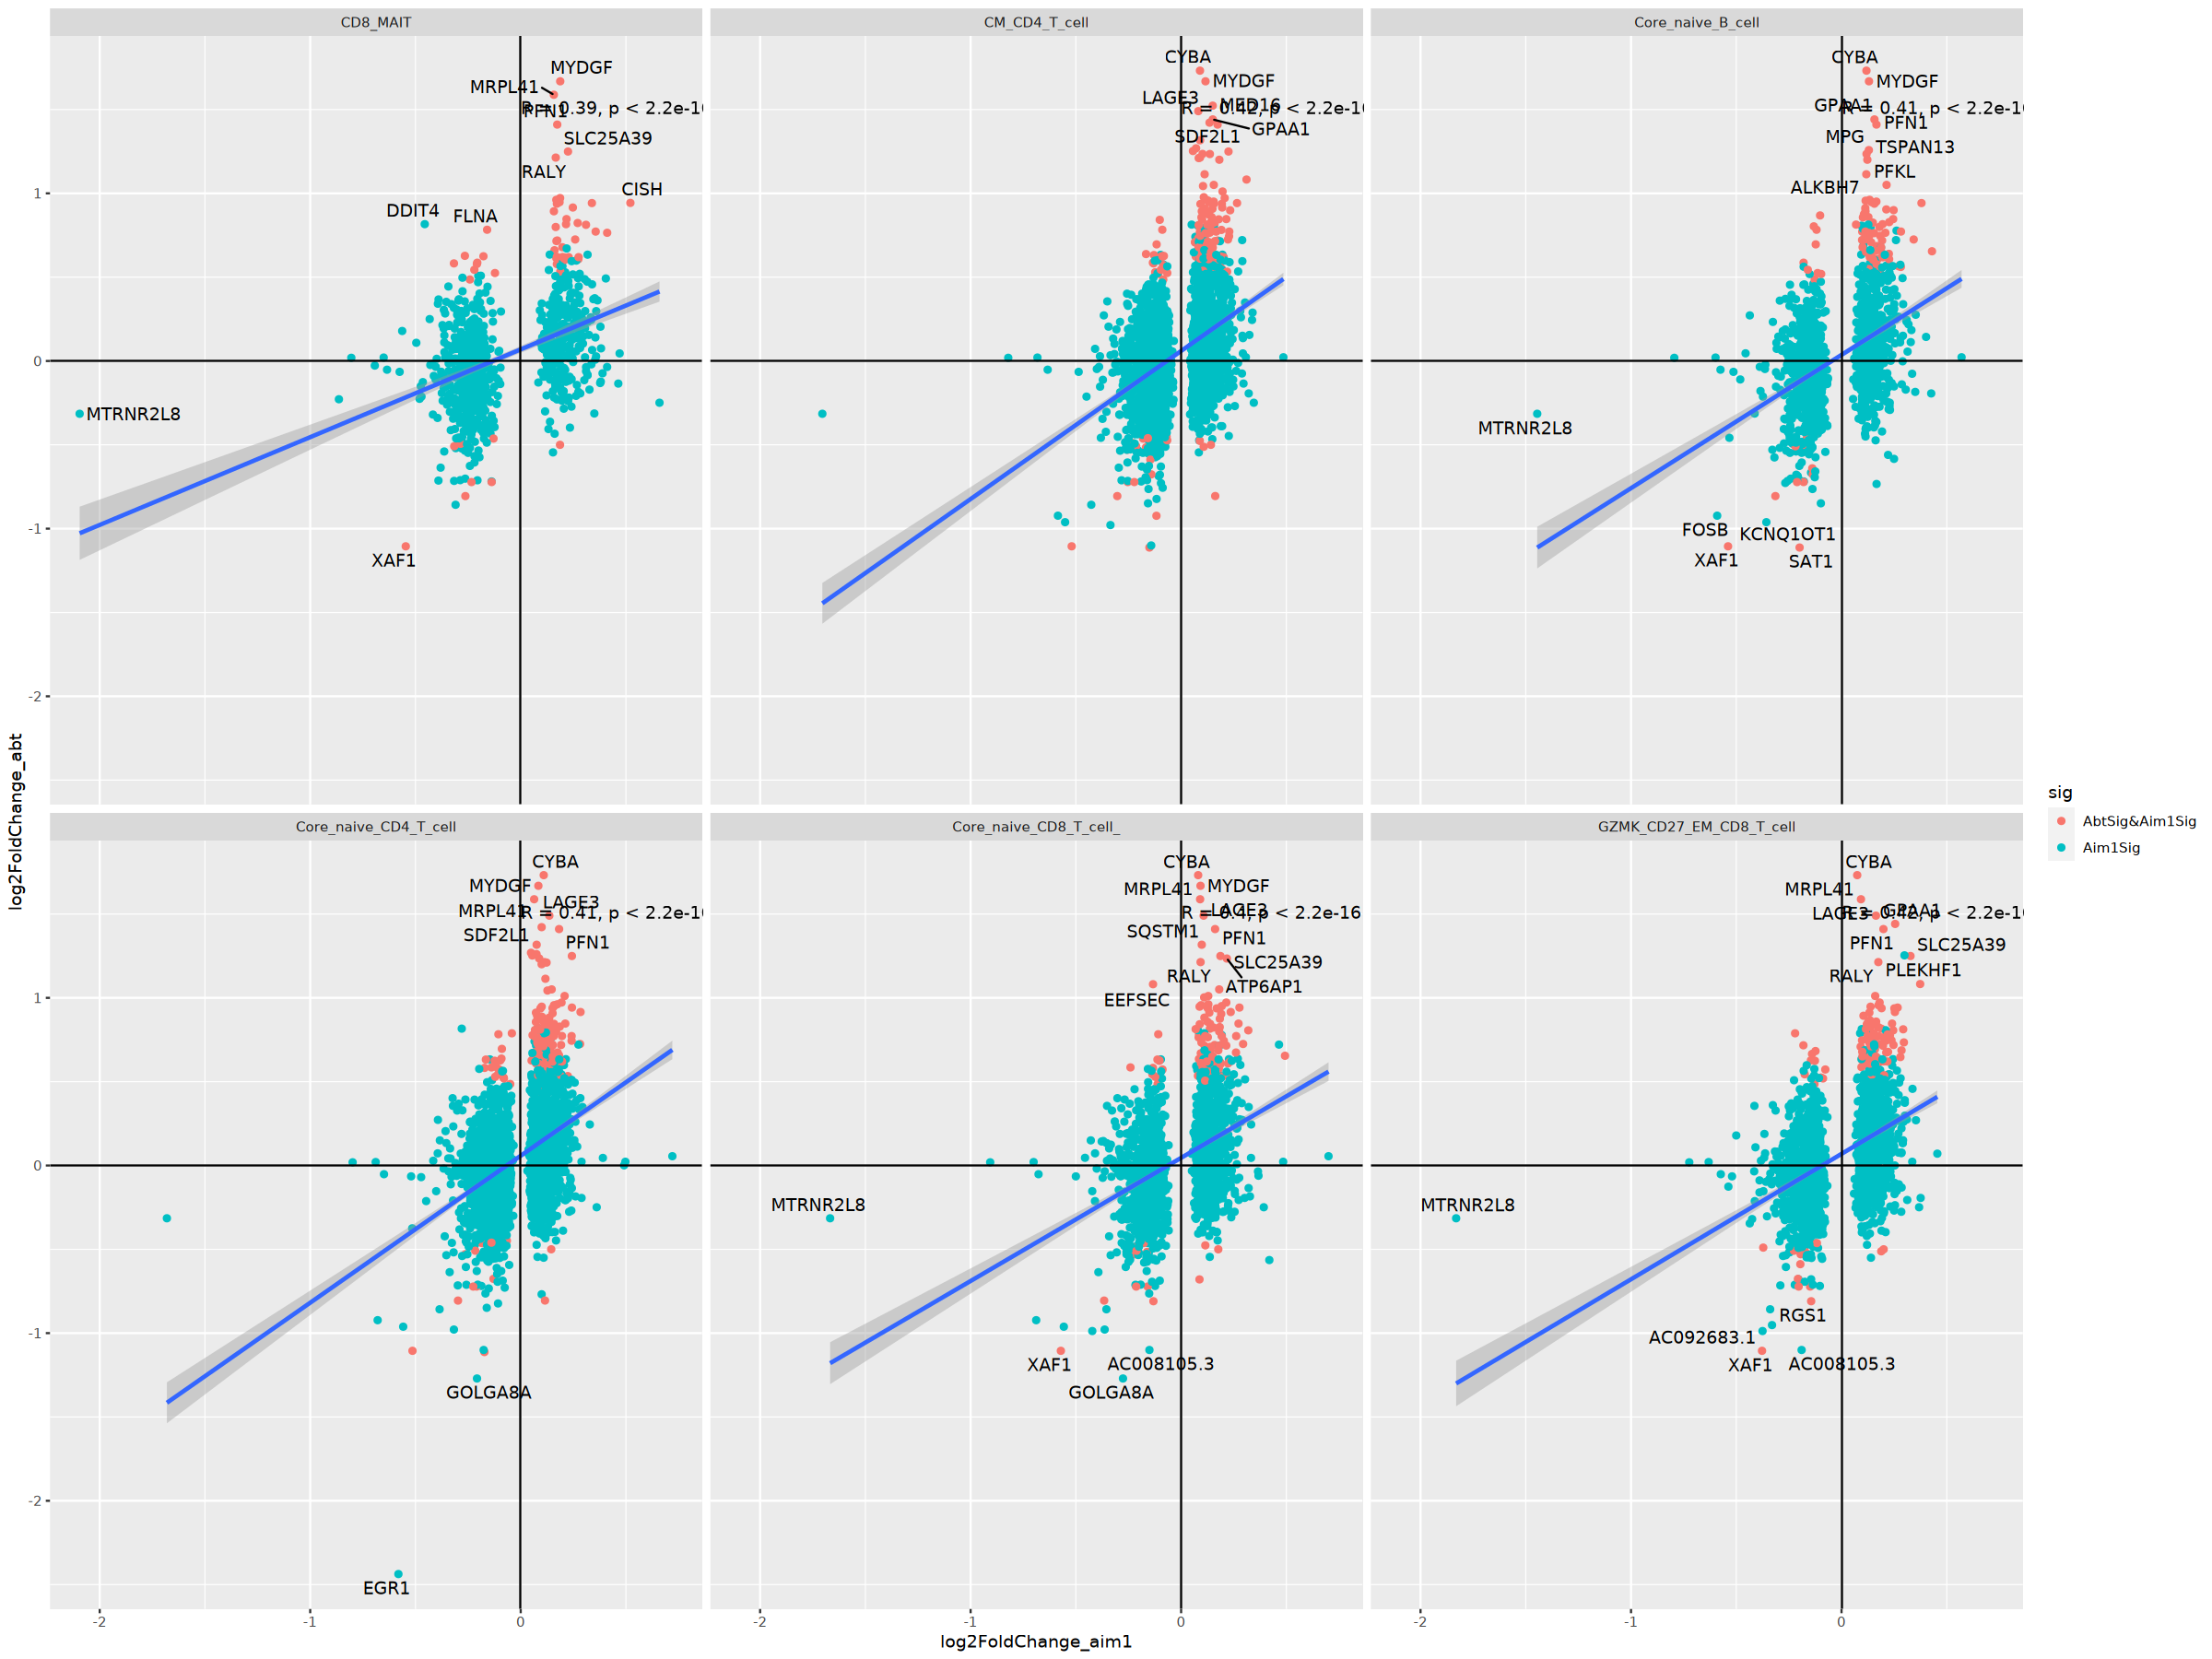

In [94]:
abt_aim1_degs_comparison%>%filter(cell_type%in%	mcnemar_res_sig$cell_type)%>%
    ggplot(aes(y=log2FoldChange_abt, x=log2FoldChange_aim1
                          )) +
    geom_point(aes(color=sig)) +
    ggrepel::geom_text_repel(aes(label=gene)
                            ) +
    stat_smooth(method = "lm", 
              formula = y ~ x, 
              geom = "smooth") + 
    geom_vline(xintercept = 0)+ geom_hline(yintercept = 0)+ 
    ggpubr::stat_cor(method = "spearman", label.x = 0.0005, label.y = 1.5)+
    facet_wrap(vars(cell_type))
ggsave(file.path(fig_path, paste0('abecetpt_Aim1_deg_all_celltype_logfc_cor_plot.png')),
       width=8, height=6)

In [38]:
# abt_cor <- abt_aim3_degs_comparison %>% filter(!is.na(log2FoldChange) & !is.na(estimate))%>% 
#   group_by(cell_type) %>% 
#   rstatix::cor_test(log2FoldChange, estimate, method =  "spearman", 
#                     conf.level=TRUE)

In [39]:
# p1 <- ggplot(abt_cor, aes(x=cell_type, y=cor)) +
#   geom_segment( aes(x=cell_type, xend=cell_type, y=0, yend=cor), color="grey") +
#   geom_point( size=2) + #ylim(-0.5, 1)+
#   geom_hline(yintercept = 0 ,linetype=2)+
#  # geom_errorbar( aes( ymin=cor-sd, ymax=value+sd), width=0.4, colour="orange", alpha=0.9, size=1.3)+
#   theme_light() +  coord_flip()+
#   theme(
#     panel.grid.major.x = element_blank(),
#     panel.border = element_blank(),
#     axis.ticks.x = element_blank(),
#     #legend.position="none"
#   ) + scale_color_manual(values = npg_color)+
#   xlab("") +
#   ylab("spearman correlation coefficient") +
#     ggtitle('responder', )
# p1

# load another dataset from NEJM flare

In [43]:
nejm_data <- readxl::read_excel('/home/jupyter/data/ra_longitudinal/reference_data/nejmoa2004114_appendix_2.xlsx')%>%
    rename('name'='gene')%>%filter(gene!='NA')%>%distinct(gene, .keep_all = TRUE)

In [44]:
nejm_data%>%head()

ensembl,gene,name_source,description,logFC,logCPM,FDR
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
ENSG00000256338,RPL41P2,HGNC Symbol,ribosomal protein L41 pseudogene 2 [Source:HGNC Symbol;Acc:HGNC:10357],-1.934136,0.2149057,5.767447e-08
ENSG00000228502,EEF1A1P11,HGNC Symbol,eukaryotic translation elongation factor 1 alpha 1 pseudogene 11 [Source:HGNC Symbol;Acc:HGNC:3206],-1.446084,4.0518119,2.292396e-07
ENSG00000250182,EEF1A1P13,HGNC Symbol,eukaryotic translation elongation factor 1 alpha 1 pseudogene 13 [Source:HGNC Symbol;Acc:HGNC:3196],-1.375901,5.0689613,3.008709e-07
ENSG00000227939,RPL3P2,HGNC Symbol,ribosomal protein L3 pseudogene 2 [Source:HGNC Symbol;Acc:HGNC:17834],-1.902478,-0.7005859,3.008709e-07
ENSG00000200314,RF00019,RFAM,NA,3.339845,-1.0335337,3.008709e-07
ENSG00000234589,AC125807.1,Clone-based (Ensembl) gene,NA,-1.736728,1.9032545,6.501664e-07


In [49]:
data_path = '/home/jupyter/data/ra_longitudinal/output_results/certPro'
# load aim3 deg
aim3_degs <- read_csv(file.path(file.path(data_path, 
                                          'ALTRA_AIM3_certpro_scRNA_Pseudobulk_AIFI_l3_mixed_models_time_result_750days.csv')), 
                      show_col_types = FALSE)%>%
    dplyr::rename('cell_type'='celltype')

In [50]:
# combine the deg results
aim3_nejm_degs_comparison <- aim3_degs %>% left_join(nejm_data, by=c('gene'),
                                          suffix = c('_aim3', '_nejm'))%>%
   filter(#q_values<0.1 & #padj<0.1&
          !is.na(logFC))%>% 
    mutate(sig = case_when(FDR<=0.1&q_values<=0.1 ~ 'FlareSig&Aim3Sig', 
                    FDR>0.1&q_values<=0.1 ~ 'Aim3Sig', 
                    FDR<=0.1&q_values>0.1 ~ 'FlareSig', 
                    FDR>0.1&q_values>0.1~ 'No sig'))%>% 
    mutate(aim3_direction = if_else(estimate>0, 'aim3_up', 'aim3_down'),
          flare_direction = if_else(logFC>0, 'Flare_up', 'Flare_down'))%>%
    mutate(direction=
           case_when(aim3_direction == 'aim3_up' & flare_direction=='Flare_up' ~ 
                     'Increased during progression to RA&\nIncreased during flare', 
                    aim3_direction == 'aim3_down' & flare_direction=='Flare_down' ~ 
                     'Decreased during progression to RA&\nDecreased during flare', 
                     aim3_direction == 'aim3_down' & flare_direction=='Flare_up' ~ 
                     'Decreased during progression to RA&\nIncreased during flare', 
                     aim3_direction == 'aim3_up' & flare_direction=='Flare_down' ~ 
                     'Increased during progression to RA&\nDecreased during flare'))
aim3_nejm_degs_comparison%>%head()

cell_type,effect,group,term,estimate,std.error,statistic,df,p.value,gene,⋯,sig,ensembl,name_source,description,logFC,logCPM,FDR,aim3_direction,flare_direction,direction
<chr>,<chr>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
Adaptive NK cell,fixed,NA,days_to_conversion,-4.601178e-04,0.0001726325,-2.6653027,43.00000,0.01079008,AAK1,⋯,No sig,ENSG00000115977,HGNC Symbol,AP2 associated kinase 1 [Source:HGNC Symbol;Acc:HGNC:19679],0.029849071,6.3642973,0.8712088,aim3_down,Flare_up,Decreased during progression to RA& Increased during flare
Adaptive NK cell,fixed,NA,days_to_conversion,2.698218e-04,0.0001816877,1.4850857,43.00000,0.14481591,AASDHPPT,⋯,No sig,ENSG00000149313,HGNC Symbol,aminoadipate-semialdehyde dehydrogenase-phosphopantetheinyl transferase [Source:HGNC Symbol;Acc:HGNC:14235],0.159937500,4.8946000,0.4538066,aim3_up,Flare_up,Increased during progression to RA& Increased during flare
Adaptive NK cell,fixed,NA,days_to_conversion,-1.164469e-04,0.0001820954,-0.6394831,41.24902,0.52604448,ABCB1,⋯,No sig,ENSG00000085563,HGNC Symbol,ATP binding cassette subfamily B member 1 [Source:HGNC Symbol;Acc:HGNC:40],-0.098615225,3.7545085,0.6145664,aim3_down,Flare_down,Decreased during progression to RA& Decreased during flare
Adaptive NK cell,fixed,NA,days_to_conversion,-2.050641e-04,0.0002058161,-0.9963461,43.00000,0.32465598,ABCE1,⋯,No sig,ENSG00000164163,HGNC Symbol,ATP binding cassette subfamily E member 1 [Source:HGNC Symbol;Acc:HGNC:69],-0.005359729,5.3650380,0.9870516,aim3_down,Flare_down,Decreased during progression to RA& Decreased during flare
Adaptive NK cell,fixed,NA,days_to_conversion,-3.740837e-06,0.0001426124,-0.0262308,43.00000,0.97919461,ABCF1,⋯,No sig,ENSG00000204574,HGNC Symbol,ATP binding cassette subfamily F member 1 [Source:HGNC Symbol;Acc:HGNC:70],-0.148733521,4.3501007,0.5923405,aim3_down,Flare_down,Decreased during progression to RA& Decreased during flare
Adaptive NK cell,fixed,NA,days_to_conversion,-2.906780e-04,0.0001214907,-2.3925944,39.69616,0.02155430,ABHD14A,⋯,No sig,ENSG00000248487,HGNC Symbol,abhydrolase domain containing 14A [Source:HGNC Symbol;Acc:HGNC:24538],-0.336803370,0.8247337,0.2680594,aim3_down,Flare_down,Decreased during progression to RA& Decreased during flare


In [51]:
# filter the significant gene only genes
aim3_nejm_degs_comparison_sig <- aim3_nejm_degs_comparison %>% 
    filter(q_values<0.1&FDR<0.1)
aim3_nejm_degs_comparison_sig%>%head()

cell_type,effect,group,term,estimate,std.error,statistic,df,p.value,gene,⋯,sig,ensembl,name_source,description,logFC,logCPM,FDR,aim3_direction,flare_direction,direction
<chr>,<chr>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
CM CD4 T cell,fixed,NA,days_to_conversion,0.0002269404,7.668232e-05,2.959488,43.51191,0.004970366,ACAP2,⋯,FlareSig&Aim3Sig,ENSG00000114331,HGNC Symbol,"ArfGAP with coiled-coil, ankyrin repeat and PH domains 2 [Source:HGNC Symbol;Acc:HGNC:16469]",0.3809206,9.017713,0.04164785,aim3_up,Flare_up,Increased during progression to RA& Increased during flare
CM CD4 T cell,fixed,NA,days_to_conversion,-0.0003304166,1.099219e-04,-3.005922,41.87940,0.004460411,ACYP2,⋯,FlareSig&Aim3Sig,ENSG00000170634,HGNC Symbol,acylphosphatase 2 [Source:HGNC Symbol;Acc:HGNC:180],-0.1759292,3.921884,0.08439549,aim3_down,Flare_down,Decreased during progression to RA& Decreased during flare
CM CD4 T cell,fixed,NA,days_to_conversion,0.0002216625,1.242118e-04,1.784552,45.85584,0.080950651,ADAM10,⋯,FlareSig&Aim3Sig,ENSG00000137845,HGNC Symbol,ADAM metallopeptidase domain 10 [Source:HGNC Symbol;Acc:HGNC:188],0.3629616,8.436037,0.06182886,aim3_up,Flare_up,Increased during progression to RA& Increased during flare
CM CD4 T cell,fixed,NA,days_to_conversion,0.0001865534,1.009105e-04,1.848701,43.54482,0.071298076,ADAM17,⋯,FlareSig&Aim3Sig,ENSG00000151694,HGNC Symbol,ADAM metallopeptidase domain 17 [Source:HGNC Symbol;Acc:HGNC:195],0.2821374,6.079256,0.06380881,aim3_up,Flare_up,Increased during progression to RA& Increased during flare
CM CD4 T cell,fixed,NA,days_to_conversion,0.0003212349,1.901793e-04,1.689116,45.84361,0.097988516,AFF1,⋯,FlareSig&Aim3Sig,ENSG00000172493,HGNC Symbol,AF4/FMR2 family member 1 [Source:HGNC Symbol;Acc:HGNC:7135],0.2251575,7.904203,0.03594687,aim3_up,Flare_up,Increased during progression to RA& Increased during flare
CM CD4 T cell,fixed,NA,days_to_conversion,0.0003647214,1.569177e-04,2.324284,45.89837,0.024590608,AGFG1,⋯,FlareSig&Aim3Sig,ENSG00000173744,HGNC Symbol,ArfGAP with FG repeats 1 [Source:HGNC Symbol;Acc:HGNC:5175],0.3244298,6.646023,0.03747529,aim3_up,Flare_up,Increased during progression to RA& Increased during flare


aim3_direction,flare_direction,n
<chr>,<chr>,<int>
aim3_down,Flare_down,16
aim3_down,Flare_up,98
aim3_up,Flare_down,4
aim3_up,Flare_up,173


Warning message:
“ggrepel: 261 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


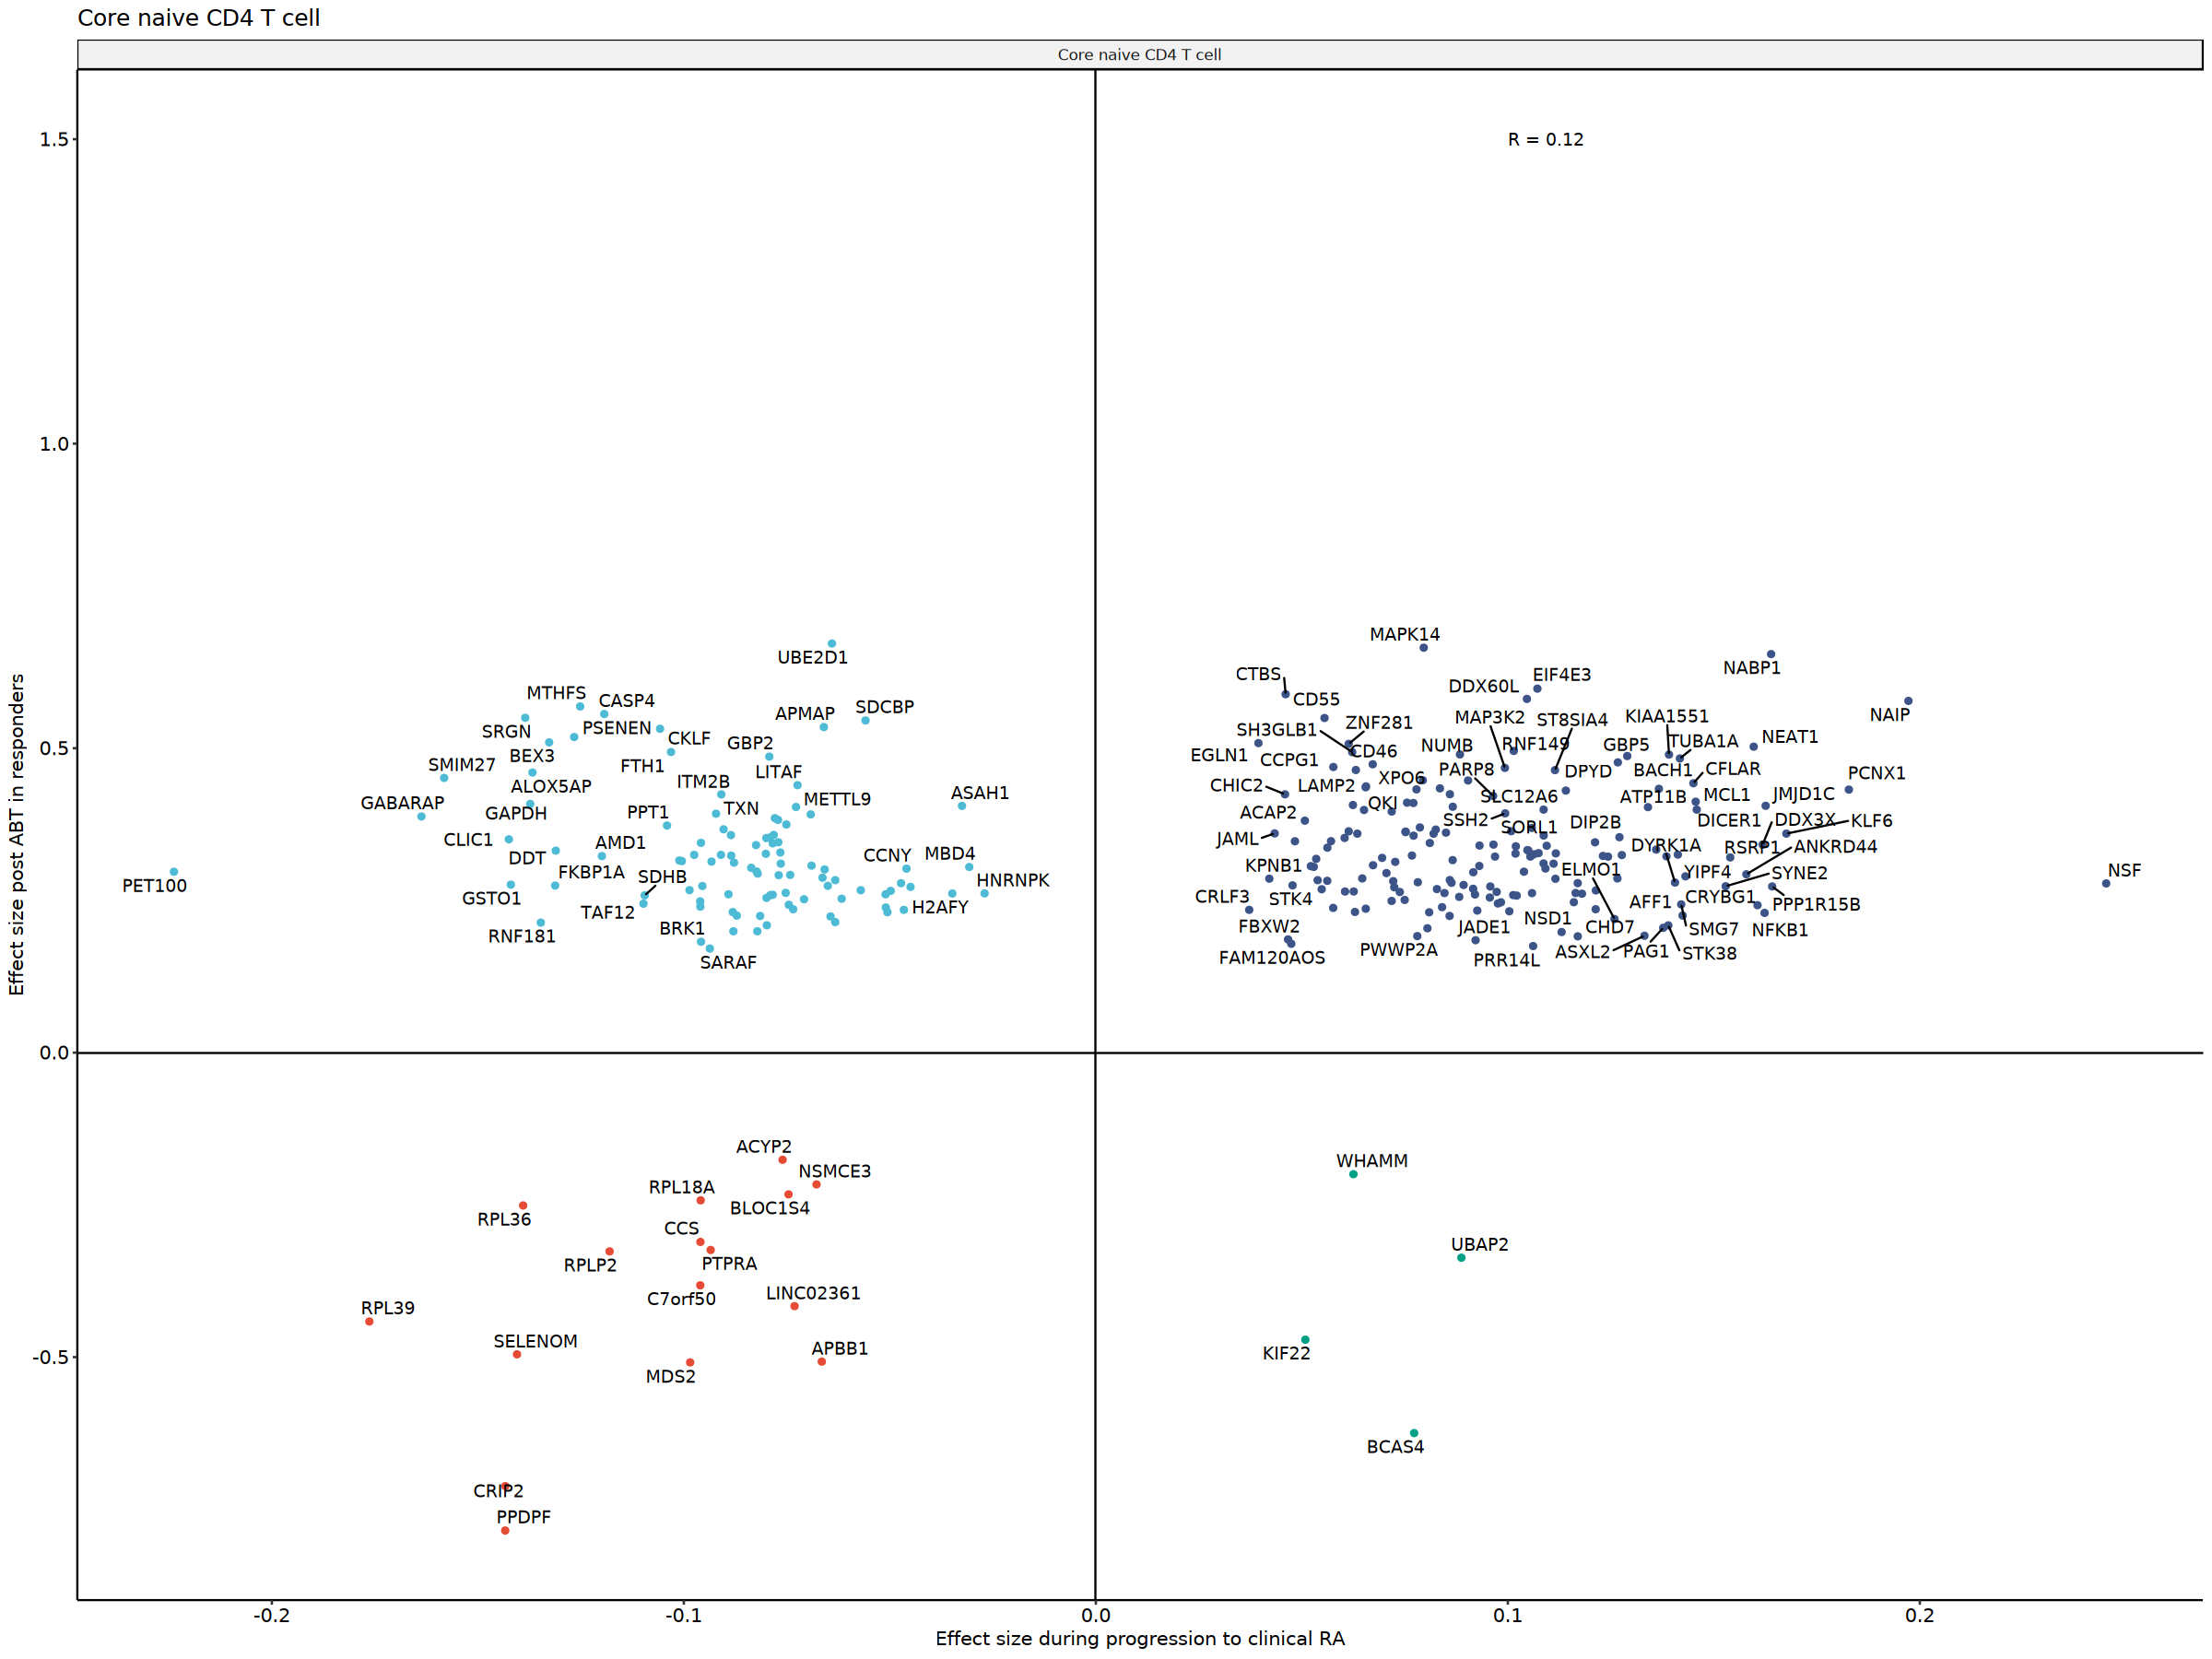

In [52]:
# plot the significant genes
cell_type_plot =  'Core naive CD4 T cell'
aim3_nejm_degs_comparison_sig %>%filter(q_values<0.1) %>%
    filter(cell_type==cell_type_plot)%>%group_by(aim3_direction, flare_direction)%>%tally()
p1 <- aim3_nejm_degs_comparison %>%filter(q_values<0.1 & FDR<0.1)%>% filter(cell_type==cell_type_plot)%>%
    ggplot(aes(y=logFC, x=365*estimate
                          )) +
    geom_point(aes(color=direction)) +
    ggrepel::geom_text_repel(aes(label=gene), 
                            ) +
    # stat_smooth(method = "lm", 
    #           formula = y ~ x, 
    #           geom = "smooth") + 
    geom_vline(xintercept = 0)+ geom_hline(yintercept = 0)+ 
    ggpubr::stat_cor(aes(label = after_stat(r.label)), method = "spearman", label.x = 0.1, label.y = 1.5)+
    facet_wrap(vars(cell_type)) + 
    scale_color_manual(values = npg_color) + theme_pubr() +
    guides(color='none') + 
    labs(title = cell_type_plot, x='Effect size during progression to clinical RA', 
        y='Effect size post ABT in responders')
p1
# ggsave(file.path(fig_path, paste0(proj_name,'abecetpt_responder_Aim3_deg_',cell_type_plot,'_logfc_cor_plot.pdf')),
#        width=4, height=4)

In [55]:
up_genes = aim3_nejm_degs_comparison %>% filter(q_values<0.1 & FDR<0.1)%>% filter(cell_type==cell_type_plot)%>%
    filter(cell_type==cell_type_plot&aim3_direction=='aim3_up'&flare_direction=='Flare_up')%>%pull(gene)
down_genes = aim3_nejm_degs_comparison%>% filter(FDR<0.05) %>% 
    filter(cell_type==cell_type_plot&aim3_direction=='aim3_down'&flare_direction=='Flare_up')%>%pull(gene)

In [56]:
# pathway enrichment for cd4na
enrich_up_genes <- enrichr(up_genes, c('KEGG_2021_Human', 'MSigDB_Hallmark_2020'))
enrich_up_genes[["MSigDB_Hallmark_2020"]]%>% filter(Adjusted.P.value<0.05)

Uploading data to Enrichr... Done.
  Querying KEGG_2021_Human... Done.
  Querying MSigDB_Hallmark_2020... Done.
Parsing results... Done.


Term,Overlap,P.value,Adjusted.P.value,Old.P.value,Old.Adjusted.P.value,Odds.Ratio,Combined.Score,Genes
<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<chr>
Protein Secretion,6/96,0.0001870823,0.002966912,0,0,7.879042,67.63339,RPS6KA3;AP1G1;CLTC;LAMP2;ADAM10;MAPK1
PI3K/AKT/mTOR Signaling,6/105,0.0003046557,0.002966912,0,0,7.159499,57.96566,RPS6KA3;CAB39;CLTC;MAPK1;IRAK4;RAF1
Complement,8/200,0.0003596257,0.002966912,0,0,4.958333,39.32180,VCPIP1;AKAP10;GNG2;LAMP2;LCP2;RAF1;CD46;CD55
Inflammatory Response,8/200,0.0003596257,0.002966912,0,0,4.958333,39.32180,KLF6;EIF2AK2;LCP2;RAF1;HIF1A;NFKB1;CD55;IFNAR1
G2-M Checkpoint,7/200,0.0018137748,0.011970914,0,0,4.289843,27.07897,DR1;NUP50;NUP98;MAPK14;HIF1A;RAD23B;KPNB1
TNF-alpha Signaling via NF-kB,6/200,0.0079825800,0.030714760,0,0,3.635965,17.56351,NFAT5;KLF6;CFLAR;NFKB1;CD44;MCL1
Interferon Gamma Response,6/200,0.0079825800,0.030714760,0,0,3.635965,17.56351,EIF4E3;ST8SIA4;EIF2AK2;LCP2;HIF1A;NFKB1
heme Metabolism,6/200,0.0079825800,0.030714760,0,0,3.635965,17.56351,LAMP2;GAPVD1;YPEL5;BACH1;KLF3;KDM7A
UV Response Dn,5/144,0.0083767526,0.030714760,0,0,4.215485,20.15969,CELF2;DYRK1A;MAPK14;NFKB1;TGFBR2


In [57]:
# pathway enrichment for cd4na
enrich_down_genes <- enrichr(down_genes, c('KEGG_2021_Human', 'MSigDB_Hallmark_2020'))
enrich_down_genes[["MSigDB_Hallmark_2020"]]%>% filter(Adjusted.P.value<0.05)

Uploading data to Enrichr... Done.
  Querying KEGG_2021_Human... Done.
  Querying MSigDB_Hallmark_2020... Done.
Parsing results... Done.


Term,Overlap,P.value,Adjusted.P.value,Old.P.value,Old.Adjusted.P.value,Odds.Ratio,Combined.Score,Genes
<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<chr>
mTORC1 Signaling,7/200,0.0003067777,0.00398811,0,0,5.898728,47.71710,LDHA;ELOVL5;NAMPT;PGK1;SLA;GLRX;GAPDH
Xenobiotic Metabolism,7/200,0.0003067777,0.00398811,0,0,5.898728,47.71710,PGRMC1;DHRS7;ELOVL5;GSTO1;CAT;TMBIM6;ALDH9A1
Allograft Rejection,7/200,0.0003067777,0.00398811,0,0,5.898728,47.71710,IFNAR2;SRGN;IFNGR2;UBE2D1;DEGS1;GBP2;CTSS
Complement,6/200,0.0018327436,0.01429540,0,0,4.988508,31.43728,GCA;CPQ;CASP4;IRF2;CD59;CTSS
Oxidative Phosphorylation,6/200,0.0018327436,0.01429540,0,0,4.988508,31.43728,PRDX3;HADHB;LDHA;SLC25A3;ATP6V0E1;SDHB
Fatty Acid Metabolism,5/158,0.0035041961,0.02178004,0,0,5.239120,29.62091,HADHB;LDHA;ELOVL5;HSD17B11;ALDH9A1
Androgen Response,4/100,0.0039092376,0.02178004,0,0,6.645161,36.84352,VAPA;TMEM50A;ELOVL5;MYL12A
Pperoxisome,4/104,0.0044953465,0.02191481,0,0,6.378065,34.47161,ELOVL5;CAT;HSD17B11;ALDH9A1
Hypoxia,5/200,0.0093444922,0.03313047,0,0,4.101939,19.16823,LDHA;PGK1;GLRX;NR3C1;GAPDH


In [57]:
# make a degs list per cell type
celltypes_test = aim3_degs %>%
    filter(q_values<0.1)%>%group_by(cell_type) %>%
    tally()%>%filter(n>10)%>%pull(cell_type)%>%
    unique()
aim3_genes_list = lapply(celltypes_test, function(x){
    sig_genes <- aim3_degs %>%
        filter(cell_type==x&q_values<0.1)%>%pull(gene)
    return(sig_genes)
})

names(aim3_genes_list) = celltypes_test

flare_sig_genes <- nejm_data%>%filter(FDR<0.05)%>%pull(gene)
flare_sig_genes%>%length()

hyp_obj <- hypeR(flare_sig_genes,aim3_genes_list , 
                 test="hypergeometric", background=length(aim3_bg_genes), plotting=TRUE)
hyp_obj

[1] 1670

(hyp) 

  data: 
                     label pval fdr signature geneset overlap background
             CM CD4 T cell    1   1      1670    2712     191       4950
             CM CD8 T cell    1   1      1670      46       1       4950
         Core naive B cell    1   1      1670      45       4       4950
     Core naive CD4 T cell    1   1      1670    2651     194       4950
     Core naive CD8 T cell    1   1      1670     305      14       4950
 GZMK+ CD27+ EM CD8 T cell    1   1      1670      59       0       4950
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

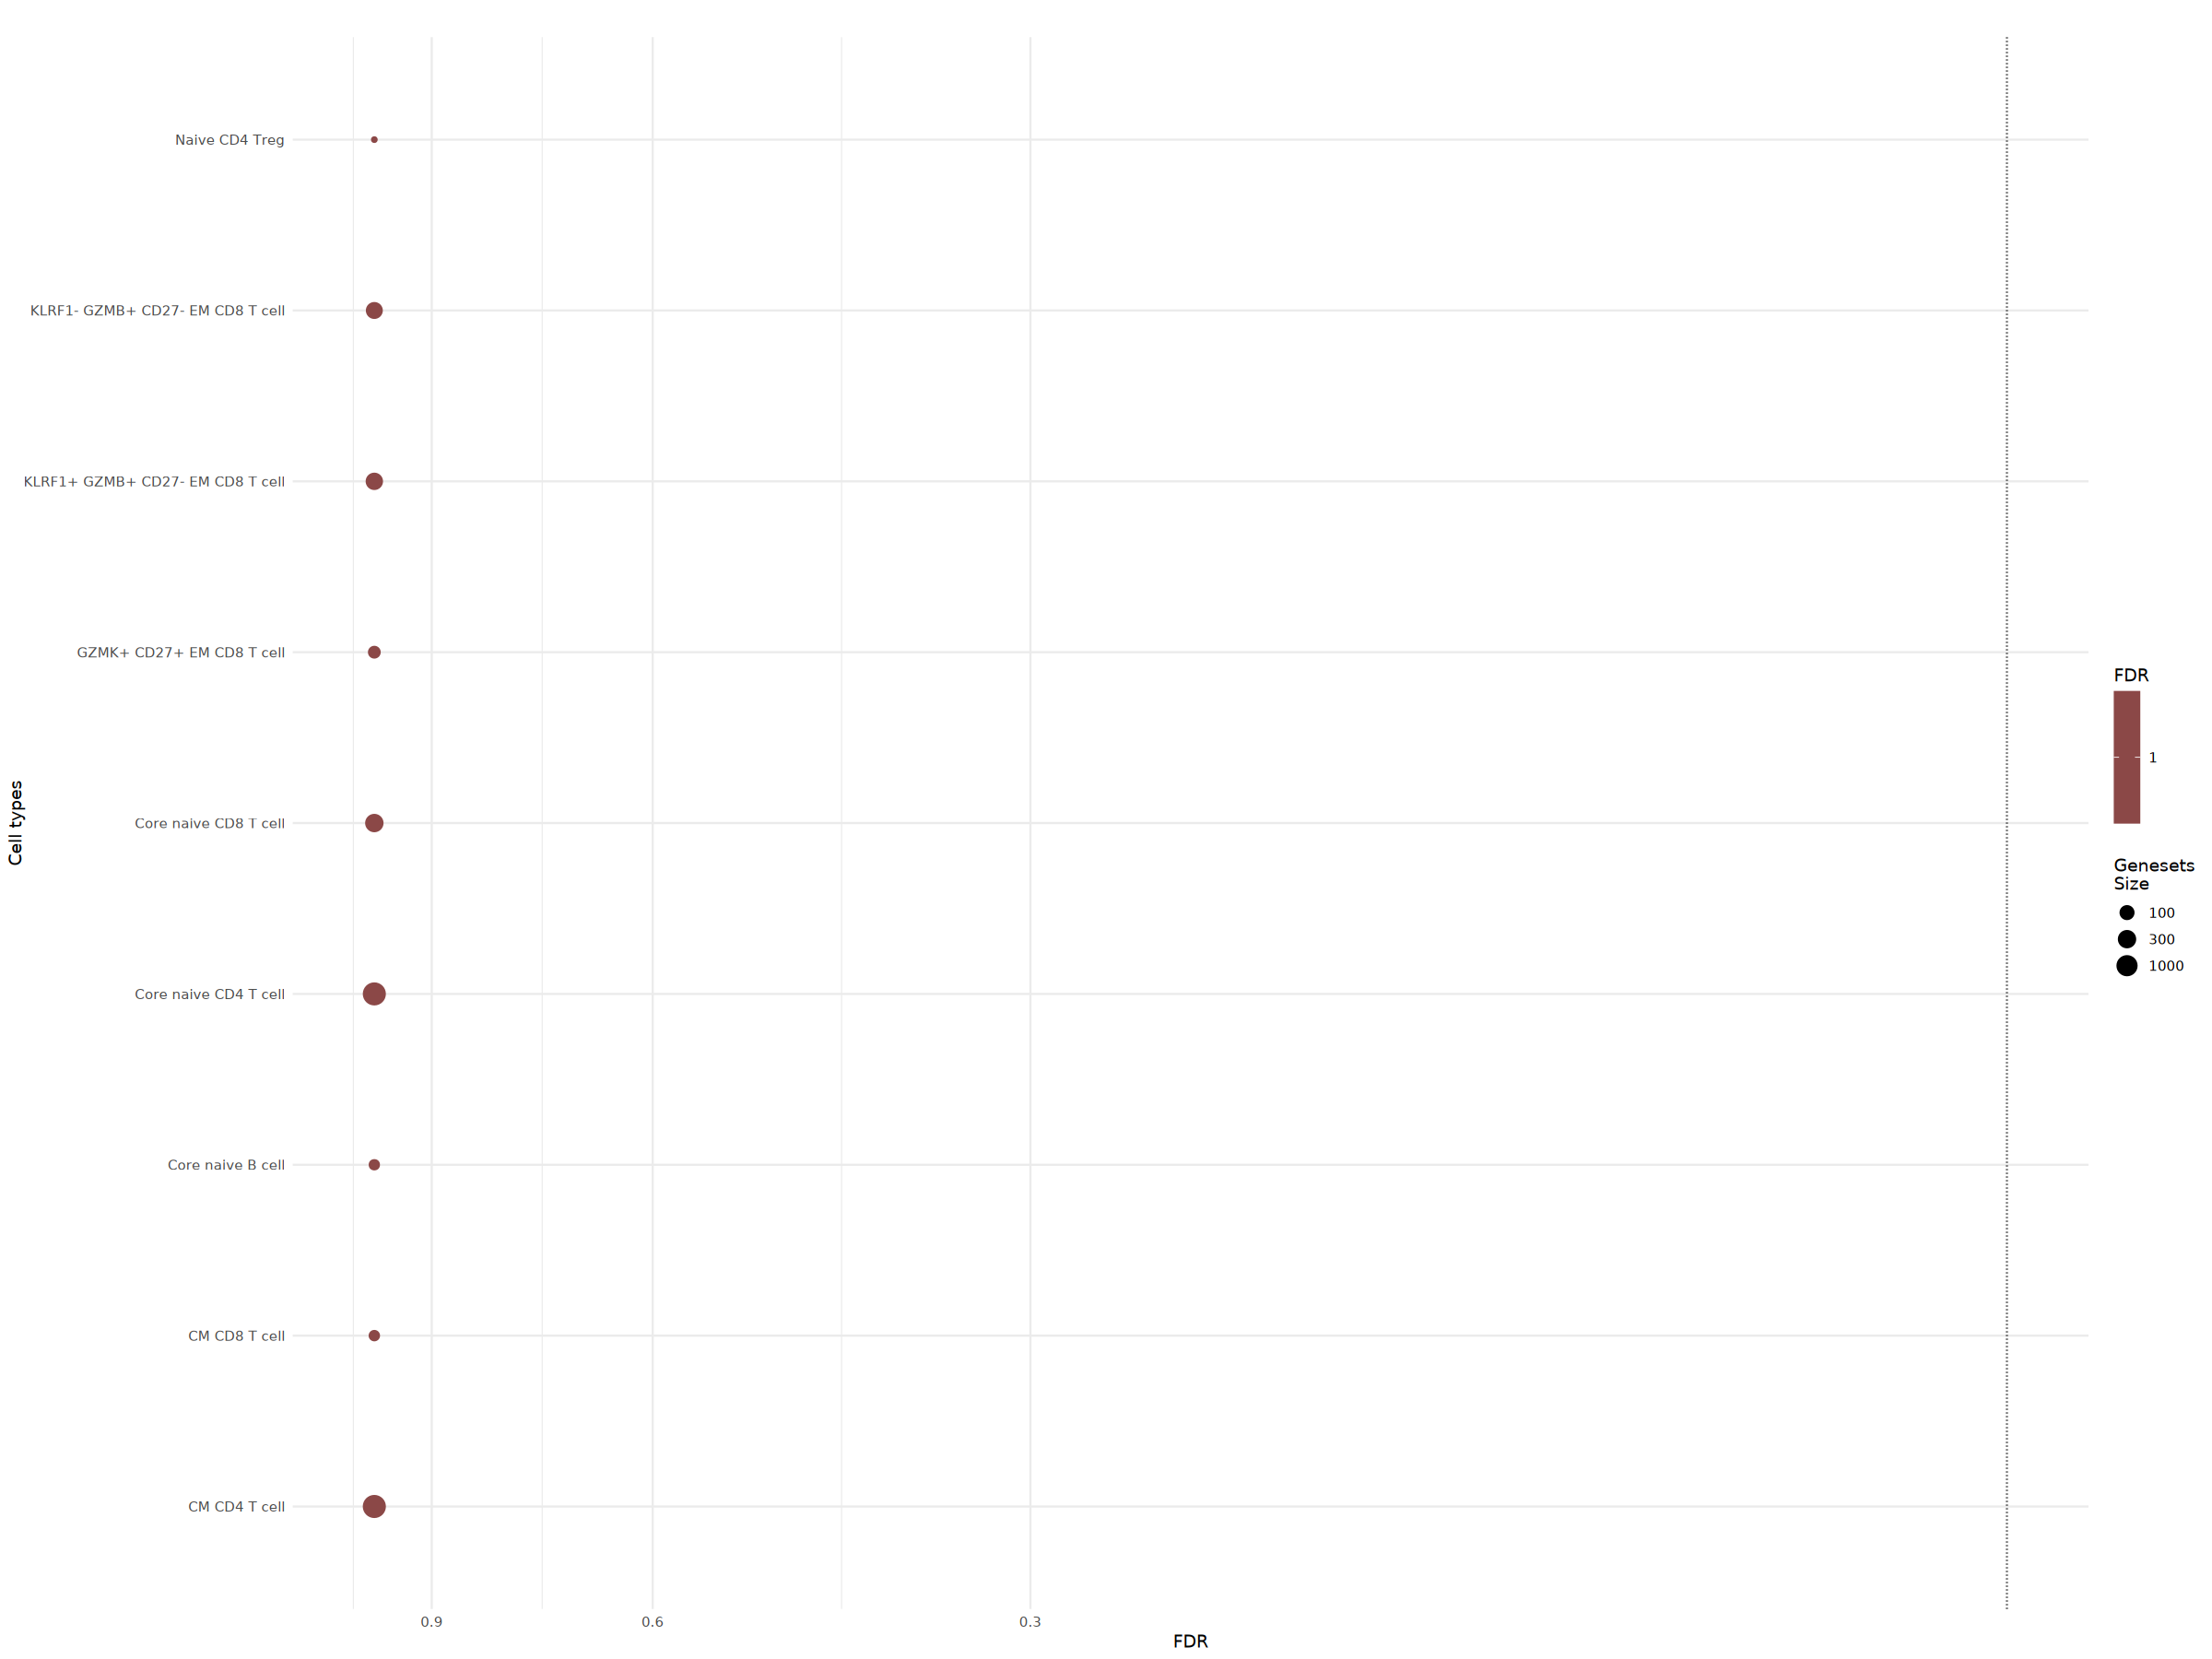

In [58]:
p1 <- hyp_dots(hyp_obj) + theme_minimal() + xlab('Cell types')
p1
# ggsave(file.path(fig_path, paste0(proj_name, 'gene_signature_abt_responder.pdf')), width = 6, height = 4)

In [8]:
# compare to the paired comparisons
paired_degs = read_csv(
    '/home/jupyter/data/ra_longitudinal/output_results/certPro/paired/ALTRA_AIM3_scRNA_Pseudobulk_paired_deseq2_deg_list.csv')

Rows: 253007 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): cell_type, gene, sig
dbl (7): baseMean, log2FoldChange, lfcSE, stat, pvalue, padj, q_values

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [9]:
paired_degs%>%head()

cell_type,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,q_values,sig
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Adaptive NK cell,AAK1,39.186588,-0.09885216,0.1937081,-0.5103149,0.6098308,0.9993347,0.9993347,ns
Adaptive NK cell,AASDHPPT,9.253967,-0.12763481,0.2533369,-0.5038146,0.6143917,0.9993347,0.9993347,ns
Adaptive NK cell,AATF,13.256907,0.15333509,0.2267103,0.6763483,0.4988196,0.9993347,0.9993347,ns
Adaptive NK cell,ABCB1,8.869858,0.04081630,0.3133005,0.1302784,0.8963462,0.9993347,0.9993347,ns
Adaptive NK cell,ABCE1,6.951014,0.07337815,0.2855077,0.2570094,0.7971715,0.9993347,0.9993347,ns
Adaptive NK cell,ABCF1,23.302221,0.03256938,0.2081183,0.1564945,0.8756432,0.9993347,0.9993347,ns


In [10]:
# combine the deg results
paired_nejm_degs_comparison <- paired_degs %>% left_join(nejm_data, by=c('gene'),
                                          suffix = c('_paired', '_nejm'))%>%
   filter(#q_values<0.1 & #padj<0.1&
          !is.na(logFC))%>% 
    mutate(sig = case_when(FDR<=0.1&q_values<=0.1 ~ 'FlareSig&pairedSig', 
                    FDR>0.1&q_values<=0.1 ~ 'pairedSig', 
                    FDR<=0.1&q_values>0.1 ~ 'FlareSig', 
                    FDR>0.1&q_values>0.1~ 'No sig'))%>% 
    mutate(paired_direction = if_else(log2FoldChange>0, 'paired_up', 'paired_down'),
          flare_direction = if_else(logFC>0, 'Flare_up', 'Flare_down'))%>%
    mutate(direction=
           case_when(paired_direction == 'paired_up' & flare_direction=='Flare_up' ~ 
                     'Increased during progression to RA&\nIncreased during flare', 
                    paired_direction == 'paired_down' & flare_direction=='Flare_down' ~ 
                     'Decreased during progression to RA&\nDecreased during flare', 
                     paired_direction == 'paired_down' & flare_direction=='Flare_up' ~ 
                     'Decreased during progression to RA&\nIncreased during flare', 
                     paired_direction == 'paired_up' & flare_direction=='Flare_down' ~ 
                     'Increased during progression to RA&\nDecreased during flare'))
paired_nejm_degs_comparison%>%head()

cell_type,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,q_values,sig,ensembl,name_source,description,logFC,logCPM,FDR,paired_direction,flare_direction,direction
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
Adaptive NK cell,AAK1,39.186588,-0.09885216,0.1937081,-0.5103149,0.6098308,0.9993347,0.9993347,No sig,ENSG00000115977,HGNC Symbol,AP2 associated kinase 1 [Source:HGNC Symbol;Acc:HGNC:19679],0.029849071,6.3642973,0.8712088,paired_down,Flare_up,Decreased during progression to RA& Increased during flare
Adaptive NK cell,AASDHPPT,9.253967,-0.12763481,0.2533369,-0.5038146,0.6143917,0.9993347,0.9993347,No sig,ENSG00000149313,HGNC Symbol,aminoadipate-semialdehyde dehydrogenase-phosphopantetheinyl transferase [Source:HGNC Symbol;Acc:HGNC:14235],0.159937500,4.8946000,0.4538066,paired_down,Flare_up,Decreased during progression to RA& Increased during flare
Adaptive NK cell,ABCB1,8.869858,0.04081630,0.3133005,0.1302784,0.8963462,0.9993347,0.9993347,No sig,ENSG00000085563,HGNC Symbol,ATP binding cassette subfamily B member 1 [Source:HGNC Symbol;Acc:HGNC:40],-0.098615225,3.7545085,0.6145664,paired_up,Flare_down,Increased during progression to RA& Decreased during flare
Adaptive NK cell,ABCE1,6.951014,0.07337815,0.2855077,0.2570094,0.7971715,0.9993347,0.9993347,No sig,ENSG00000164163,HGNC Symbol,ATP binding cassette subfamily E member 1 [Source:HGNC Symbol;Acc:HGNC:69],-0.005359729,5.3650380,0.9870516,paired_up,Flare_down,Increased during progression to RA& Decreased during flare
Adaptive NK cell,ABCF1,23.302221,0.03256938,0.2081183,0.1564945,0.8756432,0.9993347,0.9993347,No sig,ENSG00000204574,HGNC Symbol,ATP binding cassette subfamily F member 1 [Source:HGNC Symbol;Acc:HGNC:70],-0.148733521,4.3501007,0.5923405,paired_up,Flare_down,Increased during progression to RA& Decreased during flare
Adaptive NK cell,ABHD14A,8.929818,0.12077851,0.2626731,0.4598054,0.6456559,0.9993347,0.9993347,No sig,ENSG00000248487,HGNC Symbol,abhydrolase domain containing 14A [Source:HGNC Symbol;Acc:HGNC:24538],-0.336803370,0.8247337,0.2680594,paired_up,Flare_down,Increased during progression to RA& Decreased during flare


In [14]:
paired_nejm_degs_comparison%>%distinct(cell_type)

cell_type
<chr>
Adaptive NK cell
C1Q+ CD16 monocyte
CD14+ cDC2
CD27+ effector B cell
CD27- effector B cell
CD4 MAIT
CD56bright NK cell
CD8 MAIT
CD8aa


Warning message:
“ggrepel: 663 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


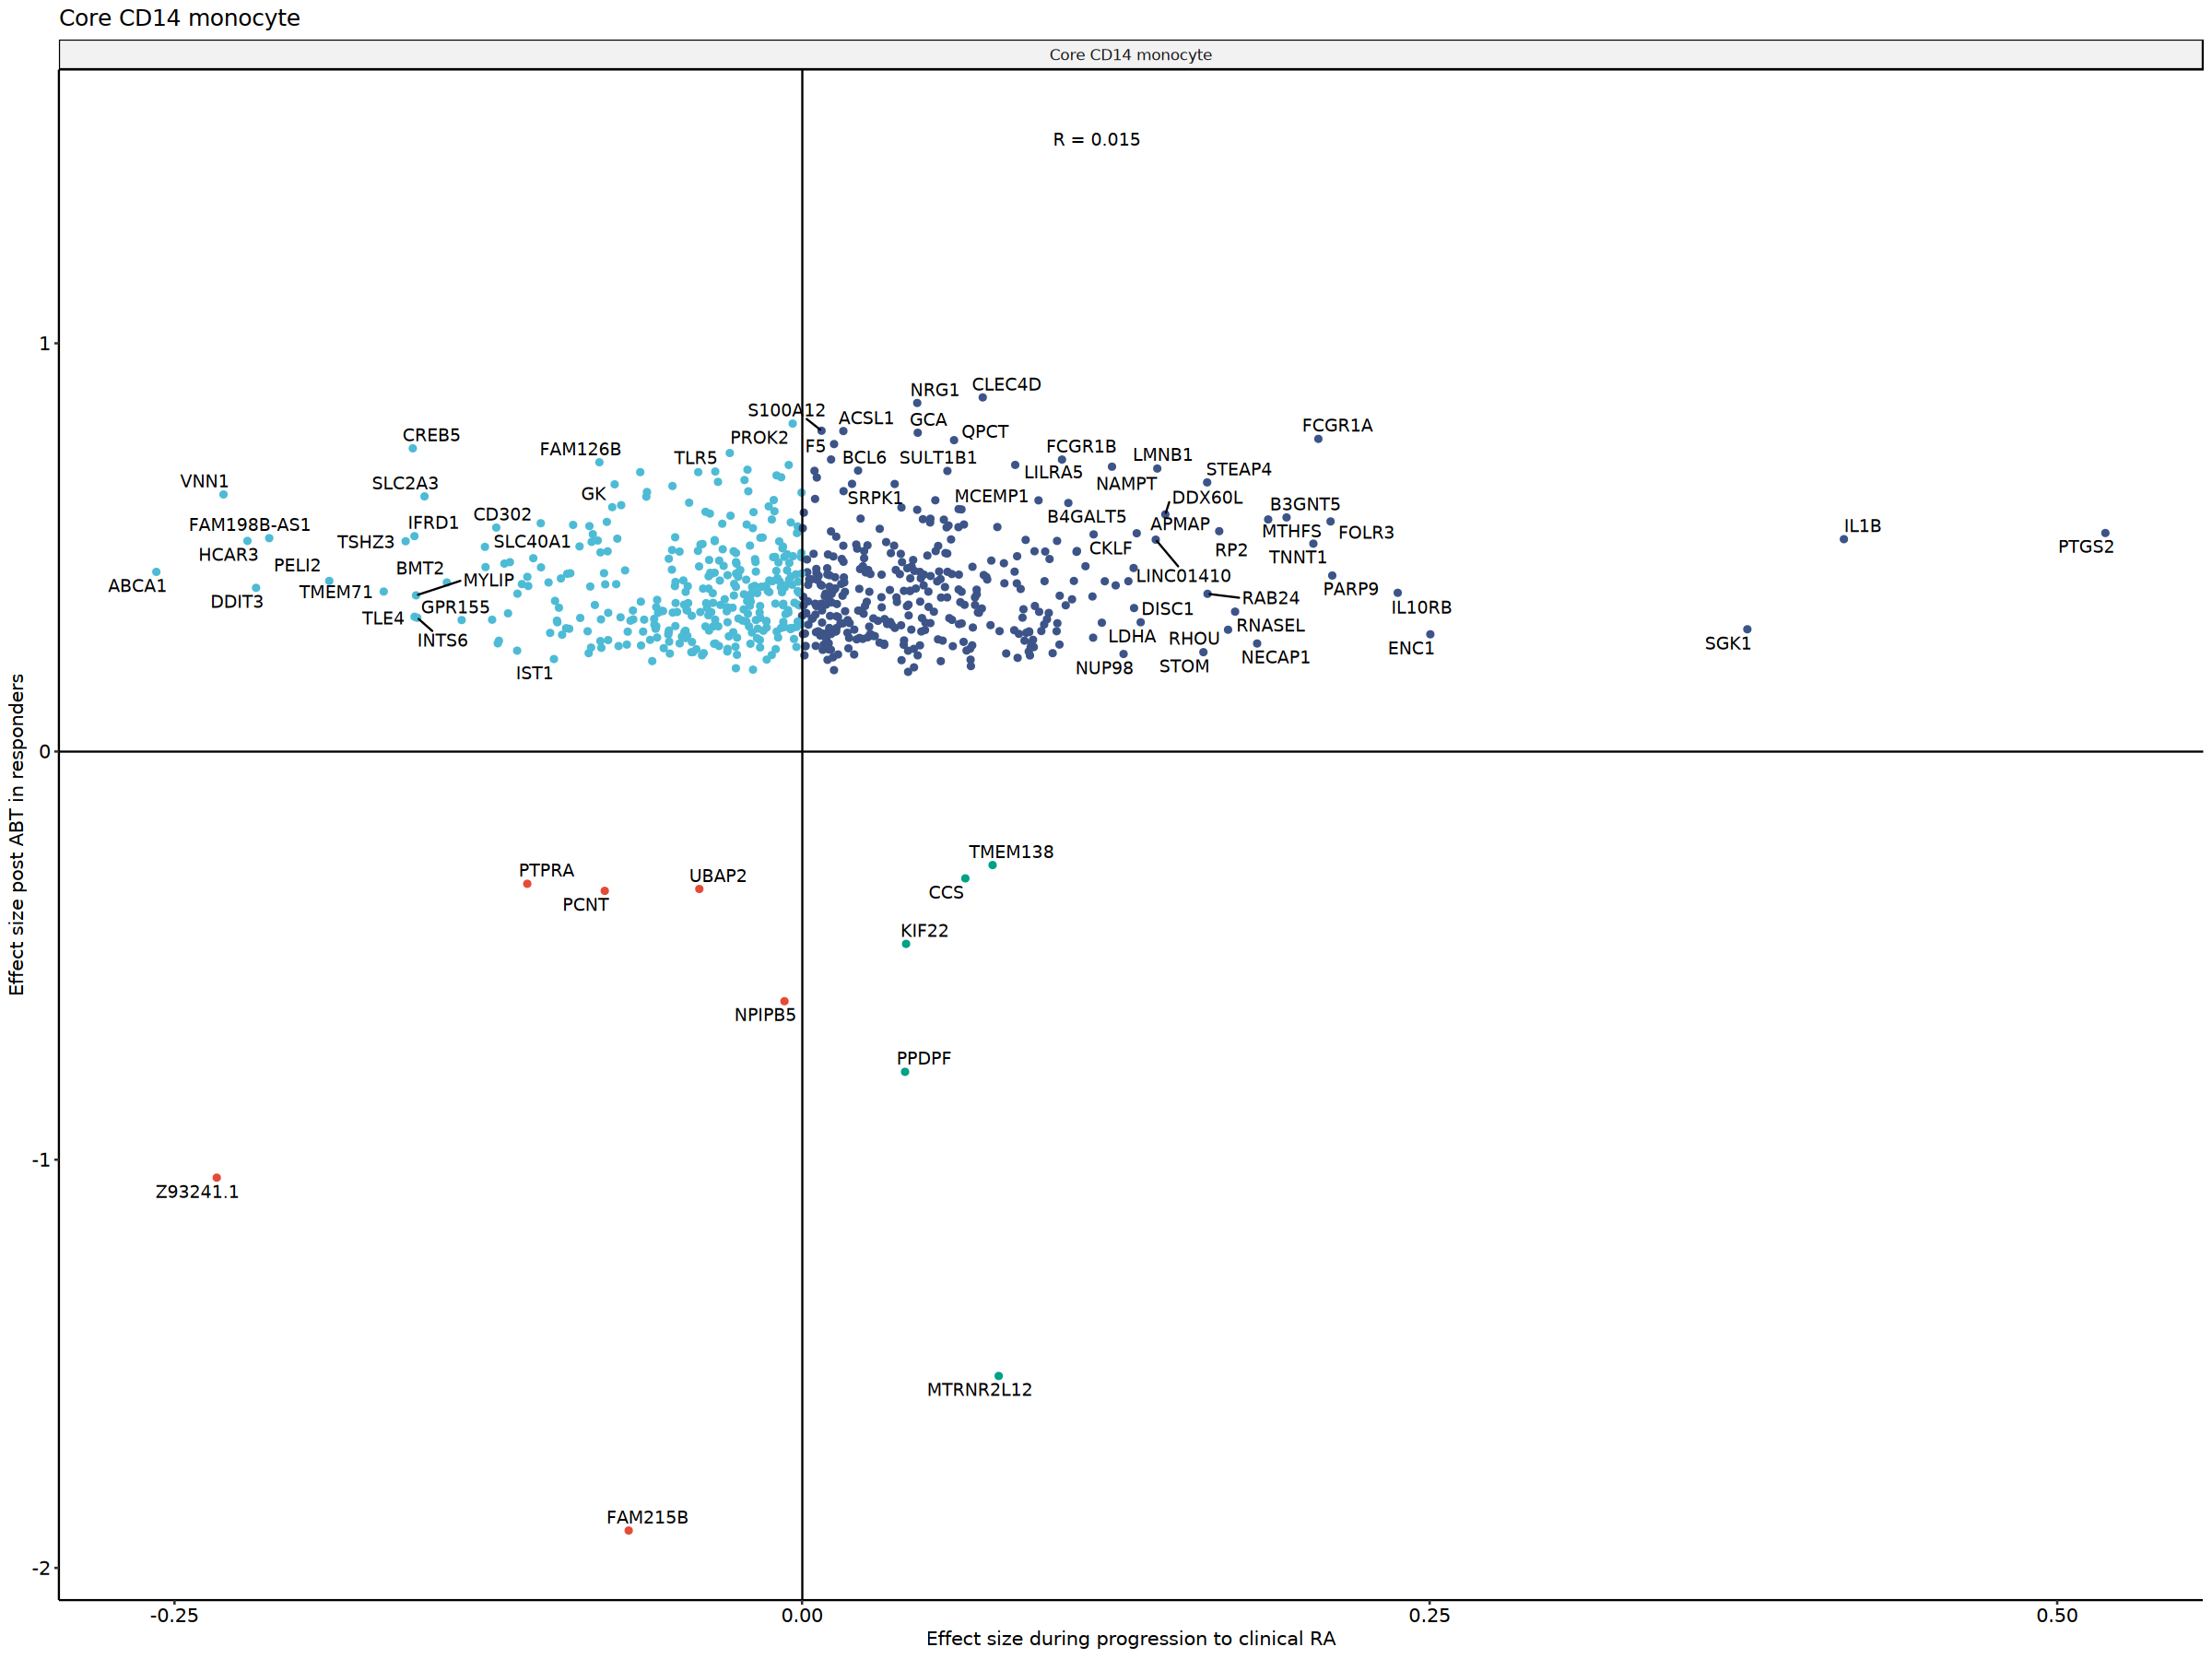

In [36]:
# plot the significant genes
cell_type_plot =  'Core CD14 monocyte'

p1 <- paired_nejm_degs_comparison%>% filter(FDR<0.05) %>% filter(cell_type==cell_type_plot)%>%
    ggplot(aes(y=logFC, x=log2FoldChange
                          )) +
    geom_point(aes(color=direction)) +
    ggrepel::geom_text_repel(aes(label=gene), 
                            ) +
    # stat_smooth(method = "lm", 
    #           formula = y ~ x, 
    #           geom = "smooth") + 
    geom_vline(xintercept = 0)+ geom_hline(yintercept = 0)+ 
    ggpubr::stat_cor(aes(label = after_stat(r.label)), method = "spearman", label.x = 0.1, label.y = 1.5)+
   facet_wrap(vars(cell_type)) + 
    scale_color_manual(values = npg_color) + theme_pubr() +
    guides(color='none') + 
    labs(title = cell_type_plot, x='Effect size during progression to clinical RA', 
        y='Effect size post ABT in responders')
p1
# ggsave(file.path(fig_path, paste0(proj_name,'abecetpt_responder_Aim3_deg_',cell_type_plot,'_logfc_cor_plot.pdf')),
#        width=4, height=4)

In [37]:
up_genes = paired_nejm_degs_comparison%>% filter(FDR<0.05) %>% 
    filter(cell_type==cell_type_plot&paired_direction=='paired_up'&flare_direction=='Flare_up')%>%pull(gene)
down_genes = paired_nejm_degs_comparison%>% filter(FDR<0.05) %>% 
    filter(cell_type==cell_type_plot&paired_direction=='paired_down'&flare_direction=='Flare_up')%>%pull(gene)

In [38]:
up_genes%>%length()
down_genes%>%length()

[1] 345

[1] 322

In [53]:
# pathway analysis with enrichR
quiet_library(enrichR)
setEnrichrSite("Enrichr")
dbs <- listEnrichrDbs()


Connection changed to https://maayanlab.cloud/Enrichr/

Connection is Live!



In [40]:
# pathway enrichment for cd4na
enrich_up_genes <- enrichr(up_genes, c('KEGG_2021_Human', 'MSigDB_Hallmark_2020'))
enrich_up_genes[["MSigDB_Hallmark_2020"]]%>% filter(Adjusted.P.value<0.05)

Uploading data to Enrichr... Done.
  Querying KEGG_2021_Human... Done.
  Querying MSigDB_Hallmark_2020... Done.
Parsing results... Done.


Term,Overlap,P.value,Adjusted.P.value,Old.P.value,Old.Adjusted.P.value,Odds.Ratio,Combined.Score,Genes
<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<chr>
Inflammatory Response,19/200,2.023704e-09,4.654518e-08,0,0,6.270650,125.52799,SLC31A2;RIPK2;SLC31A1;IFNGR2;SGMS2;NFKB1;TLR1;RNF144B;PTPRE;KLF6;SELL;IL1B;NAMPT;C3AR1;TNFSF10;KIF1B;LCP2;CD55;TLR2
Allograft Rejection,19/200,2.023704e-09,4.654518e-08,0,0,6.270650,125.52799,CCR1;IFNAR2;SRGN;IGSF6;IFNGR1;RIPK2;IFNGR2;BCL10;TLR1;IL1B;ST8SIA4;FAS;DEGS1;LCP2;TLR6;GBP2;EIF4G3;CCR2;TLR2
TNF-alpha Signaling via NF-kB,17/200,7.517023e-08,1.152610e-06,0,0,5.514861,90.46308,RIPK2;IFNGR2;PTGS2;LITAF;ETS2;NFKB1;PTPRE;KLF6;NFIL3;BCL6;IL1B;NAMPT;SLC16A6;SGK1;TLR2;MCL1;B4GALT5
PI3K/AKT/mTOR Signaling,12/105,2.659592e-07,3.058531e-06,0,0,7.579967,114.76012,VAV3;GSK3B;ACTR2;RALB;CAB39;YWHAB;CLTC;PTEN;SLA;DAPP1;MAPK1;RAC1
Interferon Gamma Response,15/200,2.159437e-06,1.986682e-05,0,0,4.783784,62.40763,IFNAR2;EIF4E3;SP110;RIPK2;SPPL2A;PTGS2;NFKB1;PLSCR1;NAMPT;TNFSF10;ST8SIA4;TRIM25;FAS;LCP2;FCGR1A
Androgen Response,10/100,8.961892e-06,6.870784e-05,0,0,6.489221,75.42116,HERC3;STEAP4;VAPA;TMEM50A;ELOVL5;HMGCR;SGK1;SEC24D;MYL12A;UBE2J1
mTORC1 Signaling,13/200,4.672275e-05,3.070352e-04,0,0,4.076477,40.64769,GSK3B;ACTR2;ELOVL5;TXNRD1;SLA;DAPP1;HMGCR;LDHA;NFIL3;NAMPT;PGK1;GAPDH;GLA
IL-6/JAK/STAT3 Signaling,8/87,1.292170e-04,7.429976e-04,0,0,5.882432,52.67140,CCR1;IFNGR1;IL10RB;IFNGR2;IL1B;FAS;IL13RA1;TLR2
KRAS Signaling Up,12/200,1.934557e-04,9.887735e-04,0,0,3.731455,31.90566,CLEC4A;MTMR10;FCER1G;GALNT3;IL1B;C3AR1;TLR8;TOR1AIP2;STRN;LCP1;AVL9;PTGS2


In [41]:
# pathway enrichment for cd4na
enrich_down_genes <- enrichr(down_genes, c('KEGG_2021_Human', 'MSigDB_Hallmark_2020'))
enrich_down_genes[["MSigDB_Hallmark_2020"]]%>% filter(Adjusted.P.value<0.05)

Uploading data to Enrichr... Done.
  Querying KEGG_2021_Human... Done.
  Querying MSigDB_Hallmark_2020... Done.
Parsing results... Done.


Term,Overlap,P.value,Adjusted.P.value,Old.P.value,Old.Adjusted.P.value,Odds.Ratio,Combined.Score,Genes
<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<chr>
Complement,14/200,4.757481e-06,0.0002140866,0,0,4.763441,58.37974,LYN;CR1;CPQ;PRCP;PSEN1;CTSS;PIK3CG;LAMP2;CASP4;IRF2;ADAM9;LTA4H;RAF1;S100A9
Apoptosis,12/161,1.209729e-05,0.0002721891,0,0,5.073566,57.44559,PAK1;BCL2L11;CDKN1B;DDIT3;CASP4;DPYD;PPT1;PSEN1;CFLAR;SOD2;SAT1;CD44
TNF-alpha Signaling via NF-kB,12/200,1.017509e-04,0.0015262631,0,0,4.013040,36.89181,ABCA1;NFAT5;DRAM1;PDE4B;MAP3K8;DENND5A;SLC2A3;CFLAR;MXD1;SOD2;SAT1;CD44
Inflammatory Response,11/200,4.155209e-04,0.0046746099,0,0,3.647204,28.39705,LYN;ABCA1;AQP9;FPR1;PDE4B;PROK2;PSEN1;RAF1;MXD1;HIF1A;IFNAR1
UV Response Dn,9/144,5.525404e-04,0.0049728638,0,0,4.162513,31.22295,ATXN1;CDKN1B;SIPA1L1;PRKAR2B;CELF2;DYRK1A;NR3C1;MAPK14;TGFBR2
mTORC1 Signaling,10/200,1.550243e-03,0.0099971250,0,0,3.287449,21.26764,ERO1A;RIT1;DDIT3;IFRD1;SSR1;SLC2A3;GLRX;LTA4H;BCAT1;SKAP2
PI3K/AKT/mTOR Signaling,7/105,1.555108e-03,0.0099971250,0,0,4.439909,28.70939,RIT1;CDKN1B;DUSP3;DDIT3;IRAK4;RAF1;MAP2K6
Hypoxia,9/200,5.249223e-03,0.0295268802,0,0,2.933660,15.40076,ERO1A;CDKN1B;DDIT3;CCNG2;PDK3;SLC2A3;GLRX;RBPJ;NR3C1
